# Abstract

Fog presents a significant and persistent challenge to road safety, particularly in California's Central Valley[1], where dense radiation fog events are responsible for multi-vehicle collisions and fatalities each year. Roughly ~39,000 Californians die due to traffic-related injuries each year[2]. Despite advances in meteorological forecasting, accurate fog prediction remains difficult due to the localized and transient nature of fog formation. This investigation targets the Tule Valley Fog, which is a seasonal phenomenom that blankets much of the Californian Central Valley in thick fog during the fall and winter months. Furthermore, this report investigates the sensitivity of air quality indicators and their effect on the ability of machine learning algorithms to accurately model and predict regional fog events; specifically, it focuses on particulate matter (PM10, PM2.5, aerosol optical depth, dust, and nitrogen dioxide) on fog prediction performance across five locations in the San Joaquin Valley in relation to five machine learning approaches. Using hourly weather and air quality data spanning 1980–2025 sourced from the Open-Meteo API, five classification models are investigated: Logistic Regression, Random Forest, XGBoost, a Temporal Convolutional Neural Network (CNN), and a Sequential Stacking Ensemble. Each model was tested across three dataset configurations to isolate the effects of AQI features and dataset completeness. These findings reveal that, contrary to expectations, the inclusion of AQI features did not improve, but rather worsened, fog prediction performance. This is believe to have been caused by the limited availability of AQI data, and thus this study motivates the prioritizion of longer datasets over their shorter, AQI-based counterparts. The Sequential Stacking Ensemble achieves the best overall F1 score (0.371) on the full historical dataset, while the Temporal CNN achieves the highest recall (97.2%), capturing nearly all fog events. These results suggest that dataset volume and temporal depth are more valuable for fog prediction than the addition of air quality features in their current availability.

# Introduction

The California Central Valley, which spans roughly 450 miles from Redding to Bakersfield, is one of the most fog-prone regions in the United States. Each winter, dense radiation fog blankets the San Joaquin Valley floor, reducing visibility to near zero and transforming routine commutes into life-threatening events. The stretchs of State Route 99 and U.S. Interstate 5 within the Central Valley have earned a reputation as some of the deadliest fog corridors in the country, with chain-reaction collisions involving dozens of vehicles occurring with alarming regularity.

The aim of this project is to investigate whether air quality indicators can improve the accuracy of fog prediction models in the southern Central Valley, and to evaluate a suite of machine learning approaches for binary fog classification. The ultimate goal is to inspire the development of a widespread, operationally deployable fog prediction tool that could be used by transportation authorities to trigger traffic reroutes, speed advisories, and stay-at-home warnings, thereby reducing fog-related accidents and fatalities.

To this end, hourly weather observations and air quality measurements were collected from five San Joaquin Valley locations over a 45-year period (1980–2025). Engineer domain-relevant features (dewpoint depression, cooling rates, previous night's low temperature) were also inferred and appended to the test/train datasets. By testing each model on three dataset configurations (with AQI features, without AQI features, and controlled non-AQI with matched rows) the predictability of AQI was isolated.

# Literature Review

## Radiation Fog in the Central Valley

The fog that afflicts the San Joaquin Valley is predominantly *radiation fog*[3], which forms when the ground cools by emitting longwave radiation on clear, calm nights. As the surface temperature drops below the dew point, water vapor condenses near the ground, producing a shallow fog layer that can persist for up to multiple days when trapped beneath a temperature inversion. The Central Valley's topography, a flat basin enclosed by the Sierra Nevada to the east and the Coast Ranges to the west, creates ideal conditions for cold air pooling and persistent inversions during the cool season.

## The Role of Air Quality in Fog Formation

In recent years, air quality has been directly implicated in the formation of such fog[4]. Aerosol particles serve as cloud condensation nuclei (CCN), i.e. microscopic seeds which water vapor condenses to form fog droplets. Researchers demonstrated that elevated concentrations of fine particulate matter can increase the number of available CCN, potentially promoting fog formation even under marginally favorable meteorological conditions. Conversely, the hypothesis predicts that improvements in air quality should reduce fog frequency by decreasing the supply of CCN. This hypothesis has been further tested and verified[5].

## Declining Fog Trends

Observational studies have documented a significant long-term decline in Central Valley fog frequency over the past several decades. This decline has been temporally correlated with improvements in regional air quality following the passage and enforcement of the Clean Air Act and subsequent California Air Resources Board regulations. Between the 1980s and the 2010s, the number of foggy days per winter season in parts of the Valley decreased by roughly 50%. While changes in land use, irrigation practices, and large-scale climate patterns have also been proposed as contributing factors, the air quality–CCN–fog hypothesis remains one of the more compelling explanations for the observed trend.

## Implications for This Study

If air quality metrics are predictive of fog occurrence, then including AQI variables in classification models should improve predictive performance compared to models using only meteorological features. This experimental design directly tests this hypothesis by comparing matched models with and without AQI features on identical subsets of data.

# Code Availability
All functional code used for data extraction, translation, loading, exploration, and modeling is available for review and usage at: https://github.com/jaredlyon/calfog.io

# Data Mining

## Data Sources and Collection

Weather and air quality predictor variables were sourced from the **Open-Meteo API**[6], an open-source weather and air quality API providing access to historical reanalysis data. Hourly weather observations were collected from 1980 through 2025 for five locations in the San Joaquin Valley, selected to correspond with airports that maintain visibility records:

| Location | Name | Latitude | Longitude |
|----------|------|----------|-----------|
| 6 | Madera Airport | 36.989 | -120.111 |
| 7 | Fresno Airport | 36.777 | -119.717 |
| 8 | Visalia Airport | 36.323 | -119.395 |
| 9 | Hanford Airport | 36.313 | -119.626 |
| 10 | Bakersfield Airport | 35.329 | -118.998 |

The data collection script (`datasets/scripts/dataset_gen.py`) batch-fetches data year-by-year in order to respect API rate limits, collecting **15 weather variables** and **5 air quality variables** for each hour.

## Weather Variables (Available 1980–2025)

| Variable | Unit | Description |
|----------|------|-------------|
| `temperature_2m` | °C | Air temperature at 2 meters |
| `relative_humidity_2m` | % | Relative humidity at 2 meters |
| `dew_point_2m` | °C | Dew point temperature at 2 meters |
| `precipitation` | mm | Total precipitation (rain + snow) |
| `rain` | mm | Rainfall only |
| `surface_pressure` | hPa | Atmospheric pressure at surface |
| `et0_fao_evapotranspiration` | mm | Reference evapotranspiration (FAO) |
| `vapour_pressure_deficit` | kPa | Vapour pressure deficit |
| `wind_speed_10m` | km/h | Wind speed at 10 meters |
| `wind_speed_100m` | km/h | Wind speed at 100 meters |
| `wind_gusts_10m` | km/h | Wind gusts at 10 meters |
| `soil_temperature_0_to_7cm` | °C | Soil temperature (0–7 cm depth) |
| `soil_temperature_7_to_28cm` | °C | Soil temperature (7–28 cm depth) |
| `soil_moisture_0_to_7cm` | m³/m³ | Volumetric soil moisture (0–7 cm) |
| `soil_moisture_7_to_28cm` | m³/m³ | Volumetric soil moisture (7–28 cm) |

## Air Quality Variables (Available 2022-08-03 onward)

| Variable | Unit | Description |
|----------|------|-------------|
| `pm10` | µg/m³ | Particulate matter ≤ 10 µm |
| `pm2_5` | µg/m³ | Particulate matter ≤ 2.5 µm |
| `aerosol_optical_depth` | dimensionless | Aerosol optical depth |
| `dust` | µg/m³ | Dust concentration |
| `nitrogen_dioxide` | µg/m³ | Nitrogen dioxide concentration |

## Response Variable

**Visibility** (`visibility_meters`) was used as the response variable for fog classification. Critically, Open-Meteo does **not** encode visibility or fog WMO weather codes for the San Joaquin Valley, as these observations require human, on-the-ground reporting. While visibility data can *technically* be inferred using physics-based modeling, this approach would defeat the purpose of this study. In order to obtain visibility data, historic **air traffic controller (ATC) weather reports** (METARs) corresponding to each airport location were manually requested through **NOAA's National Centers for Environmental Information (NCEI)**[7]. These ATC reports provide hourly prevailing visibility as recorded by tower controllers, which was merged with the Open-Meteo weather data on timestamp. ATC visibility reports are conducted each hour in order to assist approaching and departing aircraft within the vicinity of airport landing strips, and thus encode data from which fog status can be classified.

Because the availability of archived ATC reports varies by airport, the `location_X_without_aqi` datasets differ in temporal coverage: some airports have records dating back to **1980**, while others begin as recently as **2006**. This means each location's dataset contains a different number of rows, and **all models were trained and evaluated separately for each location** rather than on a pooled dataset.

Fog is defined as a binary classification target: an observation is labeled as **fog** when `visibility_meters < 1610` (1 mile), and **no fog** otherwise.

## Inferred Feature Variables

Four additional features were engineered from the raw weather data using the script `datasets/scripts/append_inferred_variables.py`:

1. **Dewpoint Depression**: The difference between air temperature and dew point. Values near zero indicate saturated air, a precondition for fog.
$$\text{dewpoint\_depression} = T_{2m} - T_{dew}$$

2. **Cooling Rate (6-hour)**: The average rate of temperature change over the last 6 hours. Rapid cooling promotes condensation.
$$\text{cooling\_rate\_6h} = \frac{T_{now} - T_{6h\,ago}}{6}$$

3. **Cooling Rate (12-hour)**: Same as above but over a 12-hour window, capturing longer cooling trends.
$$\text{cooling\_rate\_12h} = \frac{T_{now} - T_{12h\,ago}}{12}$$

4. **Previous Night's Low**: The minimum temperature recorded between 6:00 PM of the previous day and 6:00 AM of the current day. Lower overnight temperatures favor fog formation.

All four variables have been previously shown to exert significant predictability on radition fog patterns[7].

## Dataset Assembly and Splitting

The combined datasets were assembled using `eda/datasets/combine_datasets.py`, which merges the weather and AQI data on timestamp with a left join (preserving all weather rows). The datasets were then split using `eda/datasets/split_datasets.py` into three variants per location:

1. **`location_X_without_aqi.csv`** — All rows from the full time period, with AQI columns removed. This approach maximizes training data volume. The start year varies by airport depending on the availability of historical ATC weather reports.
2. **`location_X_with_aqi.csv`** — Only rows where all 5 AQI columns are non-null (2022-08-03 onward), AQI columns retained. This dataset tests the value of AQI features.
3. **`location_X_without_aqi_reduced.csv`** — Identical rows as the `with_aqi` dataset, but AQI columns removed. This dataset serves as a controlled comparison to isolate the effect of AQI features from the effect of dataset size.

This three-way split enables a rigorous comparison: comparing `with_aqi` vs. `without_aqi_reduced` isolates the AQI feature effect (same rows, different features), while comparing `without_aqi` vs. `without_aqi_reduced` isolates the dataset size effect (same features, different number of rows).

# Exploratory Data Analysis

Before constructing machine learning models, a comprehensive exploratory data analysis was conducted to understand the structure, quality, and relationships within the dataset. The preliminary goal of this analysis was to understand whether or not there existed a signal in AQI data that was worth investigating. Six major analytical approaches were employed to establish baseline patterns and motivate modeling decisions. First, a dataset size comparison quantified the substantial reduction in available observations when AQI data was included, revealing that the full historical datasets contained approximately 168,000-400,000 hourly observations per location spanning from 1980 to 2025, while the AQI-enriched datasets were restricted to only 27,000 observations beginning in August 2022. As a result, the primary goal of this study became discovering whether or not these enriched variables were capable of improving predictive modeling despite lacking volume. Second, fog frequency trends were examined across all five locations over the 45-year study period. Annual fog occurrence rates were computed and visualized with linear trend lines, revealing a consistent long-term decline in fog frequency across all airport datasets. These declining trends aligned with prior research linking improved air quality regulations to reduced fog occurrence in the Central Valley. Third, monthly mean time series of the four primary AQI variables (PM10, PM2.5, dust, and nitrogen dioxide) were plotted for the limited period of available air quality data to assess whether this trend in reduction was observable for the acquired AQI data. Fourth, Pearson correlation coefficients were computed between each predictor variable and visibility, with results stratified by variable group (weather, AQI, and inferred features) and presented both per-location and in aggregate. This analysis identified which predictors exhibited the strongest linear relationships with visibility and justified the inclusion of AQI features as candidate predictors despite their limited temporal coverage. Fifth, feature distributions were compared between fog and non-fog conditions using box plots of z-standardized variables. By visualizing how individual predictors differ across the binary fog classification, this analysis revealed a definitive, observable signal which, in theory, could be quanitifed using machine learning approaches. Finally, a k-means clustering sensitivity analysis with eight clusters was conducted across all three dataset variants to provide an unsupervised perspective on feature importance. By computing the variance of cluster centroids for each feature and comparing silhouette scores and Davies-Bouldin indices across dataset configurations, this analysis quantified how the inclusion or removal of AQI features affected the underlying structure and separability of the data. Together, these six exploratory analyses established a rigorous empirical foundation for subsequent modeling decisions, revealed important data quality issues, and provided initial evidence regarding the potential predictive value of air quality indicators for fog classification.

In [1]:
#| echo: false

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150

DATASETS_DIR = Path("eda/datasets")
LOCATIONS = {
    '6': 'Madera Airport',
    '7': 'Fresno Airport',
    '8': 'Visalia Airport',
    '9': 'Hanford Airport',
    '10': 'Bakersfield Airport'
}
FOG_THRESHOLD = 1610  # meters (1 mile)

data = {}
for loc_num, loc_name in LOCATIONS.items():
    with_aqi = pd.read_csv(DATASETS_DIR / f"location_{loc_num}_with_aqi.csv", parse_dates=['time'])
    without_aqi = pd.read_csv(DATASETS_DIR / f"location_{loc_num}_without_aqi.csv", parse_dates=['time'])
    without_aqi_reduced = pd.read_csv(DATASETS_DIR / f"location_{loc_num}_without_aqi_reduced.csv", parse_dates=['time'])
    
    for df in [with_aqi, without_aqi, without_aqi_reduced]:
        invalid = df['visibility_meters'] > 999000
        if invalid.any():
            median_vis = df.loc[~invalid, 'visibility_meters'].median()
            df.loc[invalid, 'visibility_meters'] = median_vis
        df['fog'] = (df['visibility_meters'] < FOG_THRESHOLD).astype(int)
        df['year'] = df['time'].dt.year
    
    data[loc_num] = {'with_aqi': with_aqi, 'without_aqi': without_aqi, 'without_aqi_reduced': without_aqi_reduced, 'name': loc_name}

## Dataset Size Comparison

After merging weather and AQI data, two primary dataset variants were produced for each location:

- **Without AQI - full dataset** — the full hourly record from 1980 to 2025, containing only weather and inferred features, yielding 168,000-400,000 rows.
- **With AQI** — restricted to rows where all five AQI columns are non-null (starting August 2022), yielding ~27,000 rows.
- **Without AQI - reduced dataset** — restricted to the same rows as the **with aqi dataset**, but with AQI variables removed, yielding ~27,000 rows.

It should also be noted that the ATC-based METAR visibility reports were not 100% complete, with sporadic 999999.0 records denoting hours upon which ATC failed to report a visibility metric. These rows are not measured within the following data analysis, and were median-imputed within model architectures.

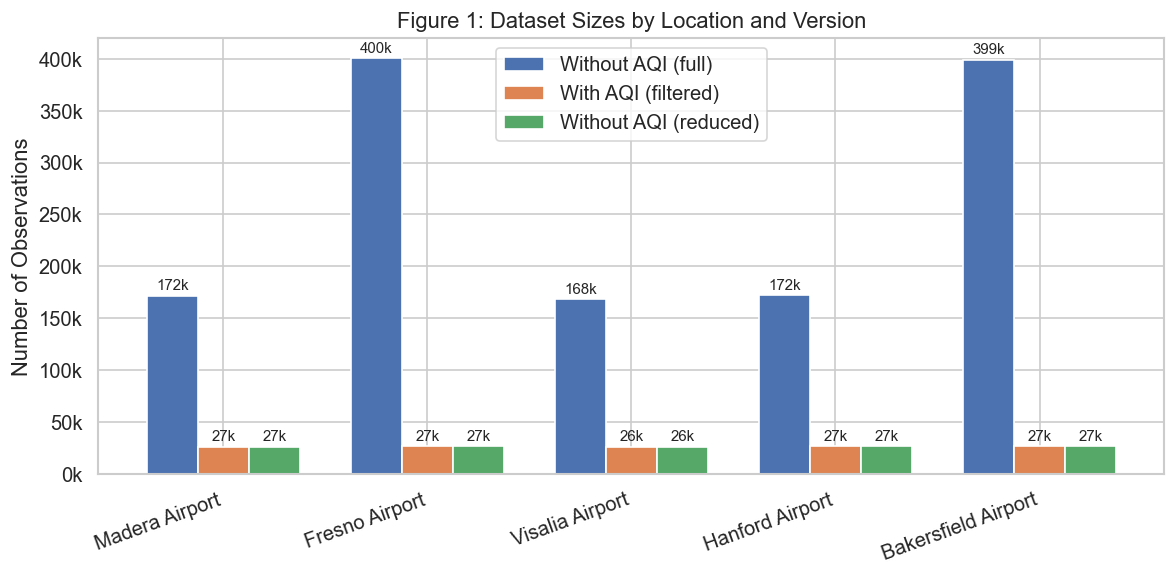

In [2]:
#| echo: false

loc_labels = [LOCATIONS[k] for k in LOCATIONS]
sizes_without = [len(data[k]['without_aqi']) for k in LOCATIONS]
sizes_with = [len(data[k]['with_aqi']) for k in LOCATIONS]
sizes_reduced = [len(data[k]['without_aqi_reduced']) for k in LOCATIONS]

x = np.arange(len(loc_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - width, sizes_without, width,
               label='Without AQI (full)', color='#4c72b0')

bars2 = ax.bar(x, sizes_with, width,
               label='With AQI (filtered)', color='#dd8452')

bars3 = ax.bar(x + width, sizes_reduced, width,
               label='Without AQI (reduced)', color='#55a868')

ax.set_ylabel('Number of Observations')
ax.set_title('Figure 1: Dataset Sizes by Location and Version')
ax.set_xticks(x)
ax.set_xticklabels(loc_labels, rotation=20, ha='right')
ax.legend()

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}k')
)

# Label bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 3000,
            f'{bar.get_height()/1000:.0f}k',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

## Fog Frequency Over Time

Central California's San Joaquin Valley has historically been one of the foggiest regions in the United States, but observational evidence suggests a long-term decline in fog occurrence. The following charts show the annual percentage of hours classified as fog (visibility < 1,610 m) for each monitoring location based on the accumulated METAR-based datasets.

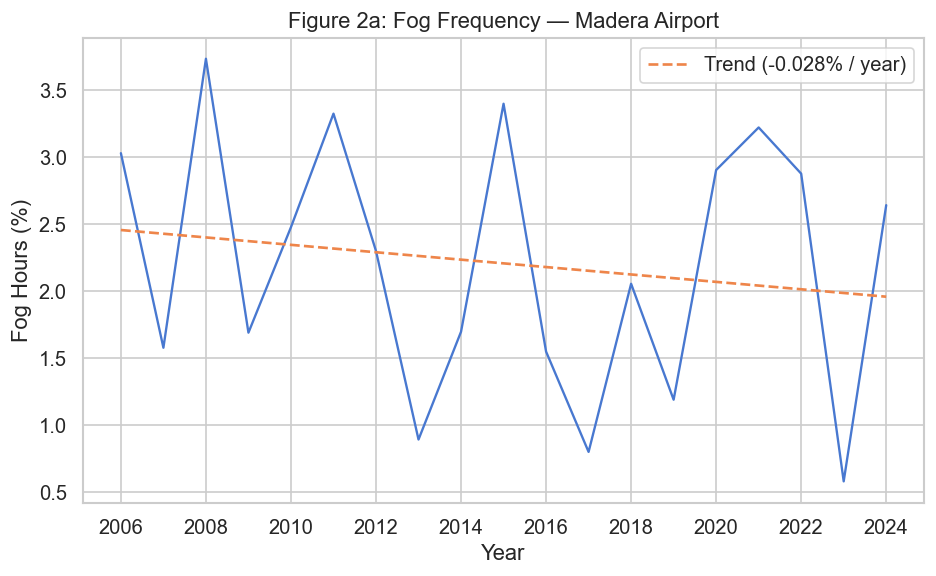

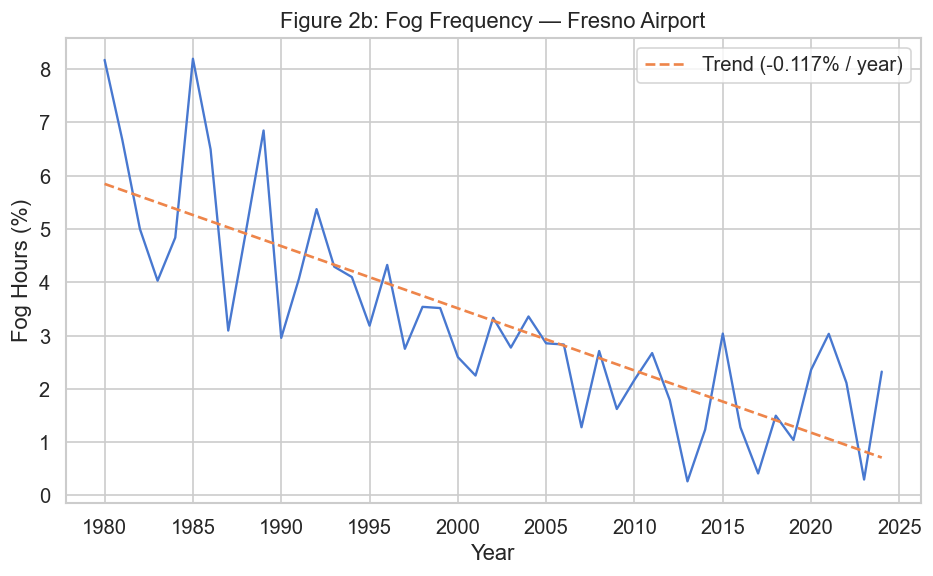

<div style='page-break-after: always;'></div>

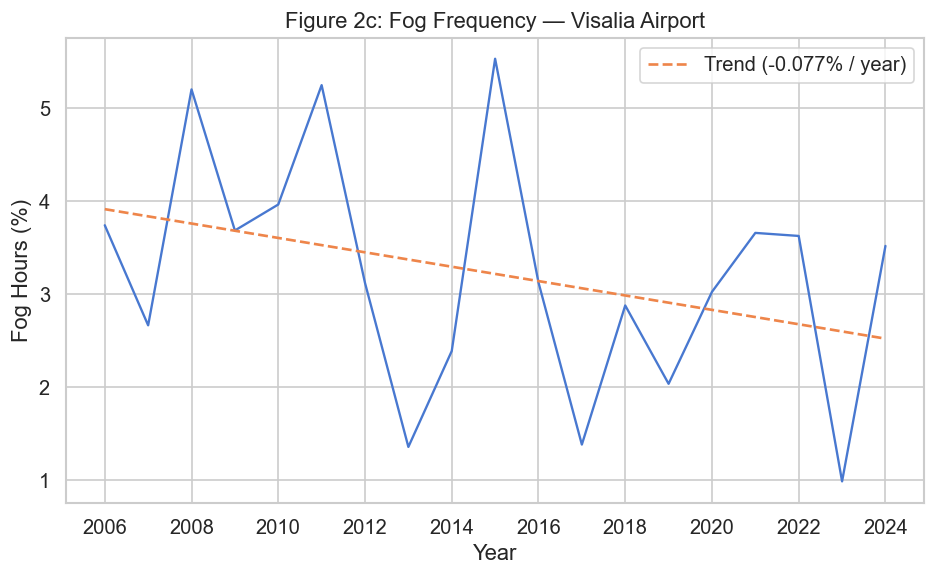

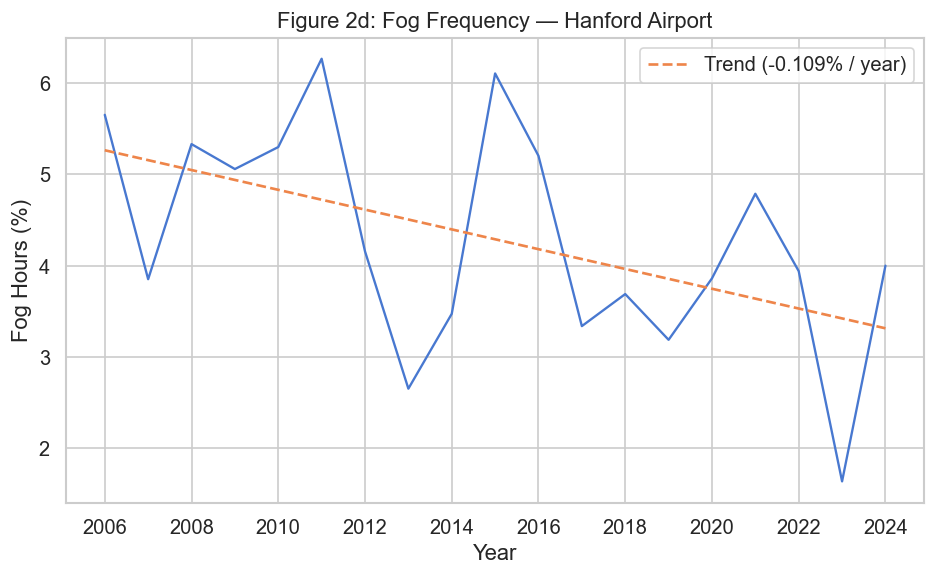

<div style='page-break-after: always;'></div>

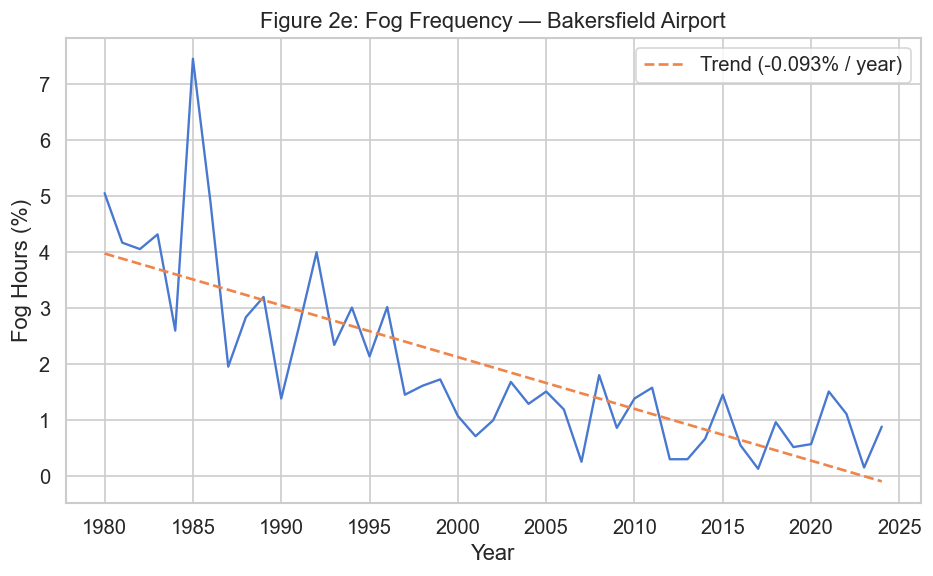

In [3]:
#| echo: false

from matplotlib.ticker import MaxNLocator
from IPython.display import display, Markdown

for i, (loc_num, loc_info) in enumerate(data.items(), start=1):

    df = loc_info['without_aqi']

    yearly = (
        df.groupby('year')
        .agg(total=('fog', 'count'),
             fog_hours=('fog', 'sum'))
    )

    yearly['fog_pct'] = yearly['fog_hours'] / yearly['total'] * 100
    yearly = yearly[yearly.index < 2025]

    fig, ax = plt.subplots(figsize=(8,5))

    # main series
    ax.plot(
        yearly.index,
        yearly['fog_pct'],
        linewidth=1.4
    )

    # trend line
    z = np.polyfit(yearly.index.values, yearly['fog_pct'].values, 1)
    trend = np.poly1d(z)

    ax.plot(
        yearly.index,
        trend(yearly.index),
        linestyle="--",
        linewidth=1.6,
        label=f"Trend ({z[0]:+.3f}% / year)"
    )

    ax.set_title(f"Figure 2{chr(96 + i)}: Fog Frequency — {loc_info['name']}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Fog Hours (%)")

    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend()

    plt.tight_layout()
    plt.show()

    # page break every two figures
    if i % 2 == 0:
        display(Markdown("<div style='page-break-after: always;'></div>"))

The declining fog frequency trends observed across all locations present a significant challenge for model development and analysis, particularly when working with the limited AQI datasets. As fog events become less frequent over time, the number of positive fog cases available for training and testing decreases proportionally, resulting in increasingly imbalanced datasets. This class imbalance reduces the observable signal strength and makes it more difficult for models to learn the distinguishing characteristics of fog formation conditions.

The impact is especially pronounced for the AQI datasets, which are already constrained by:

1. **Temporal limitations**: AQI measurements are only available from 2022 onwards, providing a much shorter observation window compared to the weather-based datasets that span decades
2. **Reduced fog instances**: With fog frequency declining, the 2-3 year AQI observation period captures fewer fog events than earlier periods would have
3. **Statistical power**: The combination of limited temporal coverage and declining fog frequency means there may be insufficient positive cases to robustly identify relationships between air quality variables and fog formation

This declining signal is particularly problematic for evaluating the predictive value of AQI variables. While these air quality measurements may theoretically influence fog formation through their effects on condensation nuclei availability, the limited number of fog events in the AQI observation window makes it challenging to distinguish genuine causal relationships from noise in the data. Consequently, any conclusions about the importance of AQI variables for fog prediction must be interpreted cautiously, recognizing that the observable signal strength may be insufficient to detect moderate effects even if they exist.

## AQI Over Time

Understanding the temporal patterns of air quality variables is essential for contextualizing their potential role in fog formation. Below monthly mean concentrations of four key air quality indicators are presented: particulate matter (PM10 and PM2.5), dust, and nitrogen dioxide. Each of these pollutants can influence atmospheric visibility and potentially fog formation through distinct physical mechanisms.

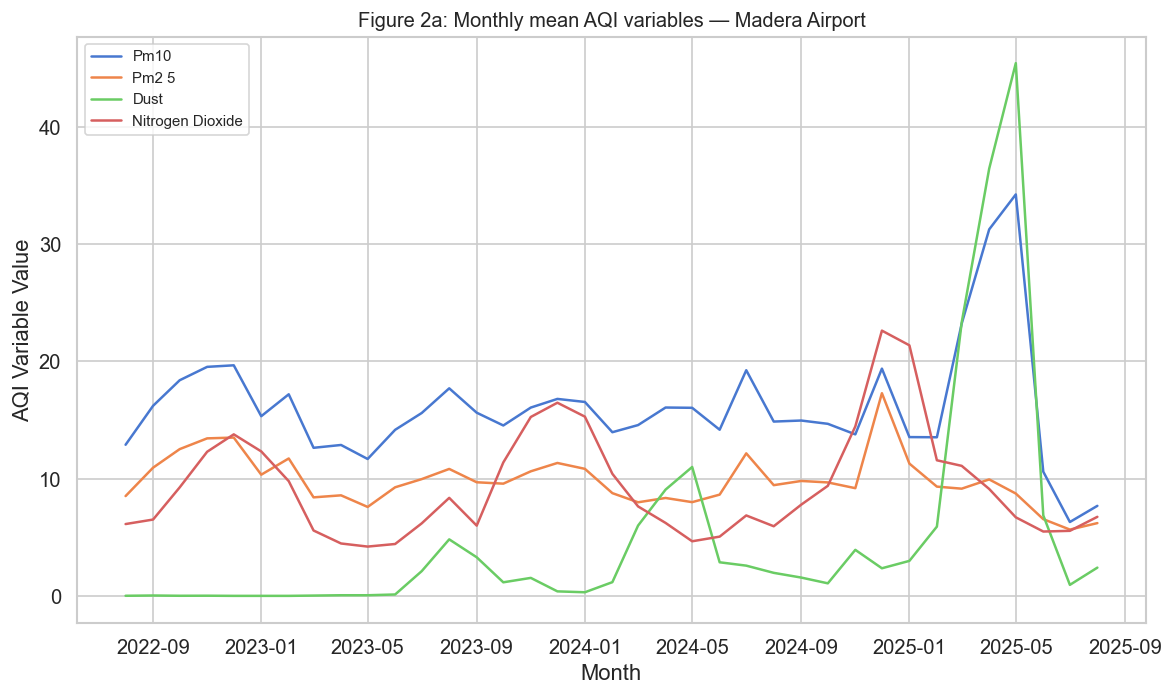

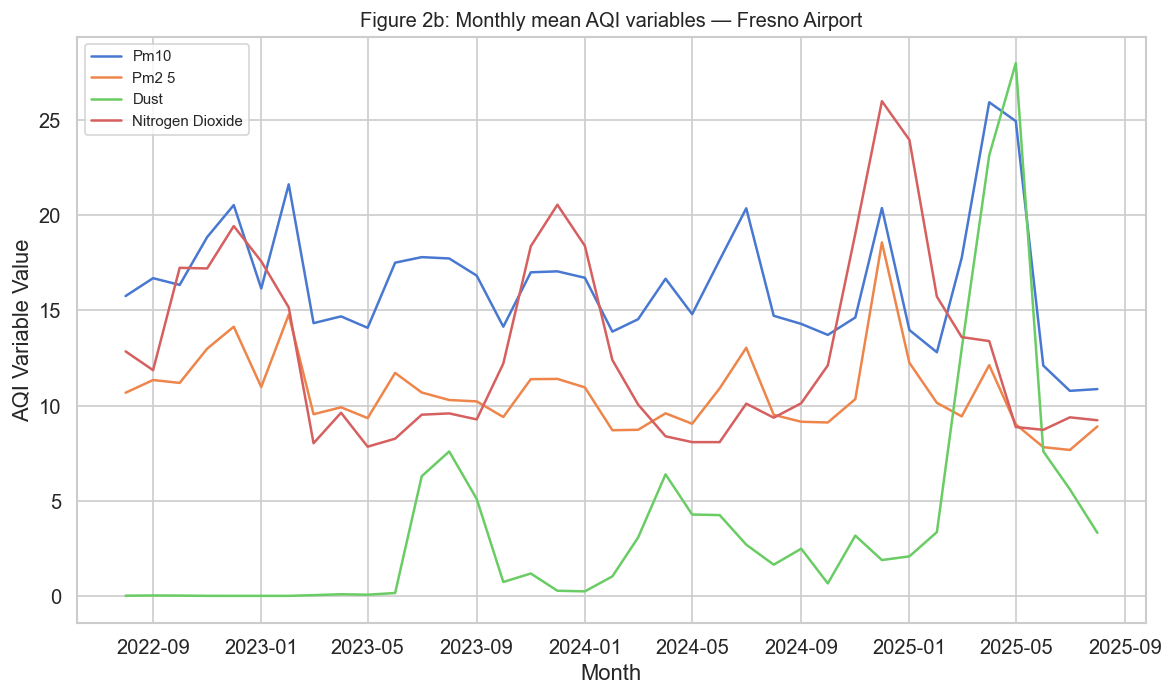

<div style='page-break-after: always;'></div>

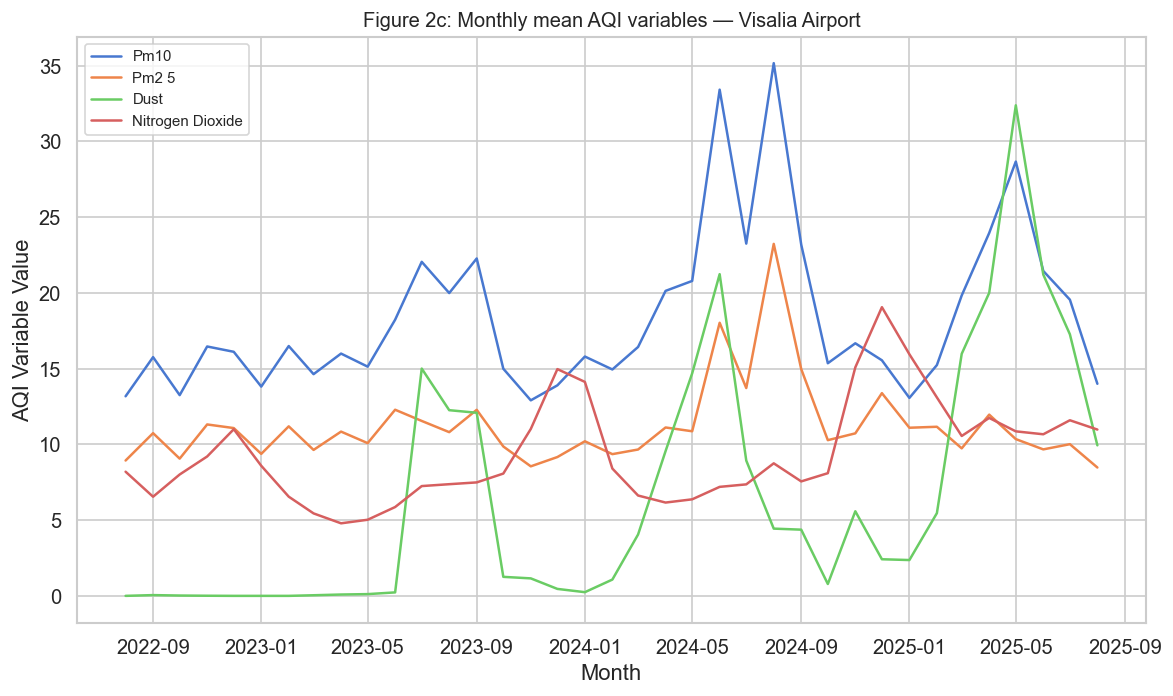

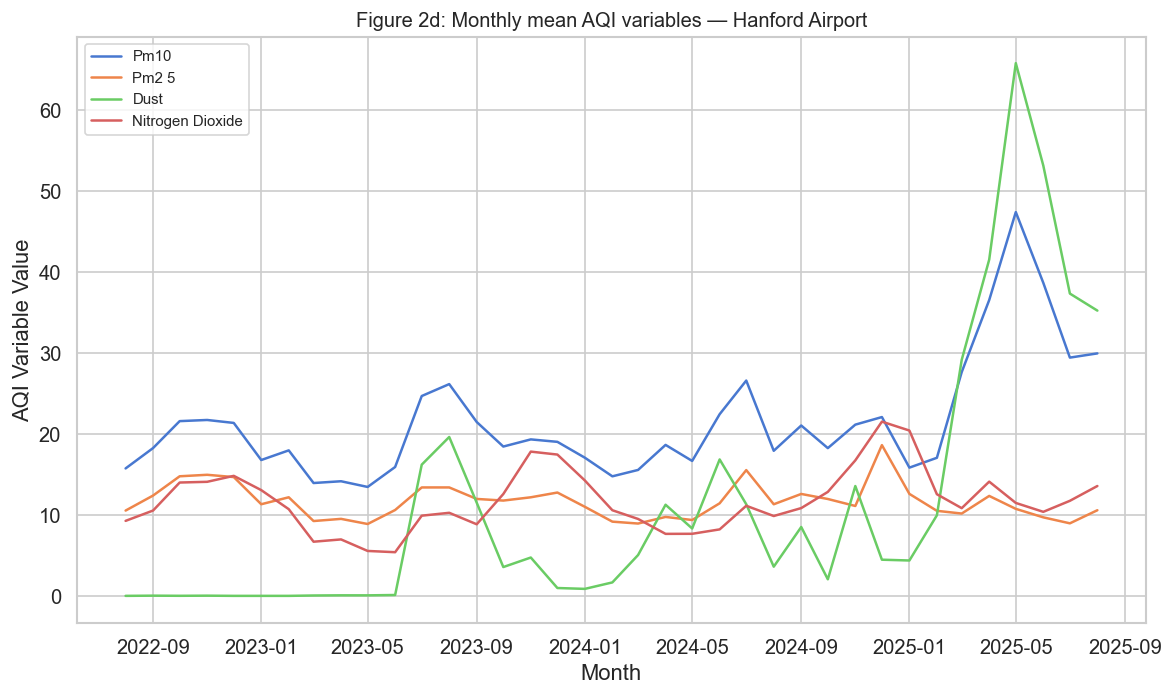

<div style='page-break-after: always;'></div>

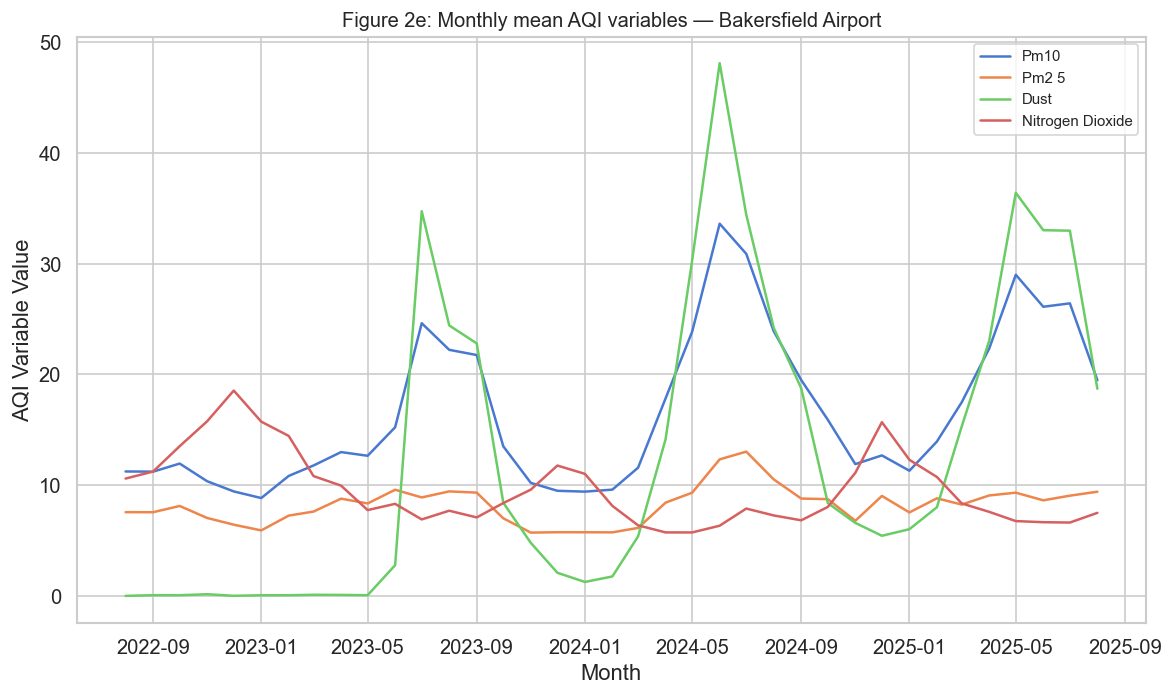

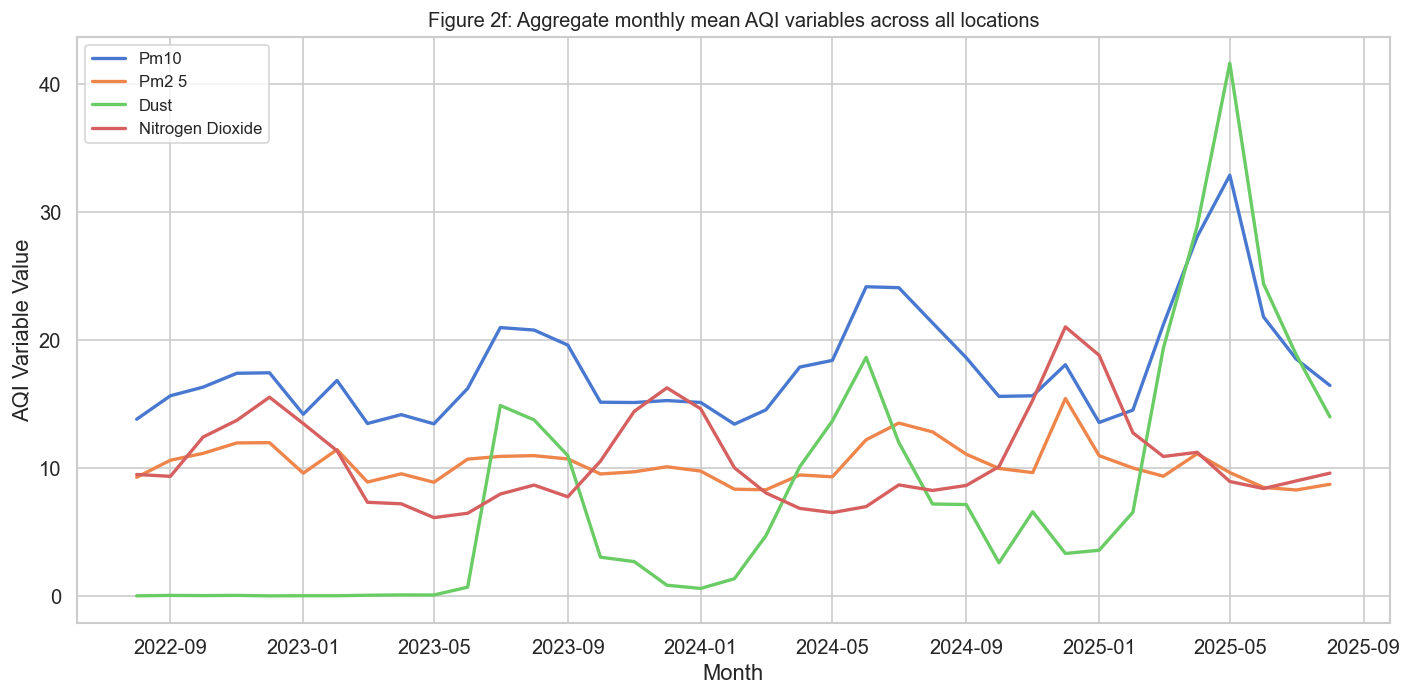

In [4]:
#| echo: false
from IPython.display import display, Markdown

AQI_VARS = ['pm10', 'pm2_5', 'dust', 'nitrogen_dioxide']

for loc_num, loc_info in data.items():

    fig, ax = plt.subplots(figsize=(10, 6))

    df = loc_info['with_aqi'].copy()
    df['date'] = pd.to_datetime(df['time'])
    df['year_month'] = df['date'].dt.to_period('M')

    for var in AQI_VARS:

        if var not in df.columns:
            continue

        monthly = df.groupby('year_month')[var].mean()
        monthly.index = monthly.index.to_timestamp()

        ax.plot(
            monthly.index,
            monthly.values,
            linewidth=1.5,
            label=var.replace('_', ' ').title()
        )

    ax.set_title(f"Figure 2{chr(96 + int(loc_num) - 5)}: Monthly mean AQI variables — {loc_info['name']}", fontsize=12)
    ax.set_xlabel('Month')
    ax.set_ylabel('AQI Variable Value')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    if loc_num in ['7', '9']:
        display(Markdown("<div style='page-break-after: always;'></div>"))

fig, ax = plt.subplots(figsize=(12, 6))

for var in AQI_VARS:
    combined = pd.concat(
        [
            loc_info['with_aqi'].assign(date=lambda x: pd.to_datetime(x['time']))[['date', var]]
            for loc_num, loc_info in data.items()
            if var in loc_info['with_aqi'].columns
        ]
    )

    monthly = combined.groupby(combined['date'].dt.to_period('M'))[var].mean()
    monthly.index = monthly.index.to_timestamp()

    ax.plot(
        monthly.index,
        monthly.values,
        linewidth=2,
        label=var.replace('_', ' ').title()
    )

ax.set_title("Figure 2f: Aggregate monthly mean AQI variables across all locations", fontsize=12)
ax.set_xlabel('Month')
ax.set_ylabel('AQI Variable Value')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

Examination of the monthly mean time series for PM10, PM2.5, dust, and nitrogen dioxide across the five airport locations reveals no strong systematic temporal trends over the 2022-present observation period. While the plots exhibit month-to-month variability consistent with meteorological influences, emission patterns, and measurement uncertainty, there are no obvious monotonic increases or decreases that would suggest fundamental shifts in air quality conditions during this timeframe. The absence of pronounced trends indicates that any year-to-year changes in air quality are relatively modest compared to the seasonal and short-term fluctuations inherent in these measurements.

This lack of strong temporal trends is methodologically advantageous for this fog prediction analysis. Had there been significant upward or downward drifts in pollutant concentrations coinciding with the declining fog frequency, this would have possibly introduced noise into the dataset, thereby undercutting model efficiency. This risk is especially exacerbated by the low amount of availably AQI data. In latter portions of this analysis, the limitations of the test/train split are discussed. Specifically, the limitation of the AQI-reliant dataset size results in only two full, complete years being available for analysis. Had there been a significant monotonic drifts in AQI variability, this would have possibly polluted one or both of the test/train datasets.

## Predictor Correlations with Visibility

To assess the linear relationships between predictor variables and visibility, Pearson correlation coefficients were computed for each variable group: **weather**, **AQI**, and **inferred**. The bar charts below present the average absolute correlation strength by variable category across all five airport locations; these values are sorted in descending order. These aggregated visualizations provide a high-level comparison of which variable groups exhibit the strongest relationships with visibility. Complete per-location Pearson correlation tables, showing individual correlation coefficients for each predictor at each airport, are available in **Appendix A**.

In [5]:
#| echo: false

import pandas as pd

WEATHER_VARS = [
    'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'precipitation',
    'rain', 'surface_pressure', 'et0_fao_evapotranspiration', 'vapour_pressure_deficit',
    'wind_speed_10m', 'wind_speed_100m', 'wind_gusts_10m', 'soil_temperature_0_to_7cm',
    'soil_temperature_7_to_28cm', 'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm'
]
INFERRED_VARS = ['dewpoint_depression', 'cooling_rate_6h', 'cooling_rate_12h', 'previous_night_low']

corr_results = {}
for loc_num, loc_info in data.items():
    loc_name = loc_info['name']
    corr_results[loc_name] = {}
    
    df_weather = loc_info['without_aqi'].copy()
    weather_available = [v for v in WEATHER_VARS if v in df_weather.columns]
    weather_corrs = {}
    for var in weather_available:
        if 'visibility_meters' in df_weather.columns:
            corr = df_weather[[var, 'visibility_meters']].corr().iloc[0, 1]
            weather_corrs[var] = corr
    corr_results[loc_name]['weather'] = weather_corrs
    
    inferred_available = [v for v in INFERRED_VARS if v in df_weather.columns]
    inferred_corrs = {}
    for var in inferred_available:
        if 'visibility_meters' in df_weather.columns:
            corr = df_weather[[var, 'visibility_meters']].corr().iloc[0, 1]
            inferred_corrs[var] = corr
    corr_results[loc_name]['inferred'] = inferred_corrs
    
    df_aqi = loc_info['with_aqi'].copy()
    aqi_available = [v for v in AQI_VARS if v in df_aqi.columns]
    aqi_corrs = {}
    for var in aqi_available:
        if 'visibility_meters' in df_aqi.columns:
            corr = df_aqi[[var, 'visibility_meters']].corr().iloc[0, 1]
            aqi_corrs[var] = corr
    corr_results[loc_name]['aqi'] = aqi_corrs


weather_rows = []
all_weather_vars = set()
for loc_name in corr_results:
    all_weather_vars.update(corr_results[loc_name]['weather'].keys())

for var in sorted(all_weather_vars):
    row = {'Weather Variable': var}
    for loc_name in corr_results:
        row[loc_name] = corr_results[loc_name]['weather'].get(var, None)
    
    vals = [v for v in row.values() if isinstance(v, (int, float)) and not pd.isna(v)]
    if vals:
        row['Mean Pearson r'] = sum(vals) / len(vals)
        row['Mean |r|'] = sum(abs(v) for v in vals) / len(vals)
    weather_rows.append(row)

agg_w = pd.DataFrame(weather_rows).sort_values('Mean |r|', ascending=False).reset_index(drop=True)
aqi_rows = []
all_aqi_vars = set()
for loc_name in corr_results:
    all_aqi_vars.update(corr_results[loc_name]['aqi'].keys())

for var in sorted(all_aqi_vars):
    row = {'AQI Variable': var}
    for loc_name in corr_results:
        row[loc_name] = corr_results[loc_name]['aqi'].get(var, None)
    
    vals = [v for v in row.values() if isinstance(v, (int, float)) and not pd.isna(v)]
    if vals:
        row['Mean Pearson r'] = sum(vals) / len(vals)
        row['Mean |r|'] = sum(abs(v) for v in vals) / len(vals)
    aqi_rows.append(row)

agg_a = pd.DataFrame(aqi_rows).sort_values('Mean |r|', ascending=False).reset_index(drop=True)
inferred_rows = []
all_inferred_vars = set()
for loc_name in corr_results:
    all_inferred_vars.update(corr_results[loc_name]['inferred'].keys())

for var in sorted(all_inferred_vars):
    row = {'Inferred Variable': var}
    for loc_name in corr_results:
        row[loc_name] = corr_results[loc_name]['inferred'].get(var, None)
    
    vals = [v for v in row.values() if isinstance(v, (int, float)) and not pd.isna(v)]
    if vals:
        row['Mean Pearson r'] = sum(vals) / len(vals)
        row['Mean |r|'] = sum(abs(v) for v in vals) / len(vals)
    inferred_rows.append(row)

agg_i = pd.DataFrame(inferred_rows).sort_values('Mean |r|', ascending=False).reset_index(drop=True)

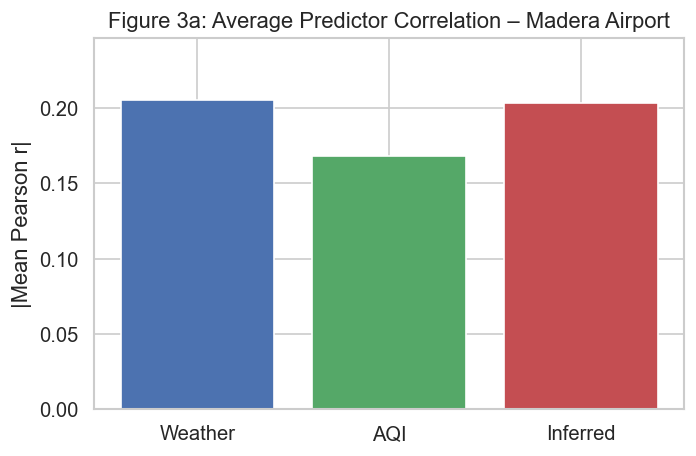

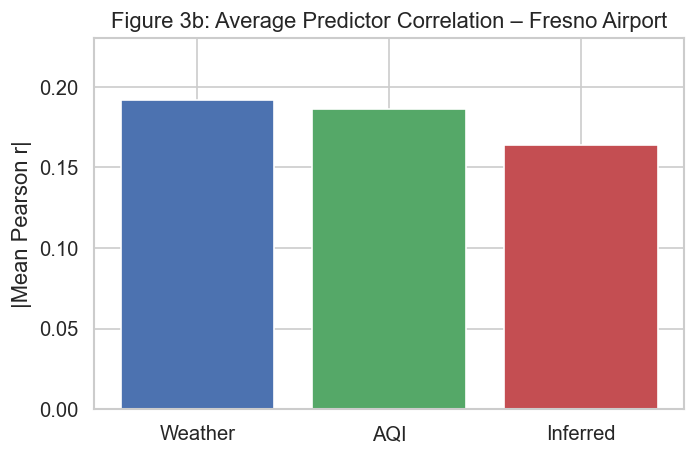

<div style='page-break-after: always;'></div>

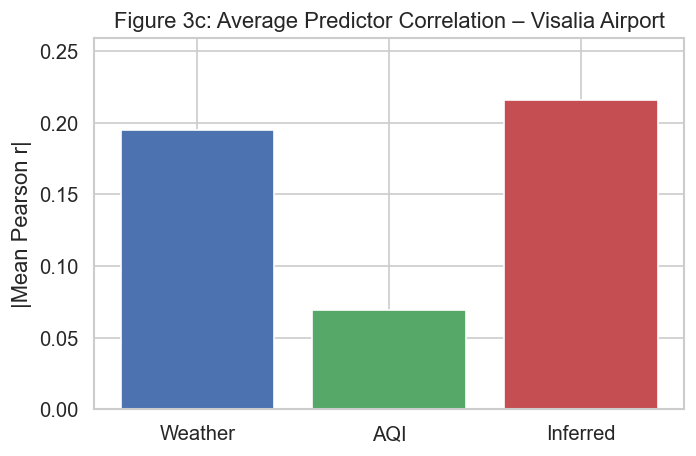

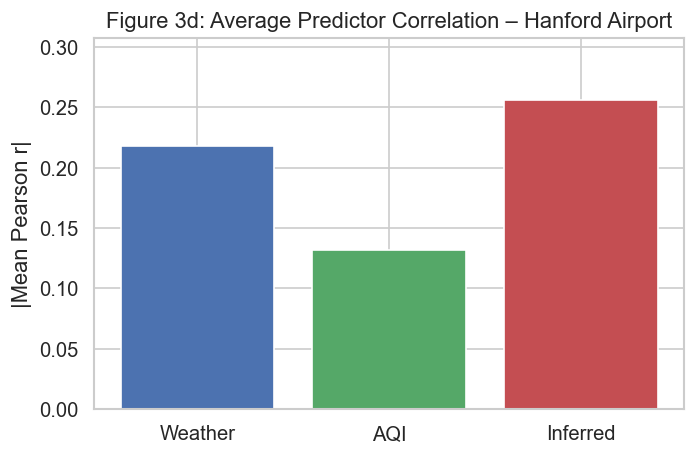

<div style='page-break-after: always;'></div>

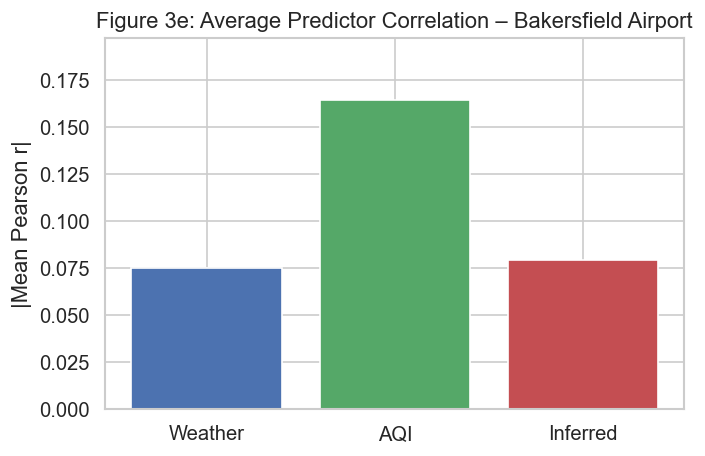

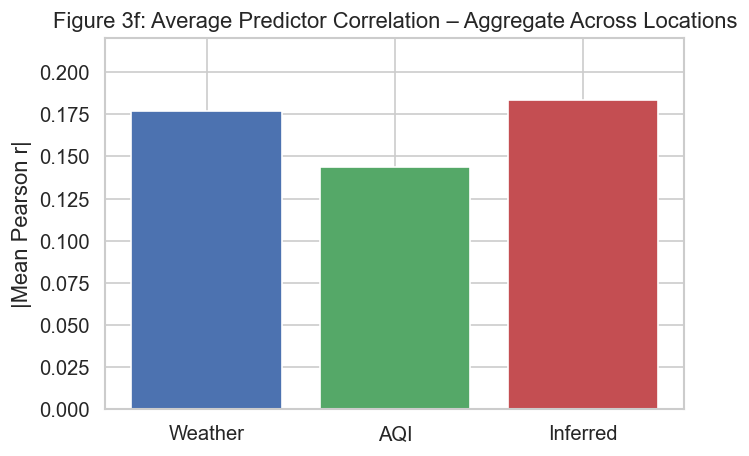

In [6]:
#| echo: false
#| fig-show: separate

from IPython.display import display, Markdown
import matplotlib.pyplot as plt

categories = {
    "Weather": agg_w,
    "AQI": agg_a,
    "Inferred": agg_i
}

for idx, (loc_num, loc_info) in enumerate(data.items(), start=1):
    loc_name = loc_info['name']
    means = []

    for cat_name, cat_table in categories.items():
        if loc_name in cat_table.columns:
            mean_abs_r = cat_table[loc_name].abs().mean()
            means.append(mean_abs_r)
        else:
            means.append(0)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(categories.keys(), means, color=['#4c72b0', '#55a868', '#c44e52'])
    ax.set_ylabel('|Mean Pearson r|')
    ax.set_title(f'Figure 3{chr(96 + idx)}: Average Predictor Correlation – {loc_name}')
    ax.set_ylim(0, max(means)*1.2 if max(means) > 0 else 1)
    plt.tight_layout()
    plt.show()

    if idx % 2 == 0:
        display(Markdown("<div style='page-break-after: always;'></div>"))

agg_means = []
for cat_name, cat_table in categories.items():
    location_cols = [c for c in cat_table.columns 
                     if c not in ['Weather Variable', 'AQI Variable', 'Inferred Variable', 
                                  'Mean Pearson r', 'Mean |r|']]
    if location_cols:
        agg_means.append(cat_table[location_cols].abs().mean().mean())
    else:
        agg_means.append(0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(categories.keys(), agg_means, color=['#4c72b0', '#55a868', '#c44e52'])
ax.set_ylabel('|Mean Pearson r|')
ax.set_title(f'Figure 3f: Average Predictor Correlation – Aggregate Across Locations')
ax.set_ylim(0, max(agg_means)*1.2 if max(agg_means) > 0 else 1)
plt.tight_layout()
plt.show()

The aggregate correlation analysis reveals that raw weather and inferred variables exhibit the strongest average linear relationship with visibility, followed by AQI variables showing the weakest but still meaningful correlations. Despite AQI variables having lower average absolute Pearson correlation coefficients compared to the weather and inferred predictors, their correlations remain statistically relevant and justify their inclusion as candidate features in fog prediction models. The reduced correlation strength is expected given the limited temporal coverage of AQI data compared to the multi-decadal weather records, which constrains the sample size available for estimating these relationships.

Importantly, the correlation strength of AQI variables exhibits substantial spatial heterogeneity across the five airport locations. The enhanced AQI signal at Bakersfield may reflect local emission patterns, topographic influences on pollutant accumulation, or site-specific meteorological regimes that amplify the relationship between air quality and visibility conditions. These location-dependent differences underscore the value of training separate models for each airport rather than pooling data across sites.

# Feature Distributions: Fog vs. Non-Fog

## Examination of Weather Variables

To understand how individual predictors differ between fog and non-fog conditions, their distributions were compared using box plots. Features are z-score standardized to allow comparison on a common axis. Separate plots are shown for **weather variables**, **AQI variables**, and **inferred variables** at each airport and in aggregate.

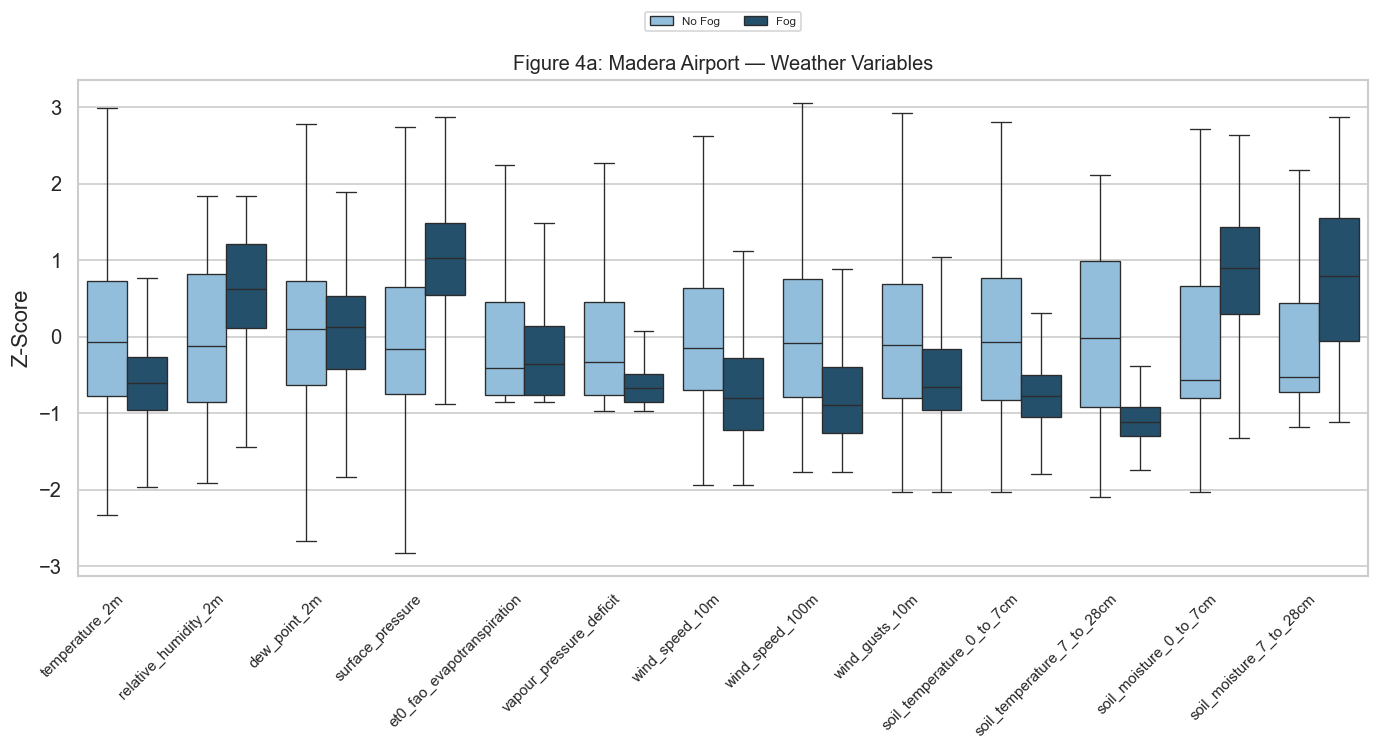

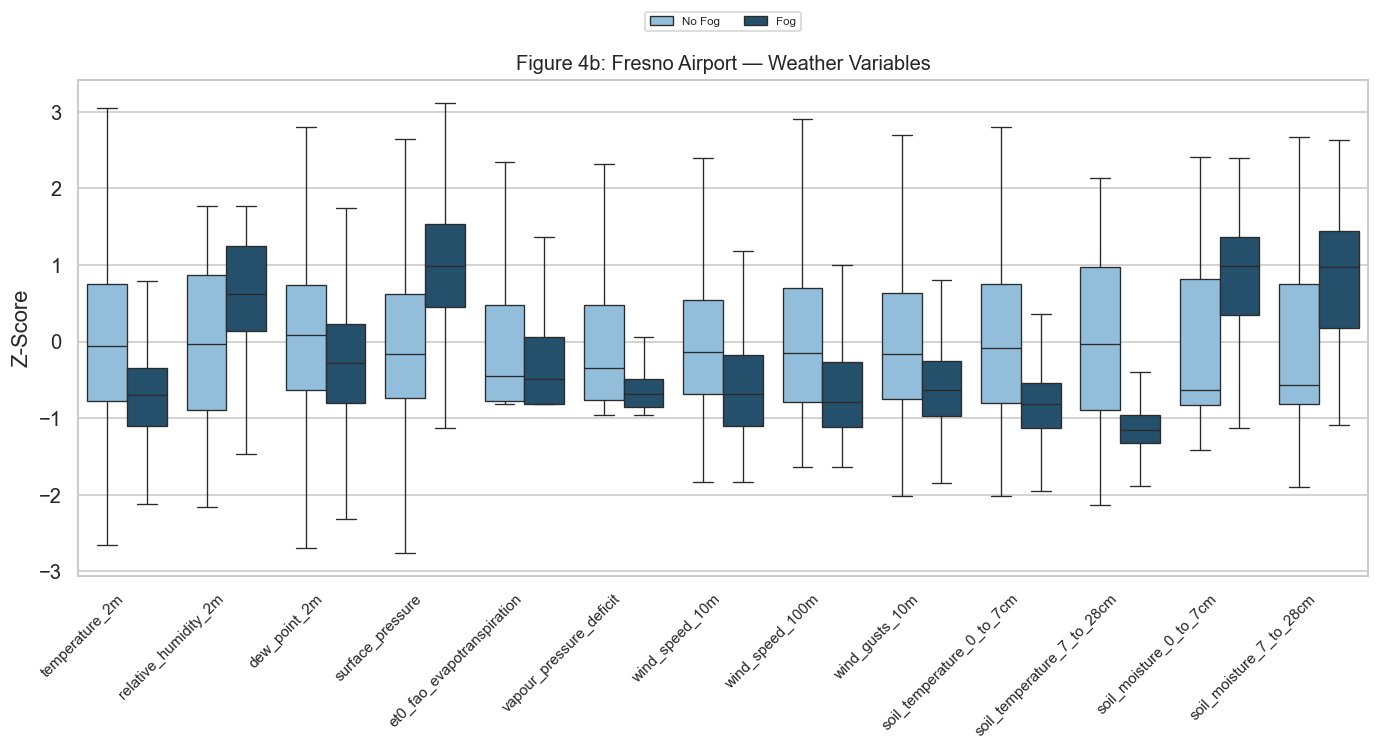

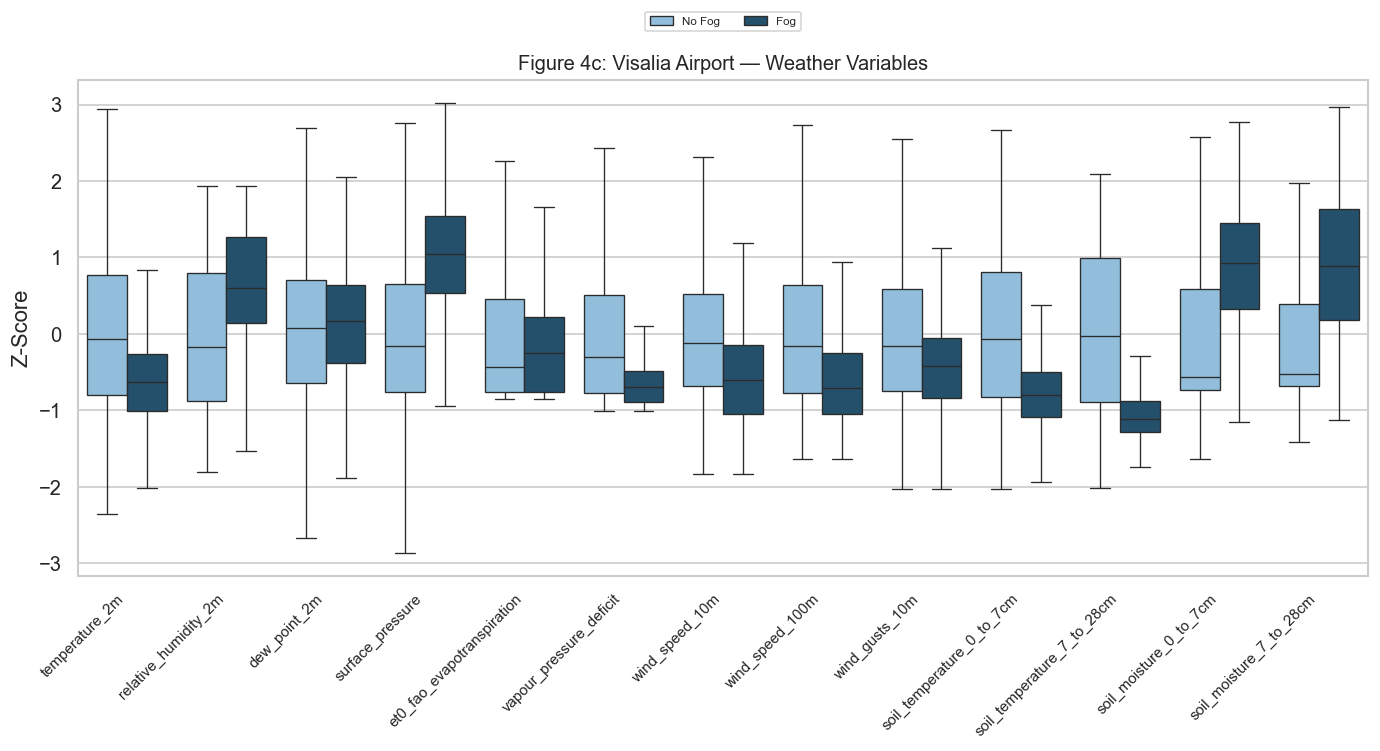

<div style='page-break-after: always;'></div>

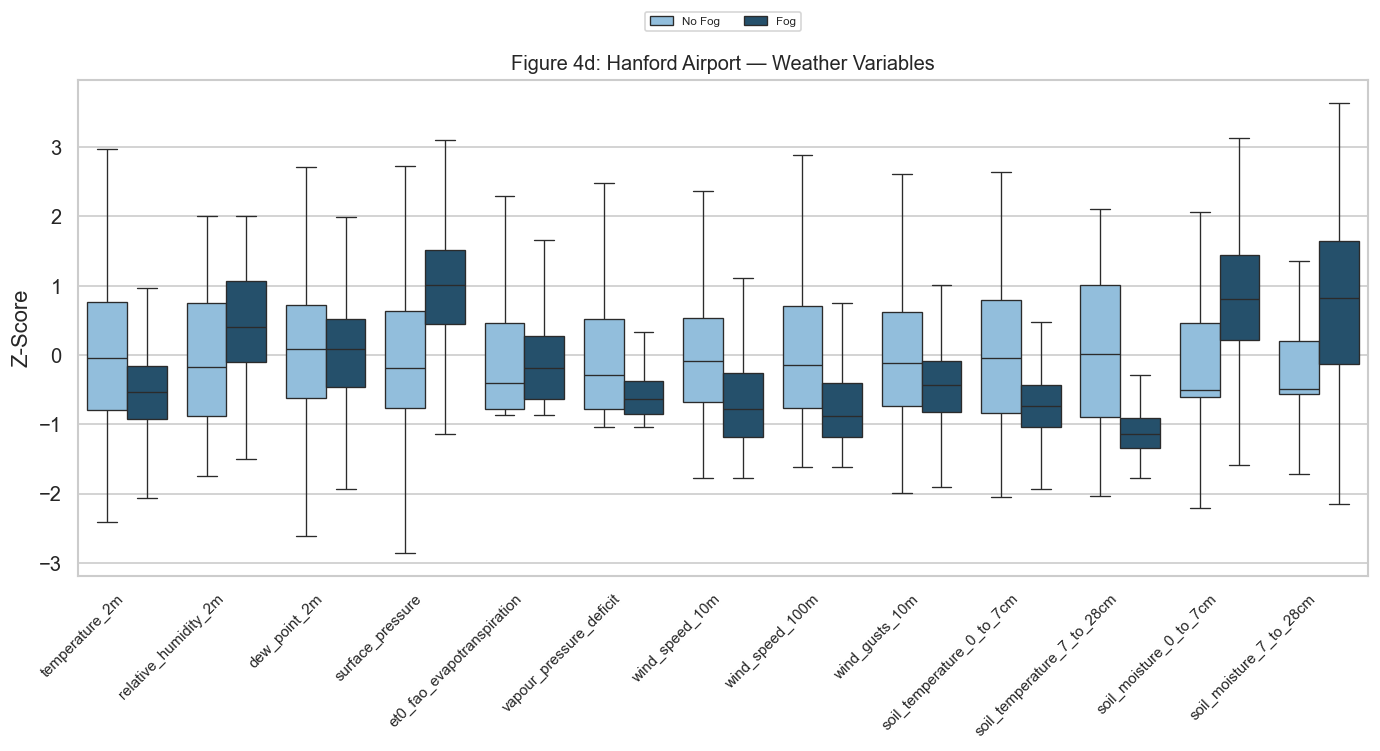

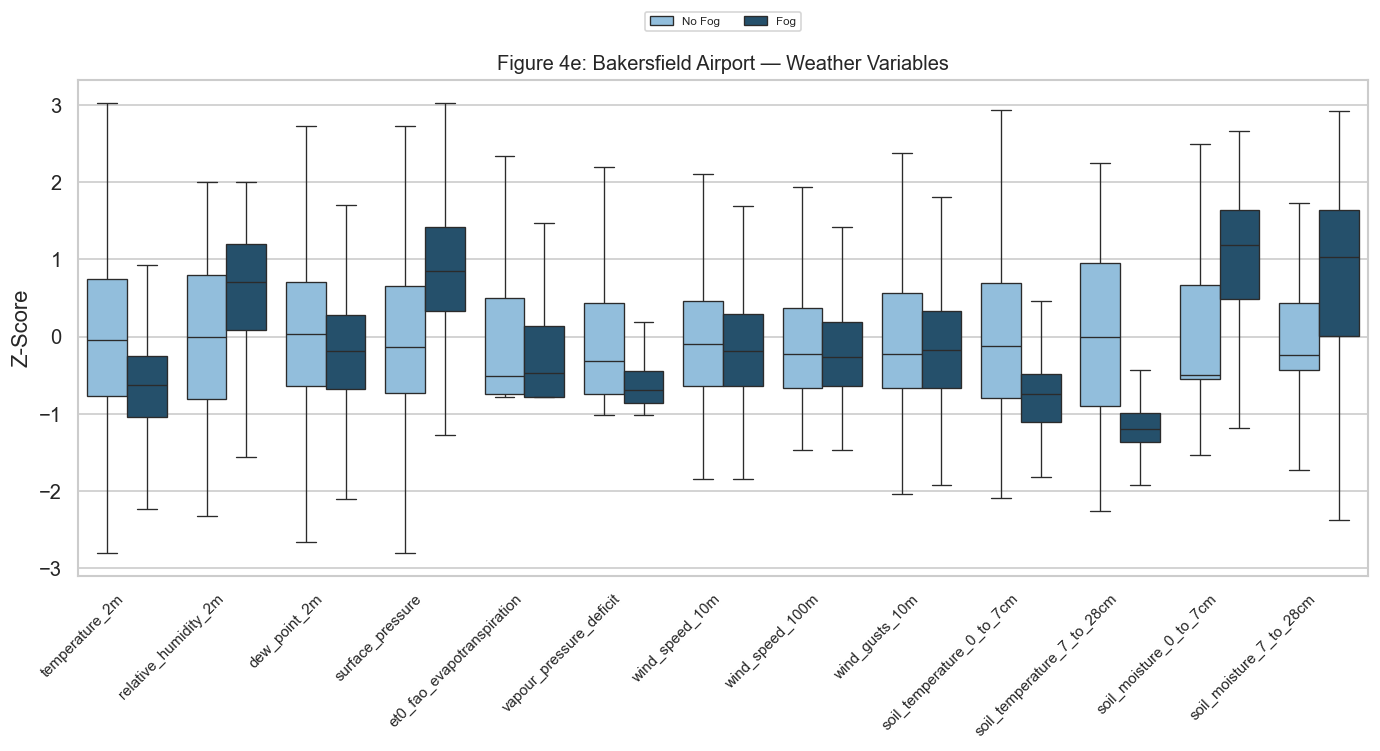

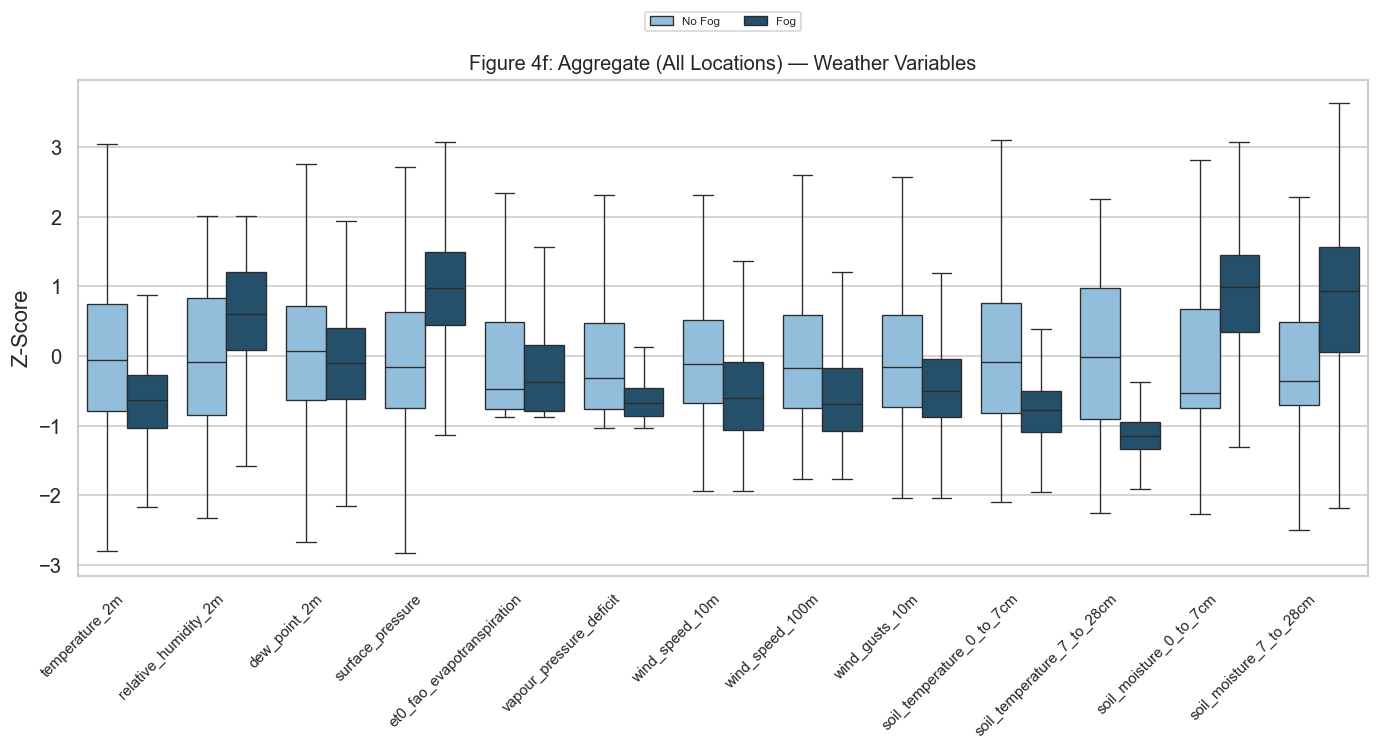

In [7]:
#| echo: false

BLUE_FOG = '#1a5276'
BLUE_NOFOG = '#85c1e9'

def make_boxplots_separate(data_dict, features, group_label, use_aqi_df=False):
    features = [f for f in features if f not in ('rain', 'precipitation')]
    all_dfs = []
    for idx, (loc_num, loc_info) in enumerate(data_dict.items(), start=1):
        df = loc_info['with_aqi'].copy() if use_aqi_df else loc_info['without_aqi'].copy()
        cols = [c for c in features if c in df.columns]
        if not cols:
            continue
        
        for feat in cols:
            mu, sigma = df[feat].mean(), df[feat].std()
            if sigma > 0:
                df[feat] = (df[feat] - mu) / sigma

        melted = df[cols + ['fog']].melt(id_vars='fog', var_name='Feature', value_name='Z-Score')
        melted['Condition'] = melted['fog'].map({0: 'No Fog', 1: 'Fog'})
        all_dfs.append(df[cols + ['fog']])
        
        fig_height = max(5, 4 + len(cols)*0.2)  # taller cuz many features
        fig, ax = plt.subplots(figsize=(max(10, len(cols)*0.9), fig_height))
        sns.boxplot(data=melted, x='Feature', y='Z-Score', hue='Condition', ax=ax,
                    showfliers=False, fliersize=1, linewidth=0.8,
                    palette={'No Fog': BLUE_NOFOG, 'Fog': BLUE_FOG})
        ax.set_title(f'Figure 4{chr(96+idx)}: {loc_info["name"]} — {group_label}', fontsize=12)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
        ax.set_xlabel('')

        ax.legend(fontsize=7, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)

        plt.tight_layout()
        plt.show()

        if idx % 3 == 0:
            display(Markdown("<div style='page-break-after: always;'></div>"))
    
    if all_dfs:
        combined_df = pd.concat(all_dfs, ignore_index=True)
        melted_all = combined_df.melt(id_vars='fog', var_name='Feature', value_name='Z-Score')
        melted_all['Condition'] = melted_all['fog'].map({0: 'No Fog', 1: 'Fog'})
        fig_height = max(5, 4 + len(features)*0.2)
        fig, ax = plt.subplots(figsize=(max(10, len(features)*0.9), fig_height))
        sns.boxplot(data=melted_all, x='Feature', y='Z-Score', hue='Condition', ax=ax,
                    showfliers=False, fliersize=1, linewidth=0.8,
                    palette={'No Fog': BLUE_NOFOG, 'Fog': BLUE_FOG})
        ax.set_title(f'Figure 4f: Aggregate (All Locations) — {group_label}', fontsize=12)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
        ax.set_xlabel('')
        ax.legend(fontsize=7, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)
        plt.tight_layout()
        plt.show()

make_boxplots_separate(data, WEATHER_VARS, 'Weather Variables')

The box plot distributions reveal systematic differences in predictor values between fog and non-fog conditions that align with the fundamental physics of radiation fog formation. Fog events exhibit significantly higher standardized values for relative humidity, surface pressure, evapotranspiration, and soil moisture at both the 0-7 cm and 7-28 cm depths. Conversely, fog conditions are associated with lower values for temperature, dew point depression, wind speeds, wind gusts, soil temperature at both measurement depths, and vapor pressure deficit. These distributional patterns are strongly consistent with the established meteorological conditions that promote radiation fog development. Overall, there appears a distinct, measurable signal within all variables that should promote binary classification via machine learning.

## Examination of Rain & Precipitation

The precipitation and rain variables were intentionally excluded from the weather variable box plots presented above due to their extremely low incidence rates across all locations. As shown in the table below, these variables have zero values for the vast majority of observations (>95% across all locations). This reflects the semi-arid climate of the San Joaquin Valley where precipitation events are rare. When included in the standardized box plots alongside other weather variables, the high frequency of zero values causes the interquartile ranges to collapse near zero, producing compressed box plots that are visually uninformative and difficult to interpret relative to the other predictors.

To meaningfully examine the distributions of precipitation and rain during fog versus non-fog conditions, a conditional analysis was applied that filters the dataset to include only observations where precipitation or rain values are strictly greater than zero. This subset provides a more interpretable comparison of how these variables behave when precipitation is actually occurring. The filtered box plots below present the fog versus non-fog distributions for this precipitation-active subset of the data.

In [8]:
#| echo: false

rows = []

for loc_num, loc_info in data.items():
    df = loc_info['without_aqi']
    zero_frac = (df[['precipitation', 'rain']] == 0).mean().round(2)

    rows.append({
        "Location": loc_info['name'],
        "Precipitation = 0 (%)": zero_frac['precipitation'],
        "Rain = 0 (%)": zero_frac['rain']
    })

zero_table = pd.DataFrame(rows)

display(zero_table)

,Location,Precipitation = 0 (%),Rain = 0 (%)
0,Madera Airport,0.95,0.95
1,Fresno Airport,0.94,0.94
2,Visalia Airport,0.95,0.95
3,Hanford Airport,0.96,0.96
4,Bakersfield Airport,0.94,0.94


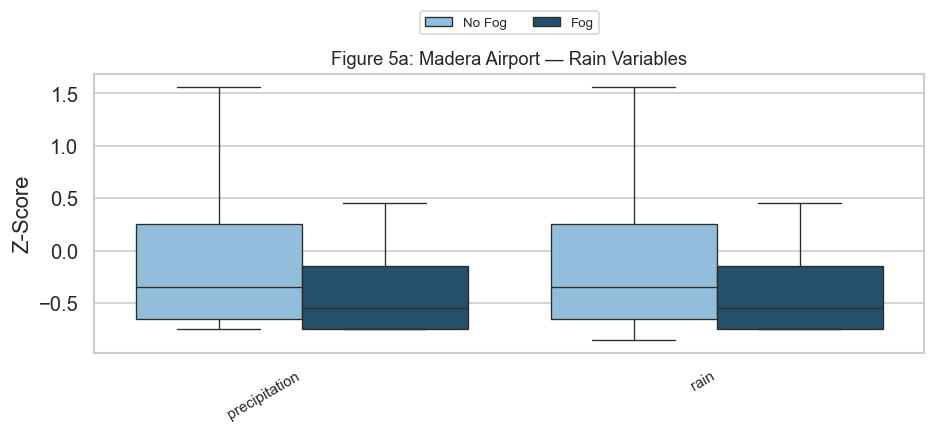

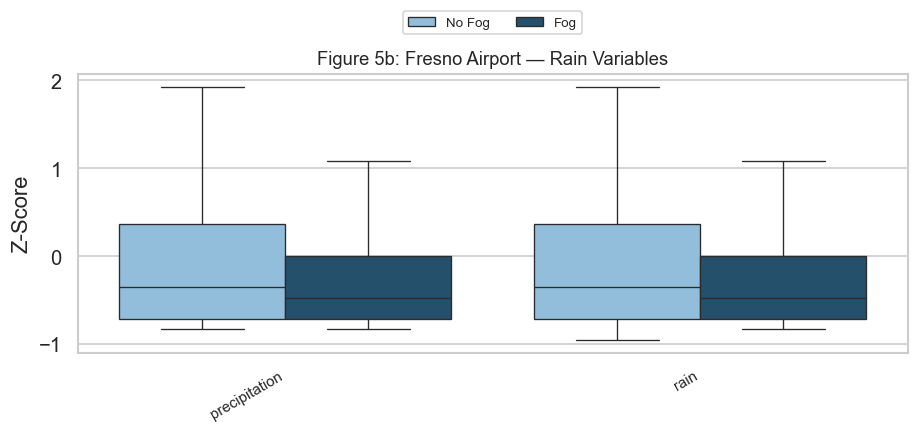

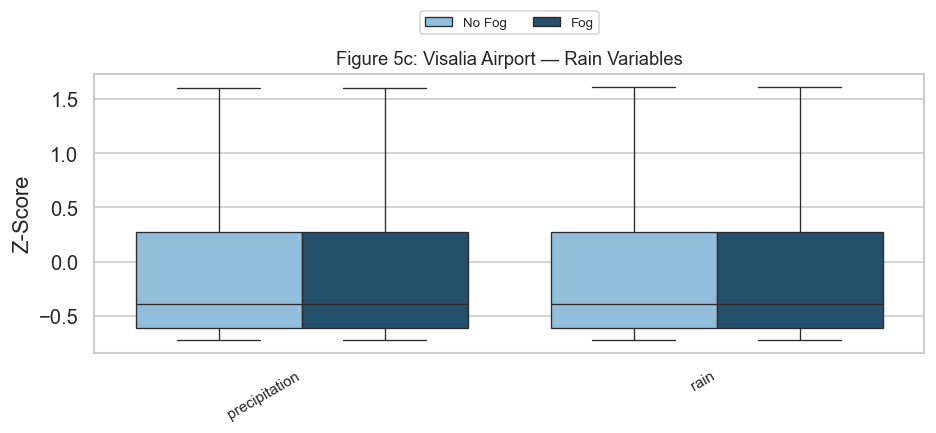

<div style='page-break-after: always;'></div>

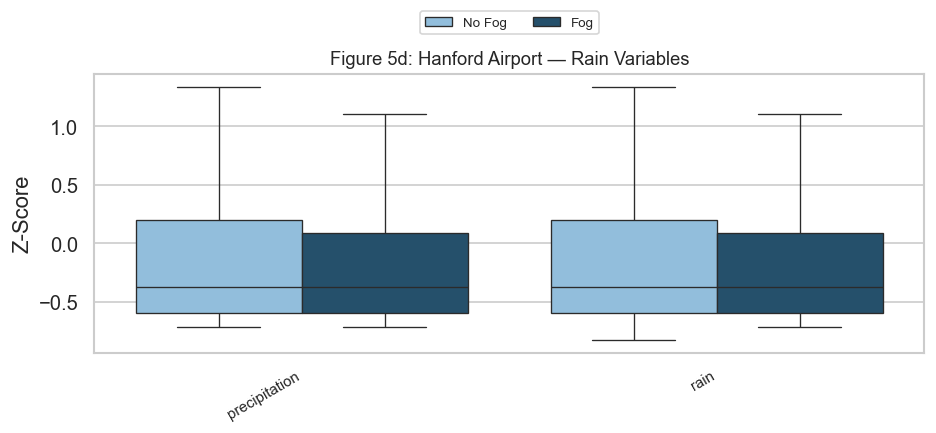

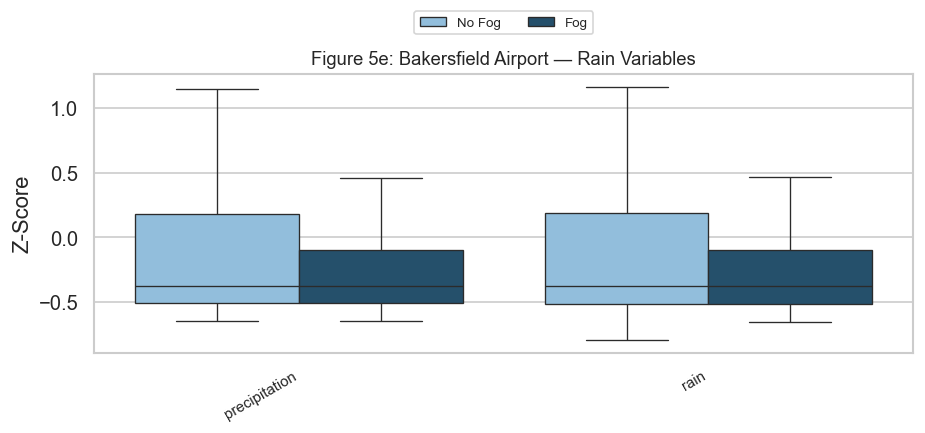

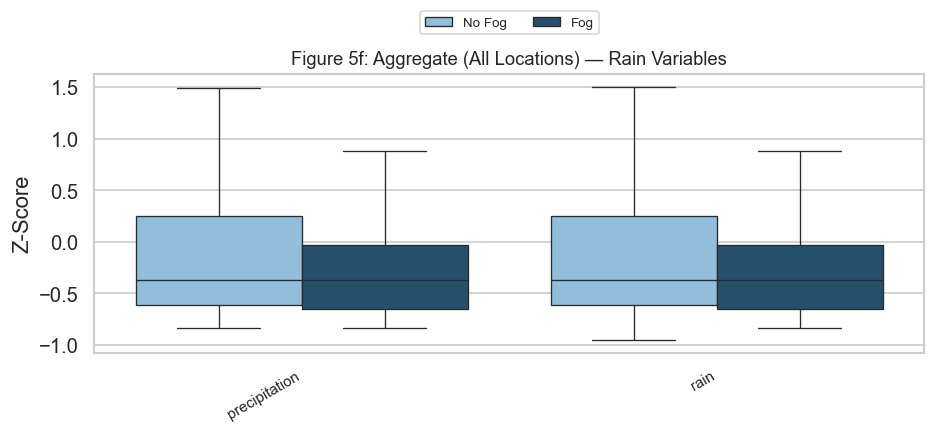

In [9]:
#| echo: false

RAIN_VARS = ['precipitation', 'rain']

BLUE_FOG = '#1a5276'
BLUE_NOFOG = '#85c1e9'

def make_rain_boxplots_separate(data_dict, group_label='Rain Variables'):
    all_dfs = []

    for idx, (loc_num, loc_info) in enumerate(data_dict.items(), start=1):
        df = loc_info['without_aqi'].copy()

        # only rows where rain or precipitation > 0
        df = df[(df['precipitation'] > 0) | (df['rain'] > 0)]
        if df.empty:
            continue

        for var in RAIN_VARS:
            mu, sigma = df[var].mean(), df[var].std()
            if sigma > 0:
                df[var] = (df[var] - mu) / sigma

        melted = df[RAIN_VARS + ['fog']].melt(
            id_vars='fog',
            var_name='Feature',
            value_name='Z-Score'
        )
        melted['Condition'] = melted['fog'].map({0: 'No Fog', 1: 'Fog'})
        all_dfs.append(df[RAIN_VARS + ['fog']])

        fig, ax = plt.subplots(figsize=(8, 4))
        sns.boxplot(
            data=melted,
            x='Feature',
            y='Z-Score',
            hue='Condition',
            ax=ax,
            showfliers=False,
            linewidth=0.8,
            palette={'No Fog': BLUE_NOFOG, 'Fog': BLUE_FOG}
        )

        ax.set_title(f"Figure 5{chr(96+idx)}: {loc_info['name']} — {group_label}", fontsize=11)
        ax.set_xlabel('')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)

        ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2)

        plt.tight_layout()
        plt.show()

        if idx % 3 == 0:
            display(Markdown("<div style='page-break-after: always;'></div>"))

    if all_dfs:
        combined_df = pd.concat(all_dfs, ignore_index=True)
        melted_all = combined_df.melt(
            id_vars='fog',
            var_name='Feature',
            value_name='Z-Score'
        )
        melted_all['Condition'] = melted_all['fog'].map({0: 'No Fog', 1: 'Fog'})

        fig, ax = plt.subplots(figsize=(8, 4))
        sns.boxplot(
            data=melted_all,
            x='Feature',
            y='Z-Score',
            hue='Condition',
            ax=ax,
            showfliers=False,
            linewidth=0.8,
            palette={'No Fog': BLUE_NOFOG, 'Fog': BLUE_FOG}
        )

        ax.set_title(f"Figure 5f: Aggregate (All Locations) — {group_label}", fontsize=11)
        ax.set_xlabel('')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
        ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2)

        plt.tight_layout()
        plt.show()

make_rain_boxplots_separate(data)

When examining only observations with non-zero precipitation or rain, the box plot distributions show subtle albeit meaningful differences between fog and non-fog conditions despite having similar mean values. The central tendencies of precipitation during fog versus non-fog events appear comparable, suggesting that precipitation intensity alone may not strongly differentiate these conditions. However, the box plots consistently show differences in the interquartile ranges, whisker extents, and overall distributional shapes between the two classes across locations.

These distributional differences are particularly relevant because precipitation and rain variables exhibit strongly left-skewed distributions when filtered to non-zero values. This skewness implies that summary statistics like the mean can be misleading, as they do not fully capture the shape of the distribution. however, the box plots, when considered within their contexts, reveal that fog and non-fog conditions differ not just in average precipitation amount, but in the spread and quantile structure of the distributions. These shape differences may reflect distinct meteorological processes: fog associated with lighter, more persistent drizzle versus non-fog conditions experiencing heavier, convective-type precipitation. Consequently, even modest distributional shifts visible in the box plots represent physically meaningful differences in precipitation characteristics that could inform model predictions, despite the similarity in mean values.

An important caveat in the above analysis is the possibility of causal ambiguity in the relationship between precipitation and observed fog events. In the above analysis, the conditions are categorized as "fog" when the reduced visibility is less than the 1-mile (1610 m) threshold, without regard to the underlying meteorological process. The larger context in which this analysis is performed deals with the phenomenon of radiation fog, while precipitation can result in reduced visibility through several mechanisms. This implies the possibility that the conditions categorized as "fog" in the data could be the result of reduced visibility caused by precipitation, as opposed to the traditional phenomenon of radiation fog. This, however, does not detract from the categorization as "fog," as reduced visibility is a genuine operational hazard, irrespective of the underlying process. However, this implies that the models using precipitation features could be improved by including this as an additional type of fog, even though this could be a small percentage of the total number of fog events in the semi-arid region of the San Joaquin Valley.

## Examination of AQI Variables

The following analysis examines the distributions of air quality variables (PM10, PM2.5, dust, and nitrogen dioxide) during fog versus non-fog conditions using the same z-score standardization and box plot methodology applied to the weather variables. These box plots are based on the subset of data where AQI measurements are available (2022-present).

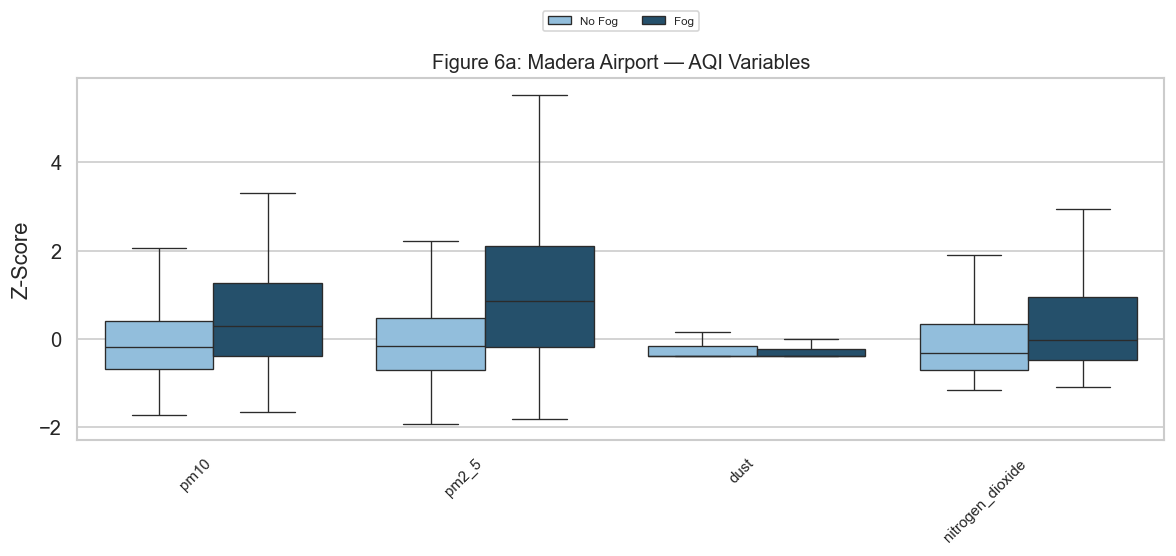

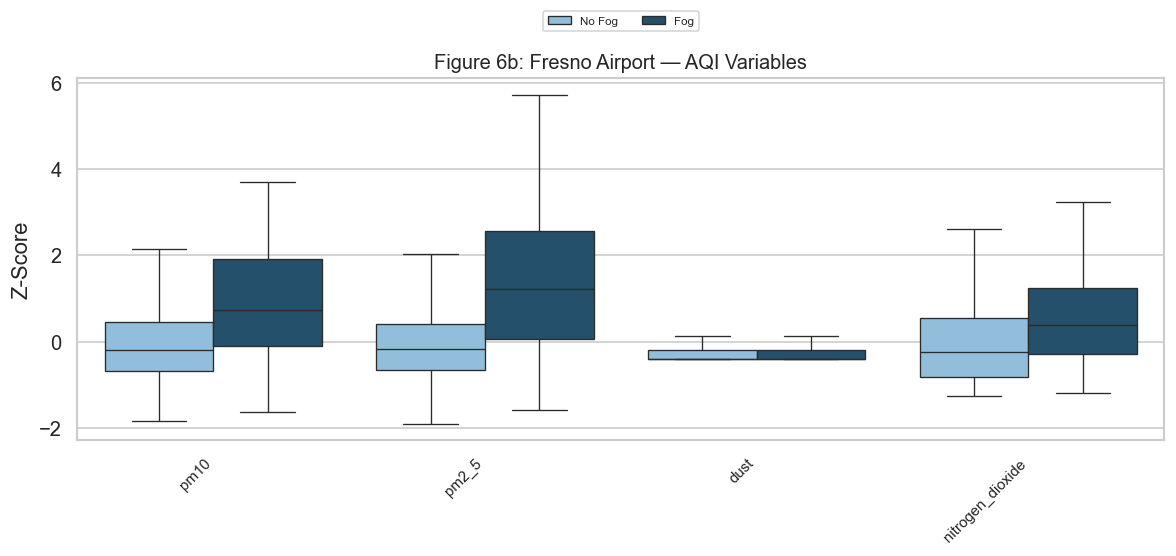

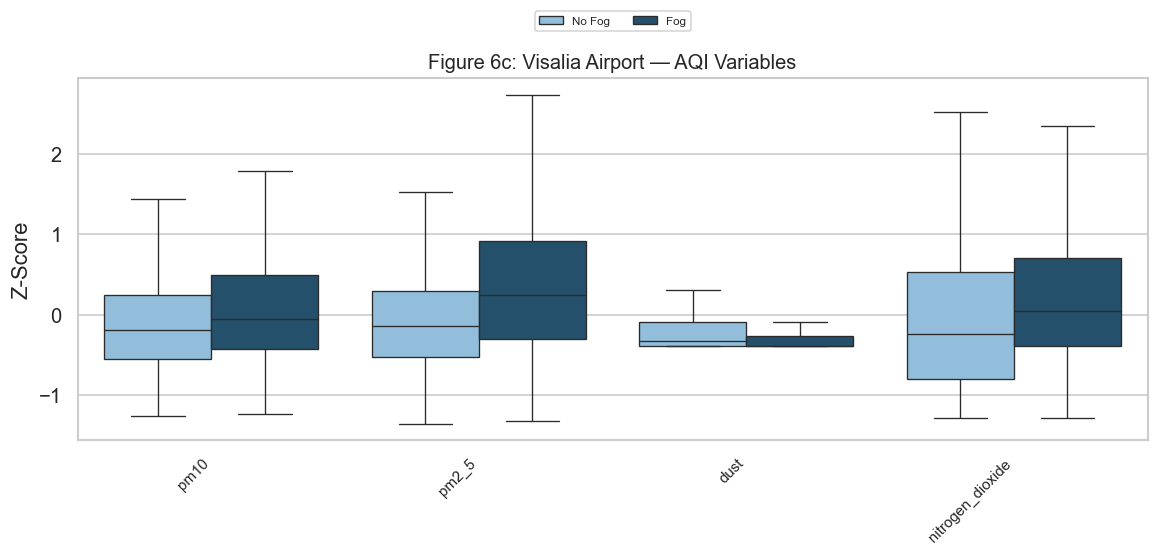

<div style='page-break-after: always;'></div>

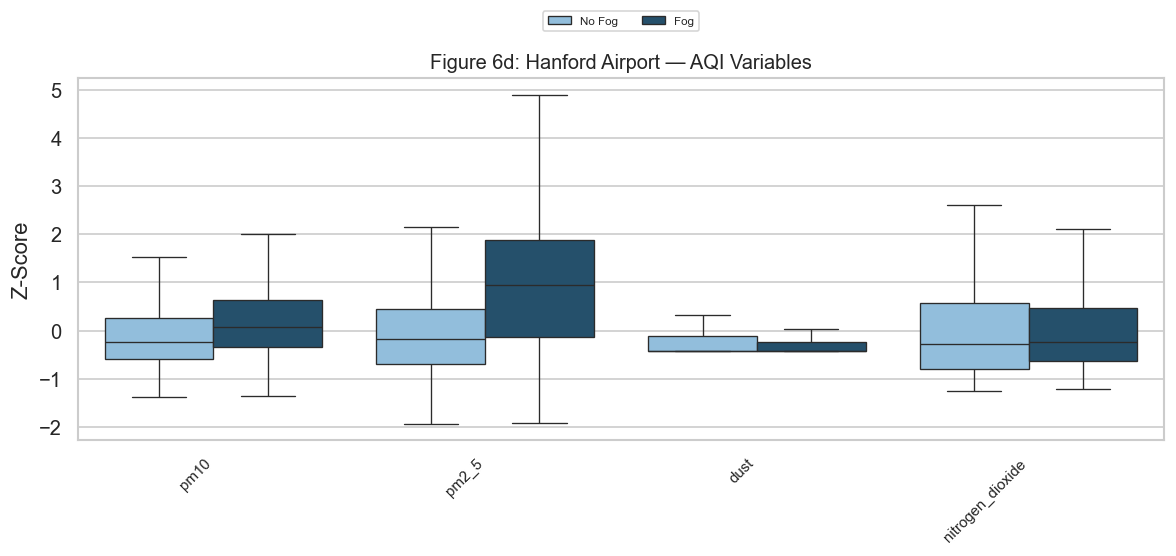

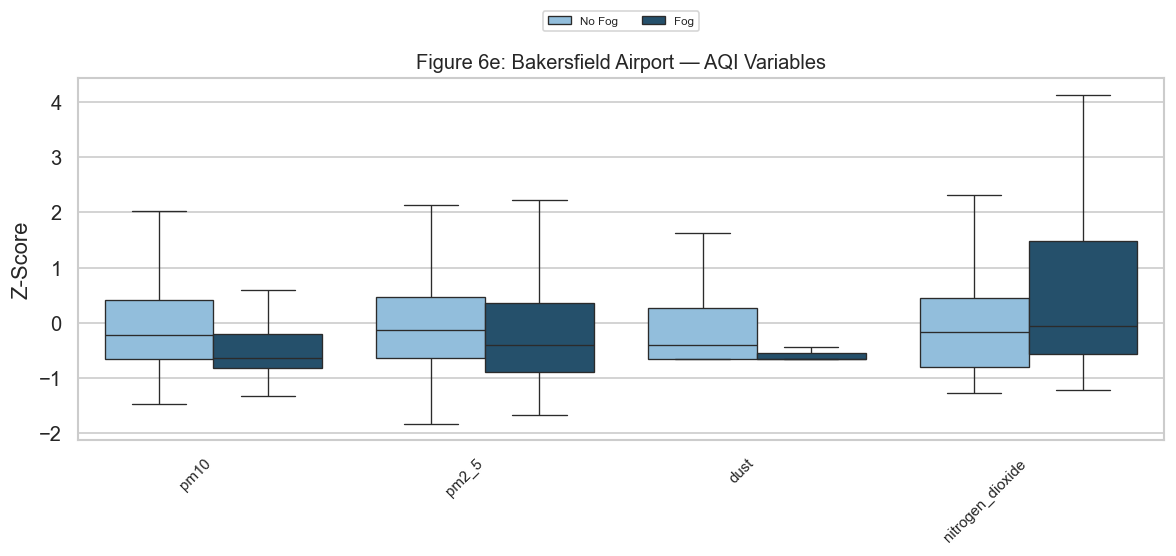

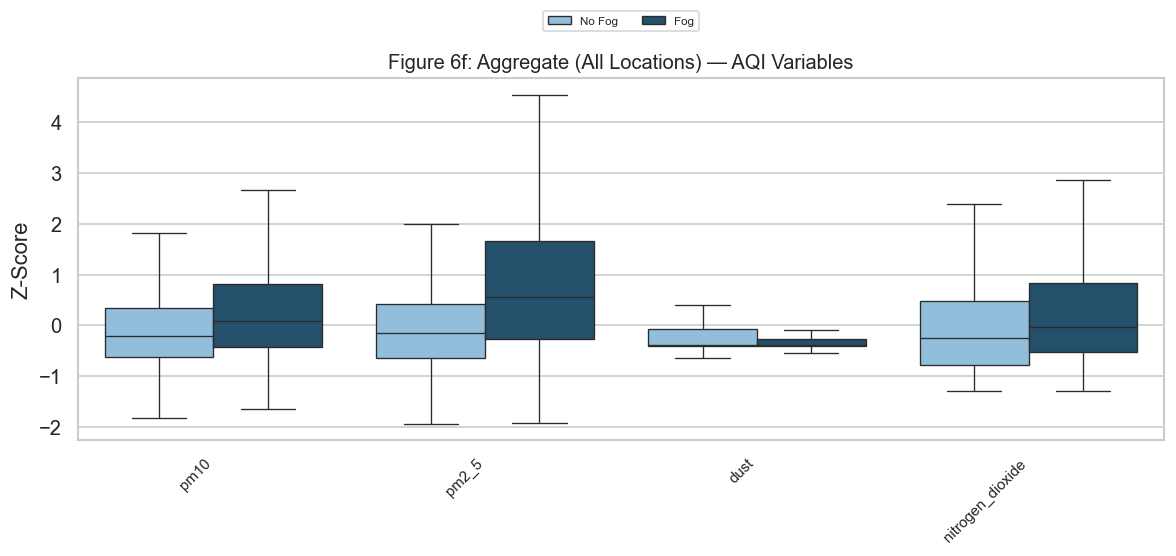

In [10]:
#| echo: false

BLUE_FOG = '#1a5276'
BLUE_NOFOG = '#85c1e9'

def make_aqi_boxplots(data_dict, features, group_label='AQI Variables'):
    all_dfs = []

    for idx, (loc_num, loc_info) in enumerate(data_dict.items(), start=1):
        df = loc_info['with_aqi'].copy()  # use aqi
        cols = [c for c in features if c in df.columns]
        if not cols:
            continue

        for feat in cols:
            mu, sigma = df[feat].mean(), df[feat].std()
            if sigma > 0:
                df[feat] = (df[feat] - mu) / sigma

        melted = df[cols + ['fog']].melt(
            id_vars='fog', var_name='Feature', value_name='Z-Score'
        )
        melted['Condition'] = melted['fog'].map({0: 'No Fog', 1: 'Fog'})
        all_dfs.append(df[cols + ['fog']])

        fig_height = max(5, 4 + len(cols) * 0.2)
        fig_width = max(10, len(cols) * 0.9)
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))
        sns.boxplot(
            data=melted,
            x='Feature',
            y='Z-Score',
            hue='Condition',
            ax=ax,
            showfliers=False,
            linewidth=0.8,
            palette={'No Fog': BLUE_NOFOG, 'Fog': BLUE_FOG}
        )
        ax.set_title(f"Figure 6{chr(96+idx)}: {loc_info['name']} — {group_label}", fontsize=12)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
        ax.set_xlabel('')
        ax.legend(fontsize=7, loc='upper center', bbox_to_anchor=(0.5, 1.20), ncol=2)

        plt.tight_layout()
        plt.show()

        if idx % 3 == 0:
            display(Markdown("<div style='page-break-after: always;'></div>"))

    if all_dfs:
        combined_df = pd.concat(all_dfs, ignore_index=True)
        melted_all = combined_df.melt(
            id_vars='fog', var_name='Feature', value_name='Z-Score'
        )
        melted_all['Condition'] = melted_all['fog'].map({0: 'No Fog', 1: 'Fog'})

        fig_height = max(5, 4 + len(features) * 0.2)
        fig_width = max(10, len(features) * 0.9)
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))
        sns.boxplot(
            data=melted_all,
            x='Feature',
            y='Z-Score',
            hue='Condition',
            ax=ax,
            showfliers=False,
            linewidth=0.8,
            palette={'No Fog': BLUE_NOFOG, 'Fog': BLUE_FOG}
        )
        ax.set_title(f"Figure 6f: Aggregate (All Locations) — {group_label}", fontsize=12)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
        ax.set_xlabel('')
        ax.legend(fontsize=7, loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=2)

        plt.tight_layout()
        plt.show()

make_aqi_boxplots(data, AQI_VARS)

The variable box plots for the AQI data indicate clear patterns in the distributions that differentiate fog from non-fog conditions. This indicates that air quality data contains a useful signal for predicting fog, even with the limited time period. Of interest is the fact that fog is characterized by increased standardized values for PM10, PM2.5, and nitrogen dioxide at most sites. This is consistent with the expectation that increased concentrations of particulate matter will increase the number of condensation nuclei available for fog formation in saturated conditions. The consistency in the direction of difference also supports the possibility that anthropogenic and natural aerosols may play a role in modulating fog formation in the SJV region, especially during the winter months when both fog formation and pollutant concentrations are likely to be maximized due to temperature inversions.

Unlike in the case of other AQI metrics, dust concentration does not have a clear distributional difference between the two classes. In the box plots provided for dust concentration, it is evident that the interquartile ranges overlap significantly and that the median values are comparable between the two classes. However, it is important to note that unlike in the case of other metrics such as PM2.5, PM10, and nitrogen dioxide, the interquartile range for dust concentration is relatively smaller in size. This may be due to the fact that dust concentration does not vary as widely across observations as in the case of other metrics under consideration. In this case, it is evident that dust concentration may have a more consistent regional background level and that dust transport events may be less dependent upon local fog formation mechanisms. However, it is evident that PM2.5, PM10, and nitrogen dioxide have a greater impact upon the AQI and that dust concentration may have a lower impact upon AQI in the context of a model designed to predict fog formation.


## Examination of Inferred Variables

The following analysis will look at the distributions of the four engineered inferred variables: dewpoint depression, cooling rate 6 hour, cooling rate 12 hour, and previous night low temperature. These inferred variables were designed to identify thermodynamic and temporal characteristics that are particularly relevant to nocturnal radiation fog formation. Again, a z-score normalization is used for visualization purposes across these inferred variables that have different scale types.

On the basis of the physical processes that lead to radiation fog, these variables were expected to show the strongest differences in their distributions between fog and non-fog situations. A lower dewpoint depression, indicating saturation of air, and a more negative cooling rate, indicating efficient radiative cooling, together with lower previous night minimum temperatures, all point towards fog.


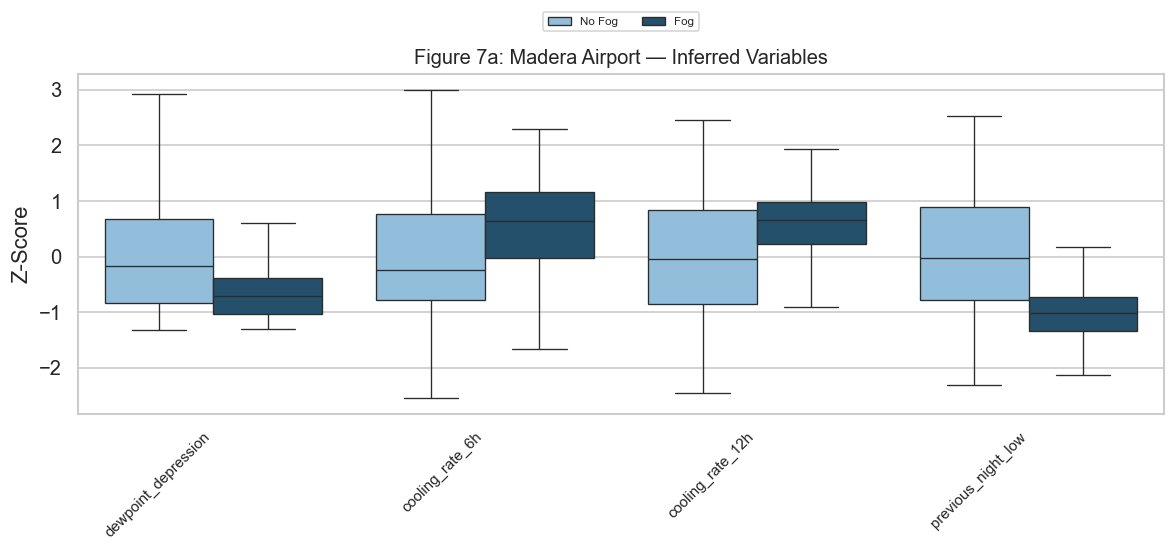

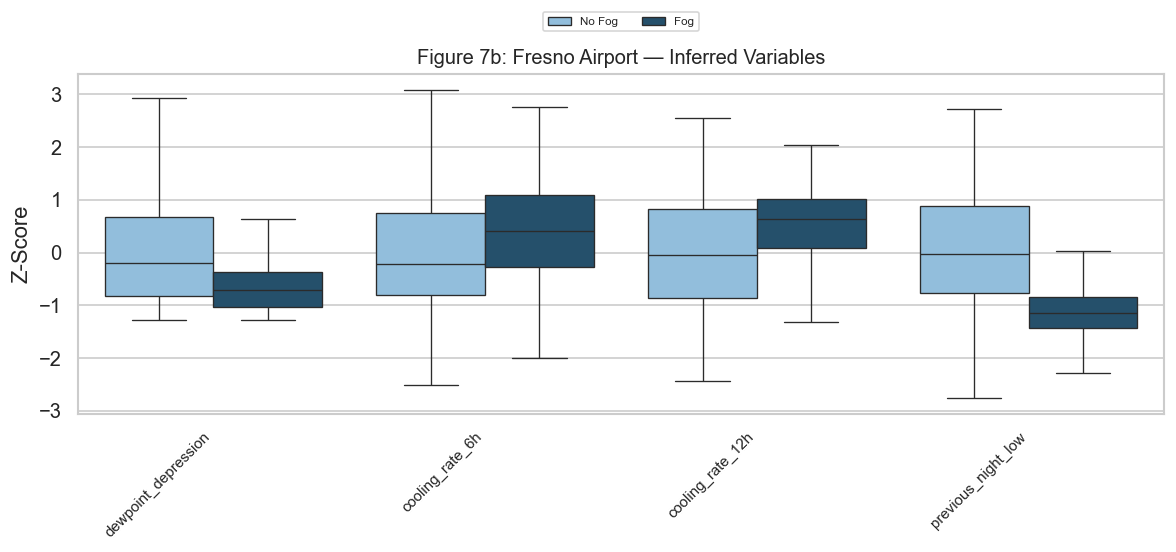

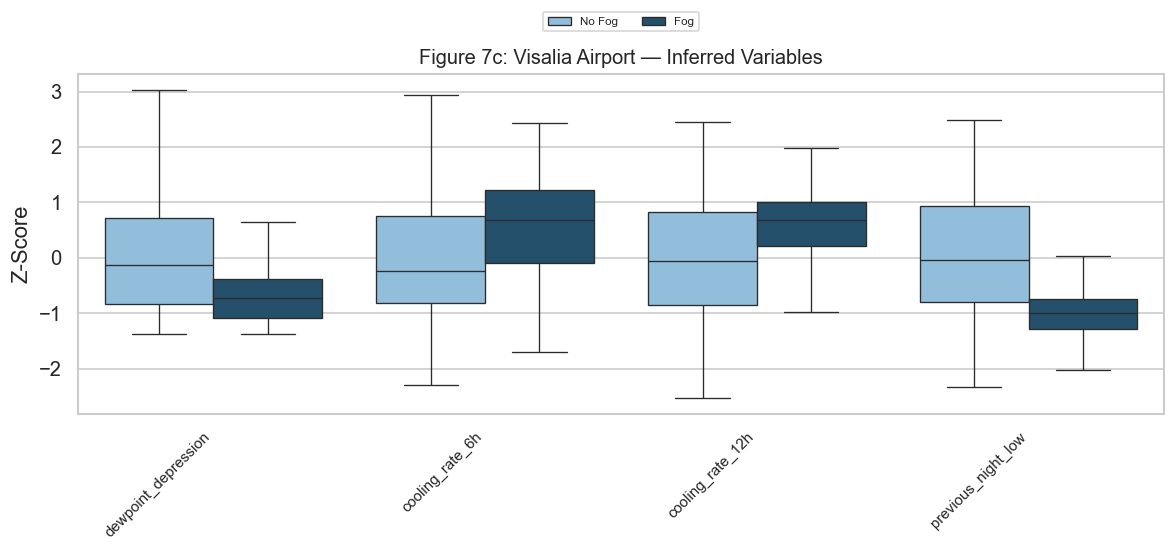

<div style='page-break-after: always;'></div>

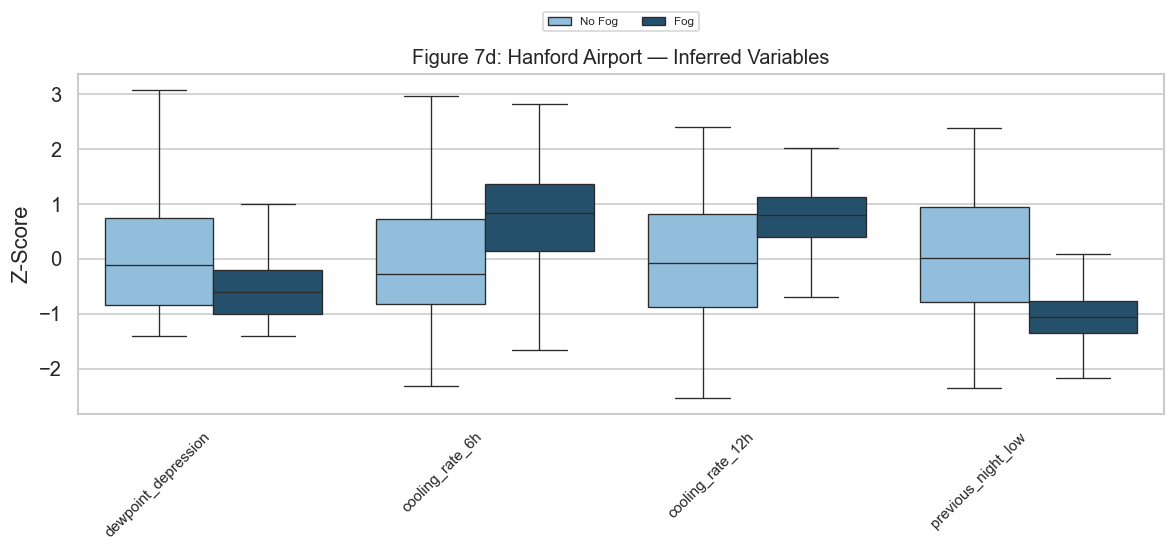

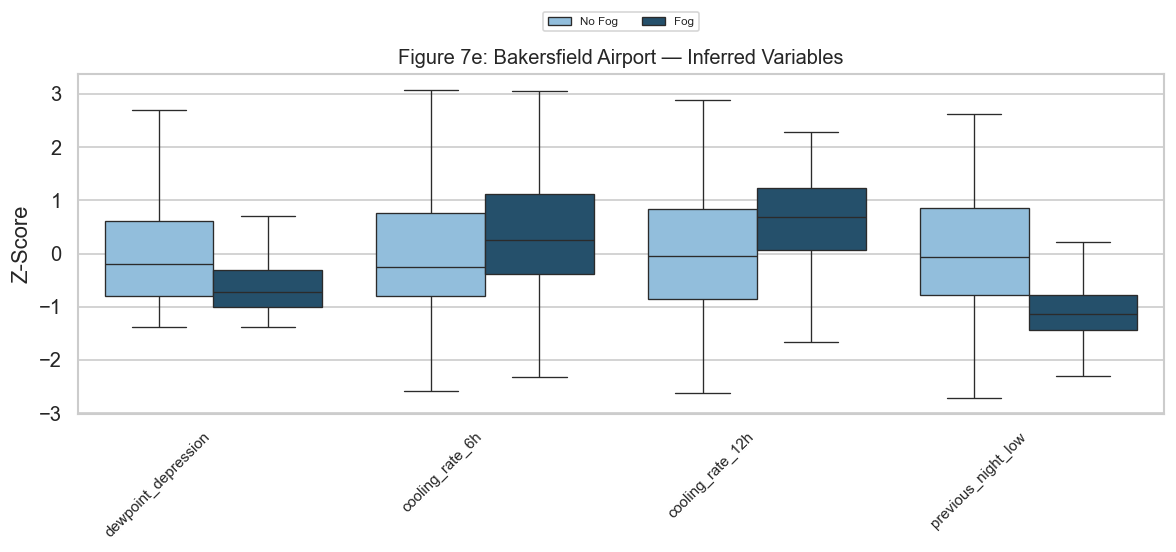

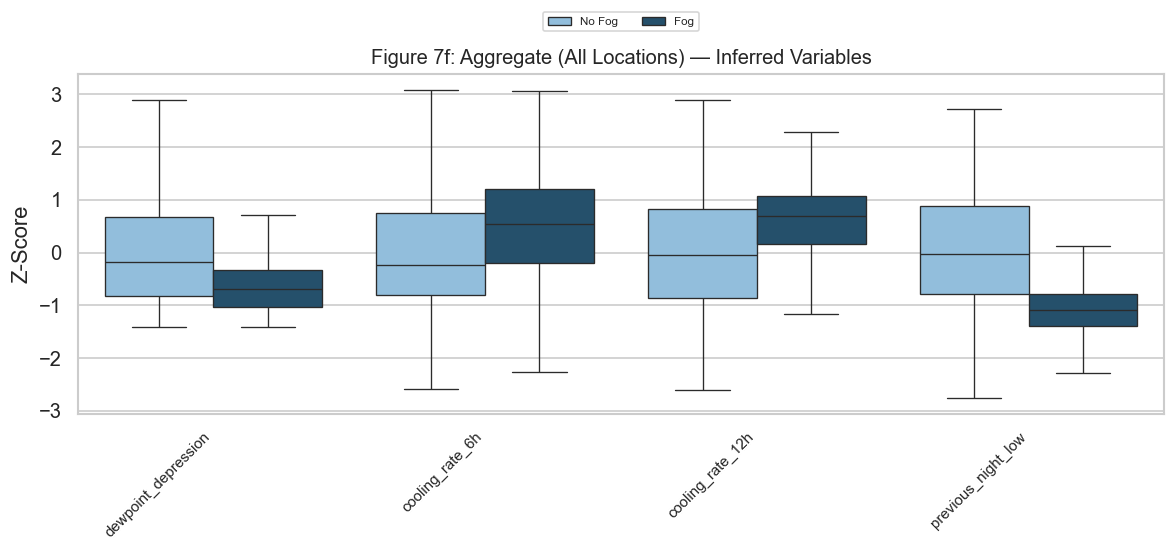

In [11]:
#| echo: false

BLUE_FOG = '#1a5276'
BLUE_NOFOG = '#85c1e9'

def make_inferred_boxplots(data_dict, features, group_label='Inferred Variables'):
    all_dfs = []

    for idx, (loc_num, loc_info) in enumerate(data_dict.items(), start=1):
        df = loc_info['without_aqi'].copy()
        cols = [c for c in features if c in df.columns]
        if not cols:
            continue

        for feat in cols:
            mu, sigma = df[feat].mean(), df[feat].std()
            if sigma > 0:
                df[feat] = (df[feat] - mu) / sigma

        melted = df[cols + ['fog']].melt(
            id_vars='fog', var_name='Feature', value_name='Z-Score'
        )
        melted['Condition'] = melted['fog'].map({0: 'No Fog', 1: 'Fog'})
        all_dfs.append(df[cols + ['fog']])

        fig_height = max(5, 4 + len(cols) * 0.2)
        fig_width = max(10, len(cols) * 0.9)
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))
        sns.boxplot(
            data=melted,
            x='Feature',
            y='Z-Score',
            hue='Condition',
            ax=ax,
            showfliers=False,
            linewidth=0.8,
            palette={'No Fog': BLUE_NOFOG, 'Fog': BLUE_FOG}
        )
        ax.set_title(f"Figure 7{chr(96+idx)}: {loc_info['name']} — {group_label}", fontsize=12)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
        ax.set_xlabel('')
        ax.legend(fontsize=7, loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=2)

        plt.tight_layout()
        plt.show()

        if idx % 3 == 0:
            display(Markdown("<div style='page-break-after: always;'></div>"))

    if all_dfs:
        combined_df = pd.concat(all_dfs, ignore_index=True)
        melted_all = combined_df.melt(
            id_vars='fog', var_name='Feature', value_name='Z-Score'
        )
        melted_all['Condition'] = melted_all['fog'].map({0: 'No Fog', 1: 'Fog'})

        fig_height = max(5, 4 + len(features) * 0.2)
        fig_width = max(10, len(features) * 0.9)
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))
        sns.boxplot(
            data=melted_all,
            x='Feature',
            y='Z-Score',
            hue='Condition',
            ax=ax,
            showfliers=False,
            linewidth=0.8,
            palette={'No Fog': BLUE_NOFOG, 'Fog': BLUE_FOG}
        )
        ax.set_title(f"Figure 7f: Aggregate (All Locations) — {group_label}", fontsize=12)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
        ax.set_xlabel('')
        ax.legend(fontsize=7, loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=2)

        plt.tight_layout()
        plt.show()

make_inferred_boxplots(data, INFERRED_VARS)

The box plot distributions for the inferred variables show good agreement with theoretical expectations for the formation of radiation fog. This proves the effectiveness of the engineered features. As expected, the dewpoint depression for the fog conditions is significantly lower compared to the non-fog conditions for all the locations. Furthermore, the dewpoint depression results show saturated air masses that are favorable for condensation processes. The significant difference between the fog and non-fog conditions for this variable proves the dominance of the predictor for the presence of fog since the basic requirement for the formation of fog is for the relative humidity to approach 100%.

The cooling rate variables also show the expected distributional characteristics, with fog events having more negative values for both 6-hour and 12-hour cooling rates. More negative values in this case reflect efficient nocturnal radiative cooling that acts to decrease the air temperature to a dew point and thereby produce fog under clear-sky and calm conditions. The consistency in the sign of these differences across locations serves to reinforce the physical relevance of cooling rate as a predictor for fog and illustrates the benefits that come from including temporal temperature evolution in the feature set. Similarly, lower values for low temperature from the previous night are observed during fog events due to the fact that fog often lingers from overnight formation into the morning hours and that lower overnight low temperatures are associated with more efficient radiative cooling and greater probability for saturation.

These findings verify the presence of the inferred variables as important mechanistic aspects of the development of radiation fog beyond the information contained in instantaneous weather data. The significant separation observed in the fog and non-fog distributions implies that the engineered features are expected to contribute significantly to the performance of the model and may perform better than the raw weather data in terms of prediction potential, despite being based on the same temperature and humidity data.

## K-Means Sensitivity Analysis

To further evaluate the impact of AQI features on the underlying structure of the data, an unsupervised k-means analysis was conducted with $k = 8$ clusters (optimized $k = n$ via elbow method). This analysis quantifies how the addition or removal of AQI features affects feature importance and dataset homogeneity.

K-means partitions the data into $k$ clusters by minimizing the within-cluster sum of squares (inertia):

$$\text{Inertia} = \sum_{i=1}^{k} \sum_{\mathbf{x} \in C_i} \|\mathbf{x} - \boldsymbol{\mu}_i\|^2$$

where $C_i$ is cluster $i$ and $\boldsymbol{\mu}_i$ is its centroid.

- **Silhouette Score**: Measures how similar an observation is to its own cluster compared to other clusters. Ranges from -1 to 1, with higher values indicating better separation.
- **Davies-Bouldin Index**: Measures average similarity between clusters. Lower values indicate better clustering.

For each dataset variant, **feature variance across clusters** was calculated to identify which variables contribute most to cluster separation. This is calculated as the variance of cluster centroids for each feature, normalized to sum to 100%.

The analysis was performed separately on each location's three dataset variants: Without AQI (full), With AQI (filtered + AQI features), and Without AQI Reduced (filtered, no AQI).

The k-means analysis code can be found in `/eda/k-means clustering` within the codebase.

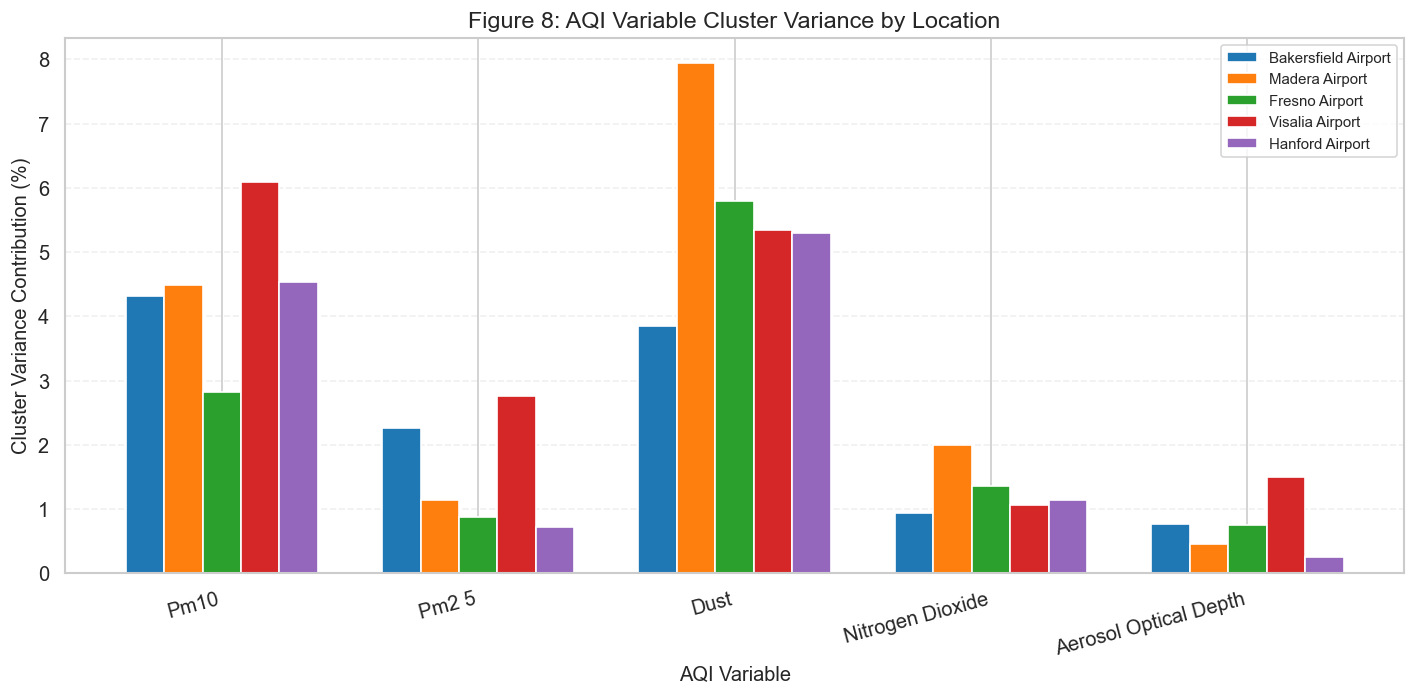

In [12]:
#| echo: false

# kmeans_aqi_sensitivity_analysis.txt

import pandas as pd
import matplotlib.pyplot as plt

KMEANS_LOCATIONS = {
    '6': 'Madera Airport',
    '7': 'Fresno Airport',
    '8': 'Visalia Airport',
    '9': 'Hanford Airport',
    '10': 'Bakersfield Airport'
}

kmeans_location_results = {
    '10': {
        'name': 'Bakersfield Airport',
        'Without AQI': {
            'records': 365120,
            'inertia': 2617205.83,
            'silhouette': 0.2016,
            'davies_bouldin': 1.4035,
            'feature_variance': [
                ('rain', 26.34), ('precipitation', 26.16), ('vapour_pressure_deficit', 4.23),
                ('dewpoint_depression', 3.95), ('wind_speed_100m', 3.88), ('relative_humidity_2m', 3.51),
                ('soil_temperature_0_to_7cm', 3.38), ('wind_speed_10m', 3.38), ('temperature_2m', 3.29),
                ('wind_gusts_10m', 3.23), ('soil_moisture_0_to_7cm', 3.09), ('et0_fao_evapotranspiration', 2.79),
                ('soil_temperature_7_to_28cm', 2.75), ('previous_night_low', 2.28), ('soil_moisture_7_to_28cm', 1.91),
                ('cooling_rate_6h', 1.83), ('cooling_rate_12h', 1.79), ('surface_pressure', 1.39),
                ('dew_point_2m', 0.82)
            ]
        },
        'With AQI': {
            'records': 25691,
            'inertia': 268380.45,
            'silhouette': 0.1826,
            'davies_bouldin': 1.5409,
            'feature_variance': [
                ('rain', 27.58), ('precipitation', 26.96), ('pm10', 4.32), ('dust', 3.85),
                ('soil_moisture_0_to_7cm', 2.84), ('relative_humidity_2m', 2.50), ('wind_speed_10m', 2.29),
                ('soil_temperature_7_to_28cm', 2.29), ('wind_speed_100m', 2.29), ('wind_gusts_10m', 2.29),
                ('pm2_5', 2.27), ('soil_temperature_0_to_7cm', 2.23), ('dewpoint_depression', 2.21),
                ('temperature_2m', 2.20), ('previous_night_low', 2.11), ('vapour_pressure_deficit', 2.05),
                ('et0_fao_evapotranspiration', 1.80), ('cooling_rate_6h', 1.59), ('soil_moisture_7_to_28cm', 1.46),
                ('surface_pressure', 1.38), ('cooling_rate_12h', 1.29), ('nitrogen_dioxide', 0.94),
                ('aerosol_optical_depth', 0.77), ('dew_point_2m', 0.48)
            ]
        },
        'Without AQI Reduced': {
            'records': 25691,
            'inertia': 166323.66,
            'silhouette': 0.2233,
            'davies_bouldin': 1.3952,
            'feature_variance': [
                ('rain', 30.67), ('precipitation', 30.07), ('soil_moisture_0_to_7cm', 2.93),
                ('relative_humidity_2m', 2.87), ('wind_speed_100m', 2.86), ('dewpoint_depression', 2.84),
                ('soil_temperature_0_to_7cm', 2.81), ('vapour_pressure_deficit', 2.75), ('wind_speed_10m', 2.75),
                ('temperature_2m', 2.71), ('wind_gusts_10m', 2.54), ('soil_temperature_7_to_28cm', 2.43),
                ('et0_fao_evapotranspiration', 2.41), ('previous_night_low', 2.17), ('cooling_rate_6h', 1.89),
                ('soil_moisture_7_to_28cm', 1.62), ('cooling_rate_12h', 1.61), ('surface_pressure', 1.50),
                ('dew_point_2m', 0.57)
            ]
        }
    },
    '6': {
        'name': 'Madera Airport',
        'Without AQI': {
            'records': 164421,
            'inertia': 1063459.57,
            'silhouette': 0.2088,
            'davies_bouldin': 1.3889,
            'feature_variance': [
                ('rain', 25.95), ('precipitation', 25.94), ('soil_moisture_0_to_7cm', 4.35),
                ('relative_humidity_2m', 3.49), ('soil_temperature_0_to_7cm', 3.31), ('soil_temperature_7_to_28cm', 3.30),
                ('dewpoint_depression', 3.26), ('soil_moisture_7_to_28cm', 3.24), ('temperature_2m', 3.15),
                ('vapour_pressure_deficit', 3.11), ('wind_speed_100m', 3.02), ('et0_fao_evapotranspiration', 2.80),
                ('wind_speed_10m', 2.75), ('wind_gusts_10m', 2.73), ('previous_night_low', 2.65),
                ('cooling_rate_6h', 2.32), ('cooling_rate_12h', 2.07), ('surface_pressure', 1.84),
                ('dew_point_2m', 0.73)
            ]
        },
        'With AQI': {
            'records': 25558,
            'inertia': 262365.04,
            'silhouette': 0.2087,
            'davies_bouldin': 1.4584,
            'feature_variance': [
                ('rain', 23.10), ('precipitation', 23.01), ('dust', 7.94), ('pm10', 4.48),
                ('soil_moisture_0_to_7cm', 3.41), ('relative_humidity_2m', 2.63), ('wind_gusts_10m', 2.62),
                ('wind_speed_100m', 2.61), ('wind_speed_10m', 2.57), ('soil_temperature_0_to_7cm', 2.54),
                ('temperature_2m', 2.47), ('dewpoint_depression', 2.43), ('soil_temperature_7_to_28cm', 2.42),
                ('vapour_pressure_deficit', 2.31), ('et0_fao_evapotranspiration', 2.21), ('soil_moisture_7_to_28cm', 2.05),
                ('previous_night_low', 2.04), ('nitrogen_dioxide', 2.00), ('cooling_rate_6h', 1.76),
                ('cooling_rate_12h', 1.56), ('surface_pressure', 1.56), ('pm2_5', 1.14),
                ('dew_point_2m', 0.68), ('aerosol_optical_depth', 0.46)
            ]
        },
        'Without AQI Reduced': {
            'records': 25558,
            'inertia': 164047.65,
            'silhouette': 0.2087,
            'davies_bouldin': 1.3686,
            'feature_variance': [
                ('rain', 26.36), ('precipitation', 26.27), ('soil_moisture_0_to_7cm', 4.18),
                ('relative_humidity_2m', 3.38), ('soil_temperature_7_to_28cm', 3.31), ('soil_temperature_0_to_7cm', 3.30),
                ('soil_moisture_7_to_28cm', 3.28), ('dewpoint_depression', 3.20), ('temperature_2m', 3.13),
                ('vapour_pressure_deficit', 2.99), ('et0_fao_evapotranspiration', 2.83), ('wind_speed_100m', 2.78),
                ('previous_night_low', 2.70), ('wind_gusts_10m', 2.67), ('wind_speed_10m', 2.63),
                ('cooling_rate_6h', 2.36), ('cooling_rate_12h', 1.93), ('surface_pressure', 1.83),
                ('dew_point_2m', 0.87)
            ]
        }
    },
    '7': {
        'name': 'Fresno Airport',
        'Without AQI': {
            'records': 392427,
            'inertia': 2526989.85,
            'silhouette': 0.2119,
            'davies_bouldin': 1.3617,
            'feature_variance': [
                ('precipitation', 23.50), ('rain', 23.49), ('soil_moisture_0_to_7cm', 4.72),
                ('relative_humidity_2m', 3.88), ('soil_temperature_7_to_28cm', 3.64), ('soil_temperature_0_to_7cm', 3.56),
                ('soil_moisture_7_to_28cm', 3.56), ('dewpoint_depression', 3.51), ('wind_speed_100m', 3.44),
                ('temperature_2m', 3.40), ('vapour_pressure_deficit', 3.32), ('wind_gusts_10m', 3.12),
                ('wind_speed_10m', 3.08), ('et0_fao_evapotranspiration', 3.02), ('previous_night_low', 2.93),
                ('cooling_rate_6h', 2.62), ('cooling_rate_12h', 2.28), ('surface_pressure', 1.89),
                ('dew_point_2m', 1.04)
            ]
        },
        'With AQI': {
            'records': 25748,
            'inertia': 259556.46,
            'silhouette': 0.1905,
            'davies_bouldin': 1.4757,
            'feature_variance': [
                ('precipitation', 25.13), ('rain', 25.09), ('dust', 5.79), ('soil_moisture_0_to_7cm', 3.67),
                ('soil_temperature_7_to_28cm', 2.84), ('pm10', 2.83), ('relative_humidity_2m', 2.70),
                ('soil_temperature_0_to_7cm', 2.63), ('dewpoint_depression', 2.44), ('temperature_2m', 2.43),
                ('soil_moisture_7_to_28cm', 2.39), ('wind_speed_100m', 2.32), ('previous_night_low', 2.30),
                ('vapour_pressure_deficit', 2.28), ('et0_fao_evapotranspiration', 2.24), ('cooling_rate_6h', 2.10),
                ('wind_gusts_10m', 1.94), ('wind_speed_10m', 1.93), ('cooling_rate_12h', 1.67),
                ('surface_pressure', 1.52), ('nitrogen_dioxide', 1.36), ('pm2_5', 0.88),
                ('dew_point_2m', 0.77), ('aerosol_optical_depth', 0.75)
            ]
        },
        'Without AQI Reduced': {
            'records': 25748,
            'inertia': 159702.68,
            'silhouette': 0.2038,
            'davies_bouldin': 1.3619,
            'feature_variance': [
                ('precipitation', 27.12), ('rain', 27.09), ('soil_moisture_0_to_7cm', 3.98),
                ('relative_humidity_2m', 3.21), ('soil_temperature_7_to_28cm', 3.14), ('soil_temperature_0_to_7cm', 3.11),
                ('wind_speed_100m', 3.04), ('temperature_2m', 2.97), ('dewpoint_depression', 2.97),
                ('soil_moisture_7_to_28cm', 2.88), ('vapour_pressure_deficit', 2.78), ('wind_speed_10m', 2.72),
                ('et0_fao_evapotranspiration', 2.71), ('wind_gusts_10m', 2.69), ('previous_night_low', 2.62),
                ('cooling_rate_6h', 2.35), ('cooling_rate_12h', 1.91), ('surface_pressure', 1.75),
                ('dew_point_2m', 0.95)
            ]
        }
    },
    '8': {
        'name': 'Visalia Airport',
        'Without AQI': {
            'records': 166085,
            'inertia': 1107510.98,
            'silhouette': 0.2018,
            'davies_bouldin': 1.3904,
            'feature_variance': [
                ('rain', 27.32), ('precipitation', 27.24), ('soil_moisture_0_to_7cm', 4.13),
                ('relative_humidity_2m', 3.54), ('dewpoint_depression', 3.17), ('soil_temperature_7_to_28cm', 3.08),
                ('soil_temperature_0_to_7cm', 3.04), ('vapour_pressure_deficit', 3.00), ('temperature_2m', 2.98),
                ('soil_moisture_7_to_28cm', 2.89), ('wind_speed_100m', 2.79), ('previous_night_low', 2.61),
                ('wind_speed_10m', 2.56), ('wind_gusts_10m', 2.55), ('et0_fao_evapotranspiration', 2.54),
                ('cooling_rate_6h', 2.31), ('cooling_rate_12h', 1.81), ('surface_pressure', 1.70),
                ('dew_point_2m', 0.73)
            ]
        },
        'With AQI': {
            'records': 25587,
            'inertia': 263735.98,
            'silhouette': 0.1897,
            'davies_bouldin': 1.4858,
            'feature_variance': [
                ('rain', 25.15), ('precipitation', 25.10), ('pm10', 6.09), ('dust', 5.35),
                ('soil_moisture_0_to_7cm', 3.10), ('pm2_5', 2.76), ('soil_temperature_7_to_28cm', 2.59),
                ('relative_humidity_2m', 2.56), ('soil_temperature_0_to_7cm', 2.29), ('dewpoint_depression', 2.25),
                ('temperature_2m', 2.12), ('previous_night_low', 2.12), ('vapour_pressure_deficit', 2.02),
                ('cooling_rate_6h', 1.93), ('et0_fao_evapotranspiration', 1.91), ('wind_speed_100m', 1.86),
                ('soil_moisture_7_to_28cm', 1.80), ('cooling_rate_12h', 1.53), ('wind_gusts_10m', 1.51),
                ('aerosol_optical_depth', 1.50), ('wind_speed_10m', 1.46), ('surface_pressure', 1.27),
                ('nitrogen_dioxide', 1.06), ('dew_point_2m', 0.66)
            ]
        },
        'Without AQI Reduced': {
            'records': 25587,
            'inertia': 162539.09,
            'silhouette': 0.2042,
            'davies_bouldin': 1.3461,
            'feature_variance': [
                ('rain', 28.87), ('precipitation', 28.81), ('soil_moisture_0_to_7cm', 3.74),
                ('relative_humidity_2m', 3.20), ('dewpoint_depression', 2.98), ('soil_temperature_0_to_7cm', 2.90),
                ('soil_temperature_7_to_28cm', 2.90), ('temperature_2m', 2.83), ('vapour_pressure_deficit', 2.77),
                ('soil_moisture_7_to_28cm', 2.59), ('et0_fao_evapotranspiration', 2.58), ('previous_night_low', 2.49),
                ('wind_speed_100m', 2.49), ('wind_gusts_10m', 2.25), ('cooling_rate_6h', 2.24),
                ('wind_speed_10m', 2.08), ('cooling_rate_12h', 1.72), ('surface_pressure', 1.59),
                ('dew_point_2m', 0.96)
            ]
        }
    },
    '9': {
        'name': 'Hanford Airport',
        'Without AQI': {
            'records': 164009,
            'inertia': 1087580.17,
            'silhouette': 0.2049,
            'davies_bouldin': 1.3703,
            'feature_variance': [
                ('rain', 29.26), ('precipitation', 29.26), ('soil_moisture_0_to_7cm', 3.66),
                ('relative_humidity_2m', 3.16), ('soil_temperature_7_to_28cm', 2.83), ('dewpoint_depression', 2.81),
                ('soil_temperature_0_to_7cm', 2.75), ('temperature_2m', 2.68), ('vapour_pressure_deficit', 2.65),
                ('soil_moisture_7_to_28cm', 2.59), ('wind_gusts_10m', 2.57), ('wind_speed_100m', 2.56),
                ('wind_speed_10m', 2.50), ('previous_night_low', 2.39), ('et0_fao_evapotranspiration', 2.28),
                ('cooling_rate_6h', 2.07), ('cooling_rate_12h', 1.67), ('surface_pressure', 1.61),
                ('dew_point_2m', 0.71)
            ]
        },
        'With AQI': {
            'records': 25677,
            'inertia': 260666.12,
            'silhouette': 0.1837,
            'davies_bouldin': 1.5671,
            'feature_variance': [
                ('precipitation', 26.86), ('rain', 26.86), ('dust', 5.30), ('pm10', 4.53),
                ('soil_moisture_0_to_7cm', 3.48), ('relative_humidity_2m', 2.71), ('soil_temperature_7_to_28cm', 2.61),
                ('soil_temperature_0_to_7cm', 2.38), ('dewpoint_depression', 2.36), ('temperature_2m', 2.22),
                ('previous_night_low', 2.20), ('soil_moisture_7_to_28cm', 2.11), ('vapour_pressure_deficit', 2.05),
                ('cooling_rate_6h', 2.03), ('et0_fao_evapotranspiration', 1.96), ('wind_speed_100m', 1.71),
                ('cooling_rate_12h', 1.49), ('wind_gusts_10m', 1.46), ('surface_pressure', 1.42),
                ('wind_speed_10m', 1.32), ('nitrogen_dioxide', 1.15), ('dew_point_2m', 0.79),
                ('pm2_5', 0.73), ('aerosol_optical_depth', 0.26)
            ]
        },
        'Without AQI Reduced': {
            'records': 25677,
            'inertia': 163830.21,
            'silhouette': 0.2150,
            'davies_bouldin': 1.3551,
            'feature_variance': [
                ('precipitation', 29.96), ('rain', 29.96), ('soil_moisture_0_to_7cm', 3.56),
                ('relative_humidity_2m', 2.97), ('soil_temperature_7_to_28cm', 2.77), ('dewpoint_depression', 2.71),
                ('soil_temperature_0_to_7cm', 2.71), ('temperature_2m', 2.59), ('soil_moisture_7_to_28cm', 2.50),
                ('vapour_pressure_deficit', 2.46), ('wind_speed_100m', 2.46), ('previous_night_low', 2.35),
                ('wind_gusts_10m', 2.33), ('et0_fao_evapotranspiration', 2.27), ('wind_speed_10m', 2.25),
                ('cooling_rate_6h', 2.06), ('cooling_rate_12h', 1.63), ('surface_pressure', 1.53),
                ('dew_point_2m', 0.94)
            ]
        }
    }
}

AQI_VARIABLES = ['pm10', 'pm2_5', 'dust', 'nitrogen_dioxide', 'aerosol_optical_depth']
aqi_variance_data = []
for loc_key, loc_data in kmeans_location_results.items():
    loc_name = loc_data['name']
    with_aqi_features = dict(loc_data['With AQI']['feature_variance'])
    
    for aqi_var in AQI_VARIABLES:
        if aqi_var in with_aqi_features:
            aqi_variance_data.append({
                'Location': loc_name,
                'Variable': aqi_var.replace('_', ' ').title(),
                'Variance (%)': with_aqi_features[aqi_var]
            })

aqi_variance_df = pd.DataFrame(aqi_variance_data)
fig, ax = plt.subplots(figsize=(12, 6))
locations = aqi_variance_df['Location'].unique()
variables = aqi_variance_df['Variable'].unique()
x = range(len(variables))
width = 0.15
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, location in enumerate(locations):
    loc_data = aqi_variance_df[aqi_variance_df['Location'] == location]
    values = [loc_data[loc_data['Variable'] == var]['Variance (%)'].values[0] 
              if len(loc_data[loc_data['Variable'] == var]) > 0 else 0 
              for var in variables]
    ax.bar([pos + width * i for pos in x], values, width, label=location, color=colors[i])

ax.set_xlabel('AQI Variable', fontsize=12)
ax.set_ylabel('Cluster Variance Contribution (%)', fontsize=12)
ax.set_title('Figure 8: AQI Variable Cluster Variance by Location', fontsize=14)
ax.set_xticks([pos + width * 2 for pos in x])
ax.set_xticklabels(variables, rotation=15, ha='right')
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

Dust and PM10 are clearly the dominant factors in contributing to the variance in the clusters, with the majority of the contributions coming from these factors on average across the sites. However, the contribution of these factors is quite variable across the sites. For Madera, Fresno, Visalia, and Hanford, the contribution of dust is relatively high, ranging from 5-8%. In contrast, the contribution of PM10 is the highest in Bakersfield, with a value of 4.3%, while the contribution of dust is relatively low in this location.

On the other hand, PM2.5, nitrogen dioxide, and aerosol optical depth contribute much less to cluster variance across all locations, ranging between 1-3% or lower. These lower variance contributions of finer particulate matter and gaseous air pollutants indicate that, even though these air pollutants have stronger correlations with visibility, as found in previous analyses, these air pollutants do not help define distinct boundaries between clusters, which is a result of the k-means clustering process. This difference between stronger correlations with visibility and lower contributions to defining cluster boundaries between air quality states indicates that PM2.5 and nitrogen dioxide vary continuously rather than showing sharp distinctions between air quality states. The low contribution to cluster variance of aerosol optical depth across all locations further supports that this column-integrated aerosol property is not helpful in distinguishing fog-related air quality states from all other air quality states included in the 2022-present AQI dataset.

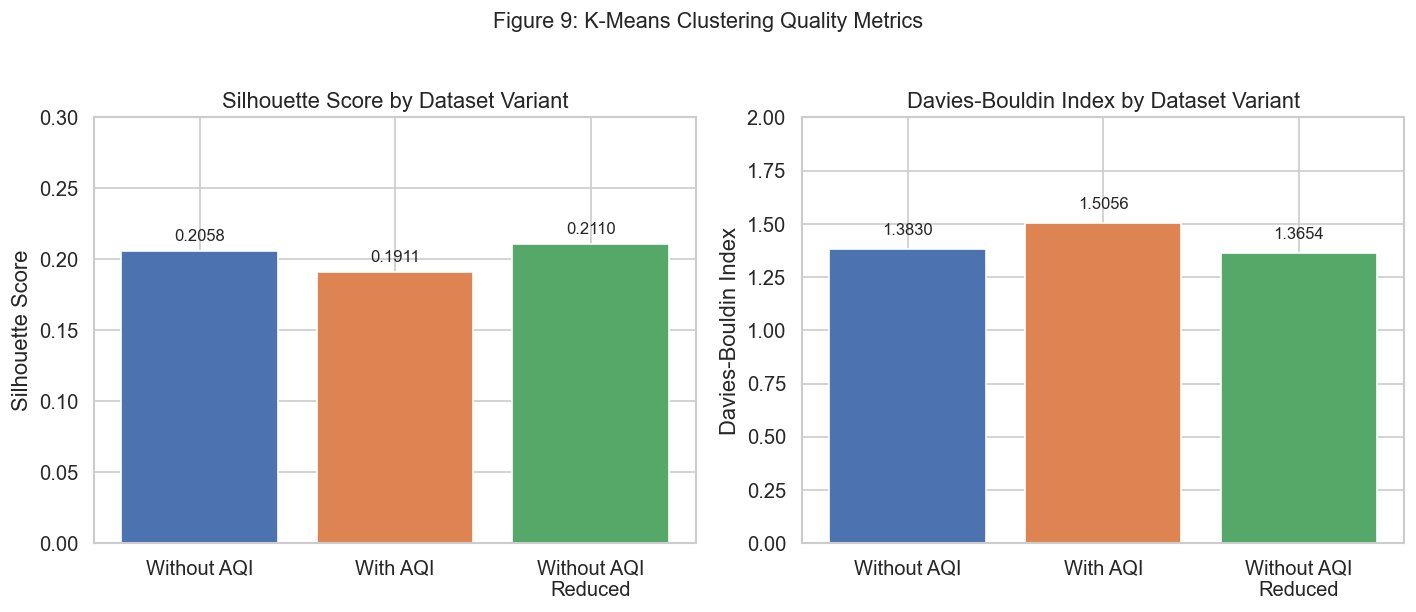

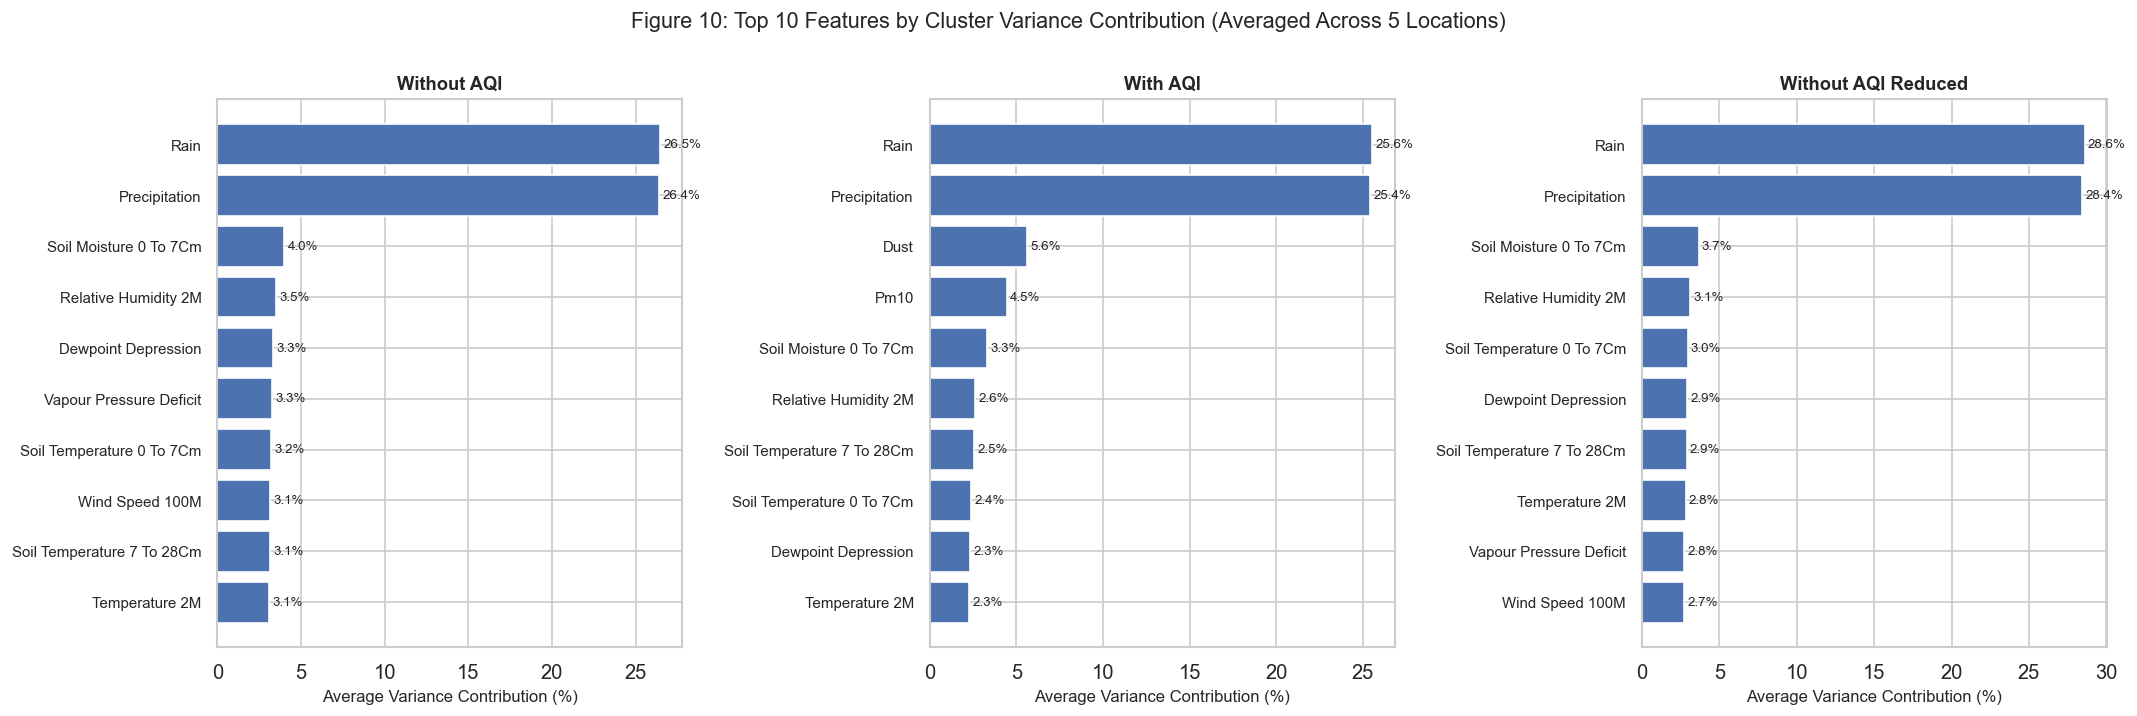

In [13]:
#| echo: false

import matplotlib.pyplot as plt
import numpy as np


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
variants = ['Without AQI', 'With AQI', 'Without AQI\nReduced']
silhouette_scores = [0.2058, 0.1911, 0.2110]
davies_bouldin_scores = [1.3830, 1.5056, 1.3654]
bars1 = ax1.bar(variants, silhouette_scores, color=['#4c72b0', '#dd8452', '#55a868'])
ax1.set_ylabel('Silhouette Score')
ax1.set_title('Silhouette Score by Dataset Variant')
ax1.set_ylim(0, 0.3)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.4f}', ha='center', va='bottom', fontsize=10)

bars2 = ax2.bar(variants, davies_bouldin_scores, color=['#4c72b0', '#dd8452', '#55a868'])
ax2.set_ylabel('Davies-Bouldin Index')
ax2.set_title('Davies-Bouldin Index by Dataset Variant')
ax2.set_ylim(0, 2.0)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.05,
             f'{height:.4f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Figure 9: K-Means Clustering Quality Metrics', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

def compute_all_feature_averages(variant_key):
    feature_sums = {}
    feature_counts = {}
    
    for loc_data in kmeans_location_results.values():
        for feature_name, variance in loc_data[variant_key]['feature_variance']:
            if feature_name not in feature_sums:
                feature_sums[feature_name] = 0
                feature_counts[feature_name] = 0
            feature_sums[feature_name] += variance
            feature_counts[feature_name] += 1
    
    avg_features = [(name, feature_sums[name] / feature_counts[name]) 
                    for name in feature_sums]
    avg_features.sort(key=lambda x: x[1], reverse=True)
    return avg_features

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
variant_keys = ['Without AQI', 'With AQI', 'Without AQI Reduced']
variant_names = ['Without AQI', 'With AQI', 'Without AQI Reduced']
for idx, (variant_key, variant_name) in enumerate(zip(variant_keys, variant_names)):
    ax = axes[idx]
    all_features = compute_all_feature_averages(variant_key)[:10]
    
    features = [f[0].replace('_', ' ').title() for f in all_features]
    variances = [f[1] for f in all_features]
    
    bars = ax.barh(features, variances, color='#4c72b0')
    ax.set_xlabel('Average Variance Contribution (%)', fontsize=10)
    ax.set_title(variant_name, fontsize=11, fontweight='bold')
    ax.invert_yaxis()
    ax.tick_params(axis='y', labelsize=9)
    
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.2, bar.get_y() + bar.get_height()/2.,
                f'{width:.1f}%', ha='left', va='center', fontsize=8)

plt.suptitle('Figure 10: Top 10 Features by Cluster Variance Contribution (Averaged Across 5 Locations)', 
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

The clustering quality metrics show that there is a general trend across variants in which the addition of AQI features negatively impacted the quality of unsupervised clustering. The **With AQI** variant has the lowest Silhouette Score at 0.1911 and highest Davies-Bouldin Index at 1.5056, which suggests that this variant has clusters that are less distinct internally and more prone to overlap with neighboring clusters compared to other variants. On the other hand, the **Without AQI Reduced** variant shows a better clustering quality with a Silhouette Score of 0.2110 and Davies-Bouldin Index of 1.3654. This analysis specifically targets the effect of AQI features by comparing variants and demonstrates that AQI features indeed contribute noise and not meaningful clustering in the atmospheric state space. However, it must be noted that the **Without AQI** variant with 15-20 times more data points and covering 45 years still manages to have a clustering quality that is in between and competitive with the **Without AQI Reduced** variant in terms of Silhouette Scores and Davies-Bouldin Indices, with a Silhouette Score of 0.2058 and Davies-Bouldin Index of 1.3830.

The feature variance contributions also highlight the dominance of precipitation-related features in defining cluster boundaries. Across all three variants of the datasets, rain and precipitation combined account for 50-60% of total cluster variance, with individual features contributing 25-30%. This is due to the binary nature of rain and precipitation in the semi-arid environment of the San Joaquin Valley. Hours with rain or precipitation have categorically different clusters compared to the vast majority of hours without rain or precipitation, even as temperature, humidity, pressure, or air quality may vary. The discrete nature of rainfall leads to natural cluster separations that dwarf the differences in other meteorological features. The k-means algorithm is thus seen to partition the data along the rain/precipitation axis, with a secondary partitioning based on soil moisture and humidity conditions.

In the presence of features in AQI, dust and PM10 emerge as the third and fourth most important features in the **With AQI** variant. They contribute 5.65% and 4.45% to the total variance in the data. This is much higher than the importance of weather-related features such as temperature, wind speed, and surface pressure. This indicates that dust and PM10 are important features in the data. Although dust and PM10 are individually important features in the data, the overall quality of clustering is reduced in the presence of features in AQI. This indicates that dust and PM10 define the axes orthogonal to the weather-related structure in the data relevant for fog classification. This is consistent with the previous analysis that suggested that features in AQI have low predictive power for the classification task. This is because features in AQI contribute to the overall structure in the data but not to the structure relevant for the classification task.

# Methods and Results

This section describes each classification model used to predict fog events and reports comparative performance across dataset variants and locations. All models were evaluated using a **temporal train/test split**: data from **1980–2023 + 2025** for training and **2024** for testing. The year 2024 was selected as the test set to maintain consistency across all models and establish a fair baseline for comparison. Given that the AQI-enhanced dataset spans only **2022–2025**, and within this window **only 2023 and 2024 represent complete calendar years**, using 2024 as the held-out test year ensures that model evaluation captures the full range of seasonal fog patterns and avoids biases introduced by partial-year data.

Three dataset configurations were tested for each model:

| Variant | Rows | Features | Description |
|---------|------|----------|-------------|
| **Without AQI** | ≈ 168-400k | 20 weather | Full 45-year record, no air quality columns |
| **With AQI** | ≈ 27k | 25 (weather + AQI) | Restricted to rows with valid AQI data (Aug 2022+) |
| **Without AQI Reduced** | ≈ 27k | 20 weather | Same rows as With AQI, but AQI columns removed (control) |

Fog: $< 1{,}610$ m (1 mile)

No Fog: Otherwise

Performance metrics reported are **accuracy**, **precision**, **recall**, **F1-score**, and **ROC-AUC**, averaged across five locations.

**All models and results can be found and re-used within `/models` in the codebase.**

**Appendixes B - G contain raw results, per location, for all model outputs.**

In [14]:
#| echo: false

results = {
    'Logistic Regression': {
        'Without AQI':         {'Accuracy': 0.7759, 'Precision': 0.1004, 'Recall': 0.9491, 'F1': 0.1793, 'AUC': 0.9395},
        'With AQI':            {'Accuracy': 0.8936, 'Precision': 0.1567, 'Recall': 0.7071, 'F1': 0.2539, 'AUC': 0.9158},
        'Without AQI Reduced': {'Accuracy': 0.8871, 'Precision': 0.1592, 'Recall': 0.7806, 'F1': 0.2605, 'AUC': 0.9280},
    },
    'Random Forest': {
        'Without AQI':         {'Accuracy': 0.8328, 'Precision': 0.1268, 'Recall': 0.9213, 'F1': 0.2201, 'AUC': 0.9388},
        'With AQI':            {'Accuracy': 0.9620, 'Precision': 0.2348, 'Recall': 0.2578, 'F1': 0.2317, 'AUC': 0.9040},
        'Without AQI Reduced': {'Accuracy': 0.9608, 'Precision': 0.2390, 'Recall': 0.2878, 'F1': 0.2511, 'AUC': 0.9042},
    },
    'XGBoost': {
        'Without AQI':         {'Accuracy': 0.9610, 'Precision': 0.2807, 'Recall': 0.3572, 'F1': 0.3120, 'AUC': 0.9163},
        'With AQI':            {'Accuracy': 0.9660, 'Precision': 0.2465, 'Recall': 0.1895, 'F1': 0.2091, 'AUC': 0.8950},
        'Without AQI Reduced': {'Accuracy': 0.9647, 'Precision': 0.2707, 'Recall': 0.2152, 'F1': 0.2321, 'AUC': 0.9023},
    },
    'Temporal CNN': {
        'Without AQI':         {'Accuracy': 0.8235, 'Precision': 0.1261, 'Recall': 0.9722, 'F1': 0.2201, 'AUC': 0.9567},
        'With AQI':            {'Accuracy': 0.8899, 'Precision': 0.1629, 'Recall': 0.8039, 'F1': 0.2697, 'AUC': 0.9330},
        'Without AQI Reduced': {'Accuracy': 0.9087, 'Precision': 0.1878, 'Recall': 0.7248, 'F1': 0.2894, 'AUC': 0.9225},
    },
    'Stacking Ensemble': {
        'Without AQI':         {'Accuracy': 0.9488, 'Precision': 0.2668, 'Recall': 0.6104, 'F1': 0.3706, 'AUC': 0.9515},
        'With AQI':            {'Accuracy': 0.9627, 'Precision': 0.2499, 'Recall': 0.3222, 'F1': 0.2742, 'AUC': 0.9273},
        'Without AQI Reduced': {'Accuracy': 0.9627, 'Precision': 0.3477, 'Recall': 0.3873, 'F1': 0.3218, 'AUC': 0.9370},
    },
}

rows = []
for model, variants in results.items():
    for variant, metrics in variants.items():
        for metric, value in metrics.items():
            rows.append({'Model': model, 'Variant': variant, 'Metric': metric, 'Value': value})
results_df = pd.DataFrame(rows)

## Logistic Regression

Logistic Regression models the probability of fog as a sigmoid function of a linear combination of input features. Given feature vector $\mathbf{x} \in \mathbb{R}^d$ with learned weights $\mathbf{w}$ and bias $b$:

$$P(y = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}$$

The model minimizes the regularized binary cross-entropy loss:

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right] + \frac{1}{2C} \|\mathbf{w}\|_2^2$$

where $C$ is the inverse regularization strength. Features are standardized via `StandardScaler` and the `class_weight='balanced'` parameter adjusts the loss to up-weight the minority (fog) class proportionally. The solver used is L-BFGS with a maximum of 1,000 iterations.

Logistic regression serves as the baseline model for this study due to its simplicity. Its strength lies in its ability to provide linear decision boundaries that are easy to interpret, becase each feature's coefficient directly represents its contribution to the log-odds of fog occurrence.

However, there are considerable limitations to using logistic regression, especially with complex weather phenomena such as fog formation. To start with, logistic regression is a linear method that is not well suited to handle non-linear relationships between variables, such as the combined effects of humidity and temperature, or threshold effects, such as fog formation depending on whether the depression is above or below a certain critical value. Since fog is known to form through complex non-linear processes, such as temperature inversion, radiative cooling, and convergence of moisture, logistic regression may not effectively identify the complex, high-dimensional patterns that distinguish fog from near-fog situations. Also, there is considerable multicollinearity between weather variables such as temperature and dewpoint, which may affect the performance of logistic regression, especially if there is class imbalance, despite class weights.

Given these characteristics, it was expected that the logistic regression algorithm would have low performance success in the task of predicting fog. It was expected that the algorithm would be successful in identifying broad trends, such as the strong negative relationship between visibility and high relative humidity/precipitation, although it was expected that the algorithm would perform reasonably well in clear-cut cases in which the atmospheric conditions are clearly favorable or unfavorable for the occurrence of fog. However, it was expected that the algorithm would have lower recall compared to precision, as the algorithm would be unable to detect the occurrence of fog in nonlinear meteorological conditions.

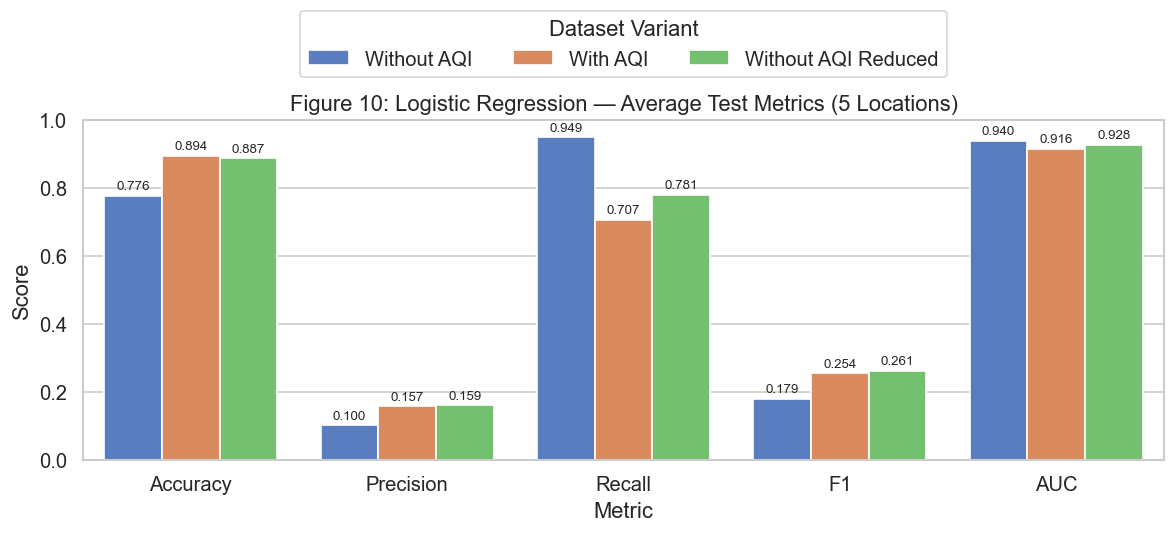

In [15]:
#| echo: false

lr = results_df[results_df['Model'] == 'Logistic Regression']
metrics_order = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
lr = lr[lr['Metric'].isin(metrics_order)]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=lr, x='Metric', y='Value', hue='Variant', order=metrics_order, ax=ax)
ax.set_ylim(0, 1)
ax.set_title('Figure 10: Logistic Regression — Average Test Metrics (5 Locations)')
ax.set_ylabel('Score')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
ax.legend(title='Dataset Variant', loc='upper center', bbox_to_anchor=(0.5, 1.35), ncol=3)
plt.tight_layout()
plt.show()

 The logistic regression results reveal performance patterns that directly reflect the model's fundamental limitations when applied to fog prediction. Across all three dataset variants, the model exhibits severely imbalanced precision-recall tradeoffs: precision ranges from just 10.04% to 15.92%, while recall reaches 70.71% to 94.91%. This disparity indicates that the linear decision boundary is unable to tightly delineate the complex, high-dimensional region where fog conditions occur. Instead, the model compensates by casting an excessively wide net and classifying many non-fog hours as fog in order to capture most actual fog events. The **Without AQI** variant demonstrates this effect most dramatically, achieving 94.91% recall at the cost of 10.04% precision, meaning that for every correct fog prediction, approximately nine false alarms are generated.

This poor precision-recall balance arises from logistic regression's inability to model the nonlinear interactions and threshold effects that govern radiation fog formation. The linear model cannot effectively distinguish between marginal conditions (e.g., high humidity but insufficient cooling) and true fog-forming scenarios without creating a decision boundary so conservative that it misses many fog events. The class imbalance problem exacerbates this issue, as even with balanced class weights, the model's linear structure limits its capacity to define a narrow, precise boundary around the minority class. Consequently, the model sacrifices specificity to maintain sensitivity, resulting in F1-scores below 0.27 across all variants despite strong AUC values (0.92–0.94) indicating reasonable rank-ordering ability.

The inclusion of AQI features produces marginal improvements in precision (+5.6%) and F1-score (+7.5) compared to the **Without AQI** variant, but this comes at the expense of reduced recall (−24.2%). This shift suggests that AQI variables introduce some discriminative signal that helps the model avoid certain false positives, though the overall precision remains low for operational use. The **Without AQI Reduced** variant shows nearly identical performance to **With AQI**, confirming that the primary driver of improved precision is the reduced dataset size and temporal scope (2022–2024) rather than AQI features themselves. The shorter, more recent time window may contain fewer edge cases or data anomalies that confused the model trained on 45 years of data.


## Random Forest

Random Forest constructs an ensemble of $B$ decision trees, each trained on a bootstrapped sample. For classification, each tree casts a vote and the final prediction is determined by majority:

$$\hat{y} = \text{mode}\left\{ h_b(\mathbf{x}) \right\}_{b=1}^{B}$$

Each tree splits nodes by maximizing the Gini impurity reduction:

$$\Delta G = G(\text{parent}) - \sum_{k \in \{\text{left}, \text{right}\}} \frac{n_k}{n} G_k, \quad G = 1 - \sum_{c=1}^{C} p_c^2$$

The model uses $B = 500$ trees, `max_depth=10`, and `class_weight='balanced'`. An F1-optimized probability threshold (searched over 0.01–0.50) replaces the default 0.5 cutoff.

Random Forestleverages an ensemble of decision trees to capture nonlinear relationships and complex feature interactions inherent to fog formation. Its primary strength lies in its ability to automatically discover threshold effects and interaction terms without explicit feature engineering. The ensemble structure provides robustness through variance reduction: by averaging predictions across hundreds of trees trained on bootstrapped samples with random feature subsets, the model mitigates overfitting and reduces sensitivity to individual noisy observations or outliers in the 45-year weather record. Additionally, Random Forest handles class imbalance more effectively than single models when combined with balanced class weights, as different trees in the ensemble can specialize in different regions of the feature space, allowing some to focus on rare fog events while others model the dominant clear-weather patterns.

However, Random Forest has notable limitations that may constrain its effectiveness for fog prediction. The model lacks temporal awareness since each hourly observation is treated independently, ignoring the sequential nature of atmospheric evolution leading up to fog formation. This temporal blindness means the model cannot directly learn that fog often follows a specific progression of conditions, potentially missing fog events that arise from dynamic processes rather than instantaneous snapshots. Furthermore, the fixed tree depth represents a tradeoff between model capacity and overfitting risk. While shallower trees prevent memorization of useless patterns in the training data, they may also limit the model's ability to capture highly intricate, multi-condition rules that characterize fog formation in diverse microclimates across the five airports. The bagging procedure and random feature sampling introduce additional variance that can reduce precision if the most discriminative features are occasionally excluded from critical splits.

Given these characteristics, it was expected for Random Forest to substantially outperform logistic regression by providing a better precision-recall tradeoff. The model should be able to identify nonlinear thresholds (e.g., critical values for dewpoint depression) and interaction effects (e.g., the combined effect of low temperature and high humidity), resulting in high precision while maintaining or slightly decreasing recall compared to logistic regression. However, it was not expected for Random Forest to have achieved an operationally viable performance for this task, as the failure to account for time dependencies means that the model cannot exploit the leading indicators present in the atmospheric signal prior to fog formation.

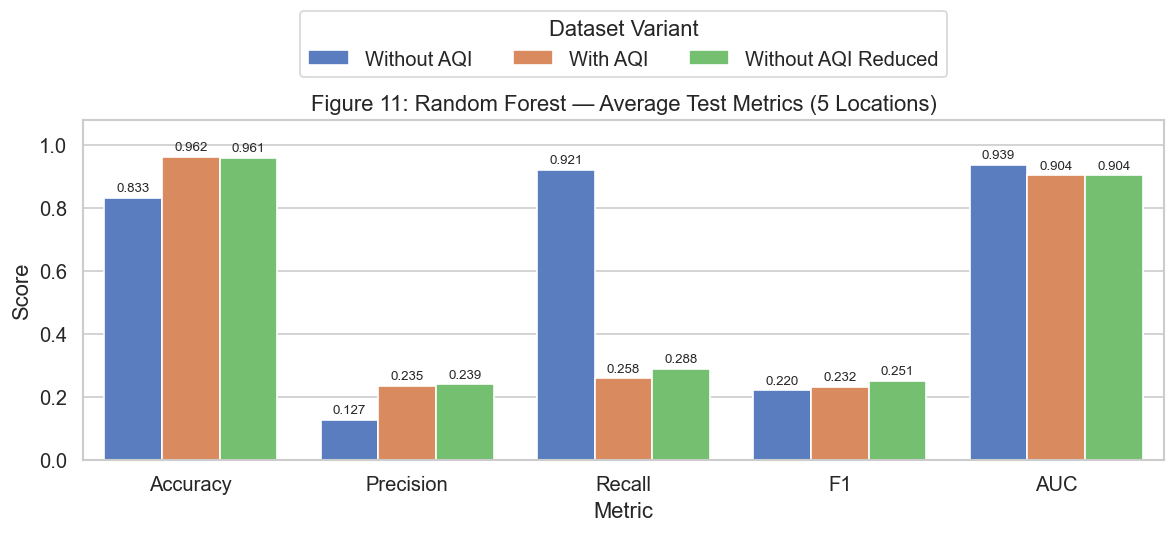

In [16]:
#| echo: false

rf = results_df[results_df['Model'] == 'Random Forest']
rf = rf[rf['Metric'].isin(metrics_order)]

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(data=rf, x='Metric', y='Value', hue='Variant', order=metrics_order, ax=ax)

ax.set_ylim(0, 1.08)
ax.set_title('Figure 11: Random Forest — Average Test Metrics (5 Locations)')
ax.set_ylabel('Score')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

ax.legend(title='Dataset Variant', loc='upper center', bbox_to_anchor=(0.5, 1.35), ncol=3)

plt.tight_layout()
plt.show()

The Random Forest results demonstrate improvements over logistic regression in precision, but reveal the model's inability to incorporate temporal context. The **Without AQI** variant achieves 12.68% precision and 92.13% recall. This is a minor improvement in precision (+2.6%) over logistic regression while maintaining comparably high recall. However, the **With AQI** and **Without AQI Reduced** variants exhibit a dramatic behavioral shift: precision nearly doubles to 23%.48% and 23.90% respectively, but recall collapses to just 25.78% and 28.78%. This indicates that Random Forest, when trained on the smaller 2022–2024 dataset, adopts a far more conservative decision boundary that sacrifices sensitivity for specificity and thereby misses approximately 70–75% of fog events to reduce false positives. The result of this tradeoff are F1-scores (0.22–0.25) that fail to substantially exceed logistic regression, despite Random Forest's capacity for nonlinear modeling.

This performance stems from Random Forest's lack of temporal awareness. Fog formation is inherently a dynamic process characterized by gradual atmospheric evolution, such as nocturnal cooling, gradual humidity increases, and wind speed decreases. By treating each hourly observation as independent, Random Forest cannot learn these sequential precursor signals. Instead, it must rely solely on instantaneous snapshots of atmospheric conditions, many of which are ambiguous when considered in isolation. For instance, an hour with 90% relative humidity and 2°C dewpoint depression might represent an imminent fog event if preceded by sustained cooling and moisture accumulation, or a transient state that quickly dissipates if followed by increasing temperatures or winds. Without access to temporal context, the model cannot distinguish between these scenarios, forcing it to either overpredict (high recall, low precision) or underpredict (low recall, high precision) depending on the decision threshold and dataset characteristics.

The dramatic precision-recall shift between the **Without AQI** variant and the **AQI-inclusive variants** further illustrates this limitation. The shorter time period likely contains fewer marginal or ambiguous cases—perhaps due to reduced climatic variability or data collection improvements in recent years, therefore allowing Random Forest to adopt a more selective threshold without catastrophically sacrificing recall. However, even with this advantage, the model still misses 70% of fog events in the **With AQI** variant, suggesting that instantaneous meteorological features alone are insufficient to precisely characterize fog formation. The nearly identical performance between **With AQI** (F1 = 0.2317) and **Without AQI Reduced** (F1 = 0.2511) confirms that AQI features provide minimal additional predictive power beyond what is already captured by weather variables, reinforcing earlier exploratory findings.


## XGBoost

XGBoost (eXtreme Gradient Boosting) builds an additive ensemble of regression trees, where each new tree $f_t$ minimizes a regularized objective:

$$\mathcal{L}^{(t)} = \sum_{i=1}^{N} l\left(y_i, \hat{y}_i^{(t-1)} + f_t(\mathbf{x}_i)\right) + \Omega(f_t)$$

$$\Omega(f) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_j^2$$

where $T$ is the number of leaves, $w_j$ are leaf weights, and $\gamma$, $\lambda$ are regularization parameters. A second-order Taylor expansion of the loss yields optimal leaf weights:

$$w_j^* = -\frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda}$$

where $g_i$ and $h_i$ are the first and second derivatives of the loss at each sample.

Configuration: 
- `n_estimators=10000`
- `max_depth=5`
- `learning_rate=0.05`
- `early_stopping_rounds=1000`
- `scale_pos_weight`
- `+F1 optimized threshold`

XGBoost is a refinement of the Random Forest approach through gradient boosting, where trees are added sequentially to correct errors made by previous iterations rather than being trained independently. This iterative error-correction mechanism is XGBoost's primary strength: each new tree focuses on the residuals (misclassified or poorly predicted instances) from the ensemble built so far, allowing the model to progressively refine decision boundaries in regions of feature space where classification is most difficult. For fog prediction, this means XGBoost can allocate modeling capacity to the challenging marginal cases rather than repeatedly modeling the easy, clear-cut distinctions that Random Forest's bagging approach may redundantly capture across many trees. Additionally, XGBoost's second-order gradient optimization and sophisticated regularization ($\gamma$, $\lambda$) provide fine-grained control over model complexity, enabling deeper learning of intricate meteorological patterns while mitigating overfitting through early stopping and penalization of overly complex trees.

However, XGBoost shares Random Forest's fundamental limitation: it lacks temporal awareness and treats each hourly observation as independent. While the boosting mechanism allows for more precise decision boundaries than bagging, it does not enable the model to learn sequential atmospheric evolution patterns. Although XGBoost's regularization and early stopping mitigate this risk, the shallow tree depth and conservative learning rate represent necessary compromises that may limit the model's ability to capture extremely complex, high-order feature interactions. The sequential nature of boosting also makes XGBoost more sensitive to class imbalance than Random Forest. Specifically, if early trees in the sequence consistently underpredict the minority fog class, later trees inherit this bias and may struggle to recover despite the usage of `scale_pos_weight` adjustments.

Given these characteristics, it was expected that XGBoost outperforms both logistic regression and Random Forest by achieving the best precision-recall balance among the non-temporal models. The iterative refinement should yield higher precision while maintaining reasonable recall, resulting in F1-scores improvements. It was theorized that XGBoost would particularly excel in the **Without AQI** variant where the large 45-year dataset provides ample training signal for the boosting process to refine decision boundaries, while performance may degrade slightly in the **AQI-inclusive** variants where the smaller sample size limits the benefit of iterative error correction.

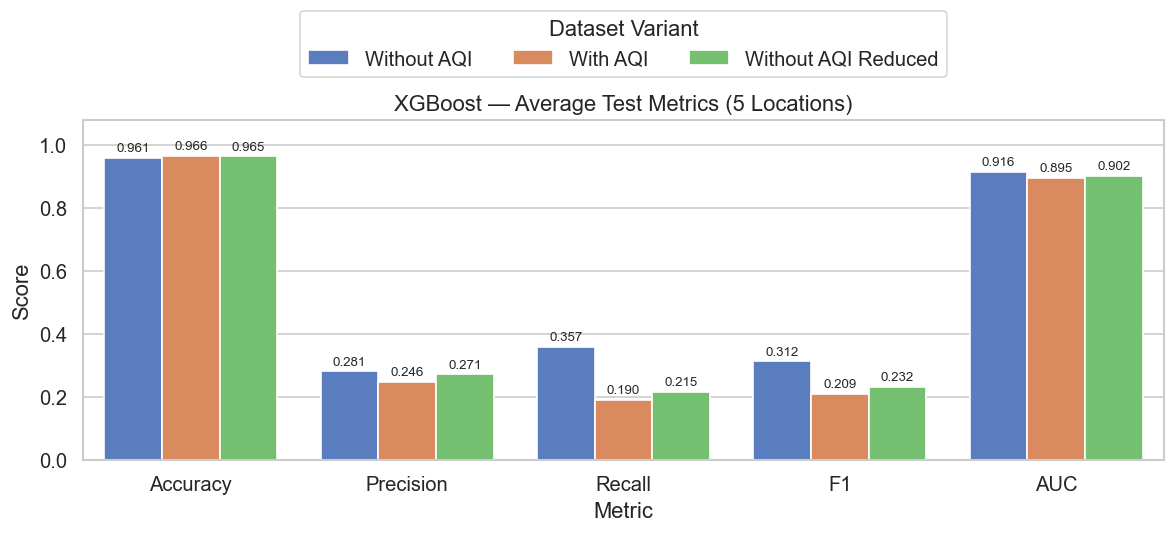

In [17]:
#| echo: false

xgb = results_df[results_df['Model'] == 'XGBoost']
xgb = xgb[xgb['Metric'].isin(metrics_order)]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=xgb, x='Metric', y='Value', hue='Variant', order=metrics_order, ax=ax)
ax.set_ylim(0, 1.08)
ax.set_title('XGBoost — Average Test Metrics (5 Locations)')
ax.set_ylabel('Score')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
ax.legend(title='Dataset Variant', loc='upper center', bbox_to_anchor=(0.5, 1.35), ncol=3)
plt.tight_layout()
plt.show()

XGBoost delivers the strongest performance among the non-temporal models as expected, achieving the best precision-recall balance and the highest F1-score across most variants. The **Without AQI** variant demonstrates this most clearly: 28.07% precision and 35.72% recall yield an F1-score of 0.3120, outperforming both logistic regression (F1 = 0.1793) and Random Forest (F1 = 0.2201). This improvement confirms that gradient boosting's iterative error-correction mechanism successfully refines decision boundaries in the challenging regions of feature space where atmospheric conditions are ambiguous. By progressively focusing on misclassified fog events and near-miss predictions, XGBoost learns more nuanced decision rules than Random Forest's independent trees or logistic regression's linear boundary, resulting in fewer false positives.

However, XGBoost's performance degrades significantly when applied to the AQI-inclusive datasets, revealing the model's shared limitation with other non-temporal approaches: inability to leverage sequential atmospheric evolution. The **With AQI** variant exhibits 24.65% precision and only 18.95% recall (F1 = 0.2091). This is worse than the **Without AQI** variant despite having access to five additional air quality features. This counterintuitive degradation arises from two factors. First, the much smaller training dataset provides insufficient examples for gradient boosting's iterative refinement to converge on robust decision boundaries, particularly for the rare fog class. Second, the AQI features introduce orthogonal variance that is not aligned with fog-relevant atmospheric structure (shown in k-means analysis), dust and PM10 capture substantial data variance but along dimensions that do not necessarily discriminate between fog and non-fog conditions. XGBoost's boosting process may overfit to these patterns in the limited training data, leading to decision rules that generalize poorly to the 2024 test set.

The **Without AQI Reduced** variant provides a controlled comparison that isolates the dataset size effect: with 27.07% precision, 21.52% recall, and F1 = 0.2321, this variant performs slightly better than **With AQI** but still worse than **Without AQI**. This confirms that the smaller temporal window (2022–2024) is the primary driver of performance degradation, not the AQI features themselves. The shorter time period offers fewer training examples and likely less climatic diversity limiting XGBoost's ability to learn generalizable fog formation patterns. Even with the best performance in the **Without AQI** variant, XGBoost still misses nearly two-thirds of fog events (recall 35.72%), demonstrating that instantaneous meteorological snapshots, regardless of how they are modeled through gradient boosting, are insufficient to fully characterize fog occurrence. Fog formation depends on temporal trajectories of cooling, moisture accumulation, and wind decay over preceding hours.


## Temporal Convolutional Neural Network

The Temporal CNN processes sequences of $L = 24$ consecutive hourly observations to capture atmospheric evolution patterns leading to fog formation. Each input is a matrix $\mathbf{X} \in \mathbb{R}^{L \times d}$ where $d$ is the number of features. The architecture consists of three 1D convolutional blocks with progressively increasing filter counts, followed by global max pooling and two fully connected layers:

**Convolutional Blocks:** Each block applies 1D convolution, batch normalization, and pooling with dropout:

$$\mathbf{z}_l^{(k)} = \text{Dropout}\left(\text{Pool}\left(\text{ReLU}\left(\text{BN}\left(\mathbf{W}^{(k)} * \mathbf{z}_{l-1} + \mathbf{b}^{(k)}\right)\right)\right)\right)$$

where $*$ denotes 1D convolution with kernel size 3 and `same` padding. The filter counts are 64, 128, and 256 for $k = 1, 2, 3$ respectively. The first two blocks use MaxPooling1D(2) while the third uses GlobalMaxPooling1D to extract the most salient temporal features.

**Dense Layers:** After global pooling, two fully connected layers with L2 regularization refine the representation:

$$\mathbf{h}_1 = \text{Dropout}_{0.55}\left(\text{BN}\left(\text{ReLU}(\mathbf{W}_1 \mathbf{h}_0 + \mathbf{b}_1)\right)\right), \quad \mathbf{W}_1 \in \mathbb{R}^{128 \times 256}$$

$$\mathbf{h}_2 = \text{Dropout}_{0.5}\left(\text{BN}\left(\text{ReLU}(\mathbf{W}_2 \mathbf{h}_1 + \mathbf{b}_2)\right)\right), \quad \mathbf{W}_2 \in \mathbb{R}^{64 \times 128}$$

$$\hat{y} = \sigma(\mathbf{W}_o \mathbf{h}_2 + b_o)$$

Both dense layers use L2 regularization with $\lambda = 0.01$: $\Omega(\mathbf{W}) = 0.01 \|\mathbf{W}\|_2^2$. The model is trained for up to 50 epochs using the Adam optimizer (learning rate 0.001), binary cross-entropy loss, class weights inversely proportional to class frequencies, and early stopping with patience 10 on validation loss.

The Temporal CNN's fundamental strength lies in its ability to model the sequential atmospheric evolution that precedes fog formation. By processing 24-hour lookback windows, the network can learn temporal patterns such as sustained nocturnal cooling, gradual moisture accumulation, and persistent calm wind conditions that collectively signal fog onset. The 1D convolutional filters act as learnable temporal pattern detectors: early layers capture short-range features like hour-to-hour temperature changes or humidity fluctuations, while deeper layers with larger receptive fields integrate these into longer-range patterns that span multiple hours. This hierarchical temporal feature extraction allows the model to distinguish between transient atmospheric states and sustained conditions that lead to fog. Additionally, the architecture's use of batch normalization, dropout (0.5-0.55), and L2 regularization provides strong regularization to prevent overfitting on the 45-year dataset's historical idiosyncrasies.

However, the Temporal CNN faces significant challenges related to data imbalance, sequence construction limitations, and model complexity. The fixed 24-hour window represents a rigid assumption about the timescale of fog formation: some fog events may develop on shorter timescales (e.g., 6-12 hours of rapid cooling) while others may require longer contextual windows (e.g., multi-day synoptic patterns). The architecture cannot adaptively adjust its temporal receptivity to different fog formation scenarios. The model's deep structure (3 convolutional blocks + 2 dense layers) also introduces substantial parameters (~500k-1M depending on input dimensions) that must be learned from a limited number of fog sequences, increasing the risk of overfitting despite regularization. The max pooling operations, while providing translation invariance and computational efficiency, discard temporal position information that may be relevant. For example, if peak humidity occurs at midnight versus 4am could be diagnostic of fog timing.

Nonetheless, it was expected that the Temporal CNN outperforms all other models by leveraging sequential atmospheric signals, but the degree of improvement may be constrained by class imbalance and sequence construction challenges. Improved recall compared to XGBoost was expected as the model learned to recognize the temporal precursor patterns that consistently precede fog formation, though precision may remain modest due to high class imbalance in the datasets. On the other hand, F1-scores should represent meaningful progress over non-temporal baselines, particularly if recall improves substantially. Performance on the **Without AQI** variant should theoretically be strongest due to the large 45-year training set providing diverse examples of fog-forming sequences across different seasons and climatic conditions.


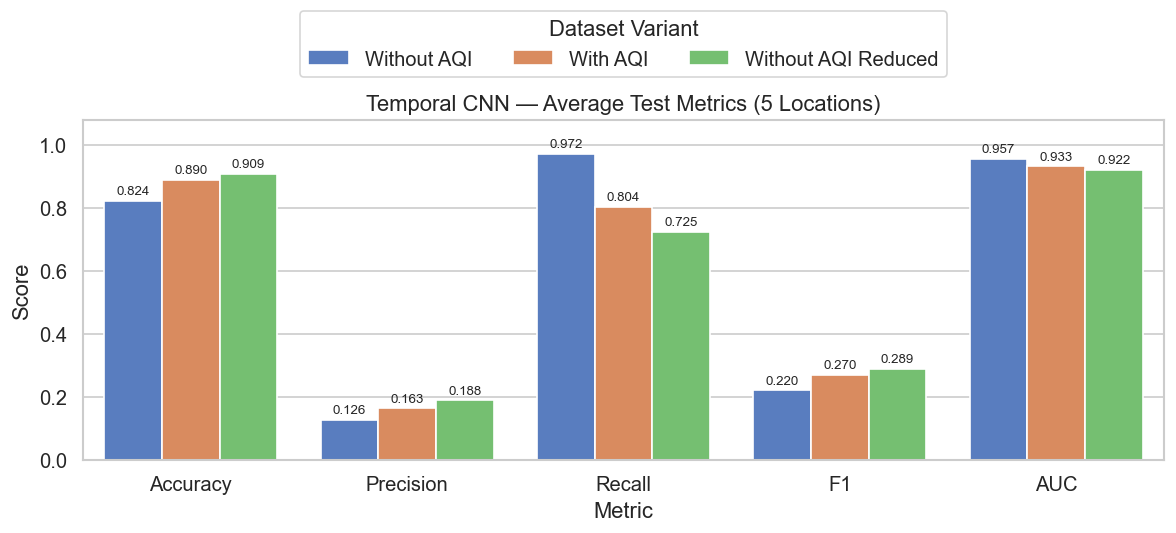

In [18]:
#| echo: false

cnn = results_df[results_df['Model'] == 'Temporal CNN']
cnn = cnn[cnn['Metric'].isin(metrics_order)]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=cnn, x='Metric', y='Value', hue='Variant', order=metrics_order, ax=ax)
ax.set_ylim(0, 1.08)
ax.set_title('Temporal CNN — Average Test Metrics (5 Locations)')
ax.set_ylabel('Score')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
ax.legend(title='Dataset Variant', loc='upper center', bbox_to_anchor=(0.5, 1.35), ncol=3)
plt.tight_layout()
plt.show()

The Temporal CNN results reveal a mixed outcome: despite having explicit access to 24-hour atmospheric evolution sequences, the model fails to translate this temporal awareness into improved classification performance relative to simpler, non-temporal approaches. The **Without AQI** variant exhibits 97.22% recall paired with only 12.61% precision, yielding an F1-score of 0.2201. This is identical to Random Forest and only marginally better than logistic regression (F1 = 0.1793). This extreme recall-precision imbalance mirrors the behavior of logistic regression from the baseline analysis, indicating that the Temporal CNN has adopted a similarly aggressive decision threshold that classifies a vast majority of ambiguous hours as fog in order to capture nearly all true fog events. For every correct fog prediction, the model generates approximately 7-8 false alarms.

This performance directly **reflects the model's struggle with the severe class imbalance problem**. With fog events representing <5% of observations, the training signal appears to be too sparse for the Temporal CNN to adequately outperform other approaches. The model's response with 97% recall and 13% precision suggests it learned to recognize broad atmospheric patterns associated with fog formation (high humidity, low temperature, calm winds sustained over multiple hours) but failed to learn the subtle distinctions that separate true fog-forming sequences from similar-but-non-fog sequences. The high AUC (0.9567) confirms that the model produces well-calibrated probability scores that correctly rank fog events higher than non-fog events, but the poor precision indicates the model's probability threshold cannot be adjusted to achieve acceptable specificity without sacrificing sensitivity.

The performance trends across dataset variants further expose the model's limitations. The **With AQI** variant shows improved precision (16.29%) but reduced recall (80.39%, F1 = 0.2697), while the **Without AQI Reduced** variant continues this pattern (18.78% precision, 72.48% recall, F1 = 0.2894). These results suggest that the smaller 2022-2024 dataset, while containing fewer training sequences overall, may present less ambiguous cases or benefit from more consistent modern data collection practices, allowing the model to adopt a more selective threshold. However, even the best F1-score (0.2894) barely exceeds logistic regression's performance on the same data (F1 = 0.2605) and falls well of XGBoost's **Without AQI** performance (F1 = 0.3120). This reveals that the theoretical advantage of temporal modeling is largely negated in practice by the compound challenges of extreme class imbalance and thus the model's inability to learn sufficiently discriminative temporal patterns from such an intensely sparse training signal.

## Sequential Stacking Ensemble

The ensemble combines all four base models in a sequential stacking architecture where each layer augments the input for the next:

**Layer 1 — Logistic Regression:** Trained on standardized features. Produces probability $p_1 = P_{\text{LR}}(\mathbf{x})$.

**Layer 2 — Random Forest:** Trained on original features concatenated with $p_1$. Produces $p_2 = P_{\text{RF}}(\mathbf{x} \| p_1)$.

**Layer 3 — XGBoost:** Trained on original features concatenated with $p_1$ and $p_2$. Produces $p_3 = P_{\text{XGB}}(\mathbf{x} \| p_1 \| p_2)$.

**Layer 4 — Temporal CNN:** Trained on standardized features concatenated with $p_1$, $p_2$, and $p_3$, reshaped into 24-step sequences. Produces $p_4 = P_{\text{CNN}}(\mathbf{X}_{24} \| p_1 \| p_2 \| p_3)$.

The final prediction is a weighted average:

$$\hat{p} = 0.10 \cdot p_1 + 0.20 \cdot p_2 + 0.30 \cdot p_3 + 0.40 \cdot p_4$$

An F1-optimized threshold $\tau^*$ converts $\hat{p}$ to binary predictions:

$$\hat{y} = \mathbb{1}[\hat{p} \geq \tau^*], \quad \tau^* = \arg\max_{\tau \in [0.01, 0.50]} F_1(\tau)$$

The stacking ensemble's fundamental strength lies in its ability to synthesize complementary modeling perspectives through a hierarchical architecture that progressively enriches the feature representation at each layer. By allowing later models to condition on the predictions of earlier models, the ensemble creates opportunities for deep error correction and pattern refinement that single models are unable to achieve. Logistic regression provides a simple, interpretable baseline that captures linear relationships; Random Forest adds the predictions from this linear perspective as a meta-feature while introducing nonlinear decision boundaries through its tree ensemble; XGBoost refines these boundaries by accessing both the logistic and Random Forest predictions; finally, the Temporal CNN integrates all three prior predictions along with the full 24-hour temporal context, potentially learning to weight different base models differently depending on atmospheric evolution patterns. The weighted averaging scheme (10%-20%-30%-40%) explicitly encodes a preference for more sophisticated models while preventing any single component from dominating, providing regularization through model diversity.

However, the ensemble faces significant challenges related to error propagation, complexity, and the fundamental data limitations that constrained individual models. The sequential architecture creates a dependency chain where errors from early layers compound through subsequent stages: if logistic regression consistently overpredicts fog (as observed, with 95% recall and 10% precision), its noisy probability estimates become input features for Random Forest, potentially misleading the tree-building process. Similarly, if both logistic regression and Random Forest produce overconfident predictions in ambiguous regions of feature space, XGBoost inherits a biased representation that may be difficult to correct through gradient boosting alone. The Temporal CNN, positioned at the final layer, must somehow untangle these accumulated errors while simultaneously processing 24-hour sequences. The fixed weighting scheme (10%-20%-30%-40%) represents a manual design choice rather than a learned meta-model, potentially suboptimal if the relative strengths of base models vary across different atmospheric conditions or locations. Most importantly, the ensemble cannot overcome the fundamental class imbalance and sparse fog signal that plagued individual models: stacking provides new perspectives on existing data but does not generate new training signal for the minority fog class.

Given these characteristics, it was expected that the stacking ensemble acieves the best overall performance across all models by successfully combining each component's strengths while mitigating weaknesses through diversification. The ensemble should achieve better precision-recall balance than individual models by leveraging XGBoost's precise boundaries to reduce false positives while relying on the Temporal CNN's high sensitivity to maintain detection of complex fog events. The strongest performance should occur in the **Without AQI** variant where the large 45-year dataset provides robust training for all base models, while AQI-inclusive variants may show degraded performance as individual model weaknesses (particularly XGBoost's struggle with small datasets and the CNN's precision issues) propagate through the stacking layers. However, it is not anticipated that the ensemble to deliver transformative performance beyond the 0.40 F1-score ceiling, as the fundamental challenges of an insufficiently strong signal impose a hard performance ceiling that no combination of models can overcome.


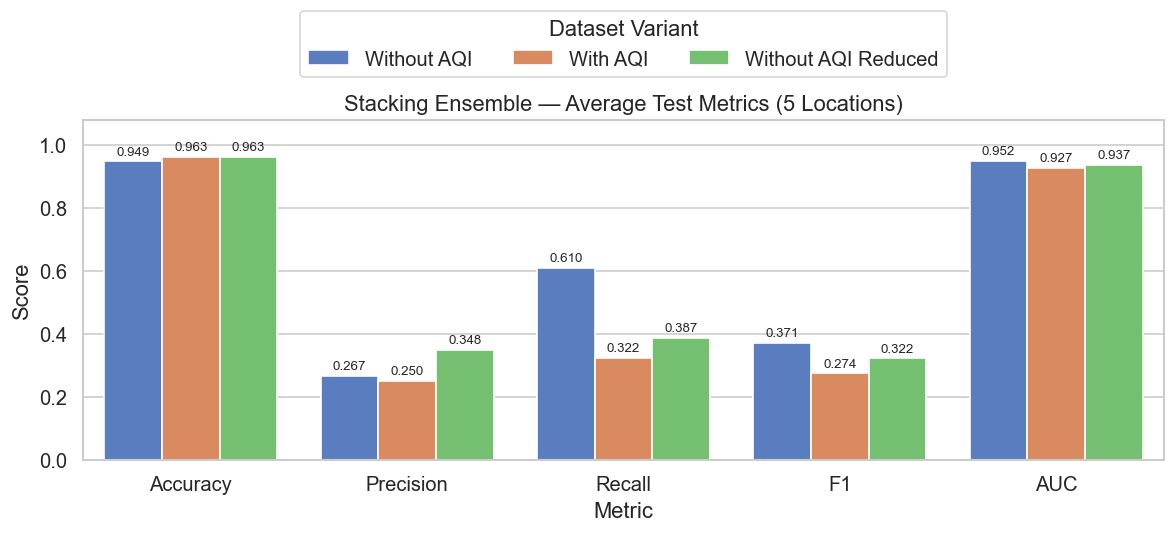

In [19]:
#| echo: false

ens = results_df[results_df['Model'] == 'Stacking Ensemble']
ens = ens[ens['Metric'].isin(metrics_order)]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=ens, x='Metric', y='Value', hue='Variant', order=metrics_order, ax=ax)
ax.set_ylim(0, 1.08)
ax.set_title('Stacking Ensemble — Average Test Metrics (5 Locations)')
ax.set_ylabel('Score')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
ax.legend(title='Dataset Variant', loc='upper center', bbox_to_anchor=(0.5, 1.35), ncol=3)
plt.tight_layout()
plt.show()

The stacking ensemble achieves the strongest overall performance of all models, confirming that multi-model synthesis provides meaningful value beyond individual approaches. The **Without AQI** variant delivers F1 = 0.3706 with 26.68% precision and 61.04% recall, which vastly exceeds XGBoost's standalone result (F1 = 0.3120, precision 28.07%, recall 35.72%) and doubling the logistic regression baseline (F1 = 0.1793). This improvement demonstrates that the hierarchical stacking architecture successfully leverages complementary strengths: XGBoost contributes precise decision boundaries that reduce false positives, while the Temporal CNN's high sensitivity (97% recall standalone) helps maintain fog detection coverage, and the intermediate models provide regularization through diversity. The 61% recall represents a practical compromise. Detection of roughly three-fifths of fog events while generating approximately 2.7 false alarms per correct prediction (down from XGBoost's 2.6 but far better than the CNN's ~7.9) places this hybrid approach as the best-fit candidate for further development. The strong AUC (0.9515) confirms good probability calibration across the full range of atmospheric conditions.

However, the ensemble's performance continues to reflect the challenges presented by the sparse minority fog class. First, the precision ceiling of 27% remains operationally problematic: even with sophisticated multi-model fusion, the system cannot reliably distinguish fog-forming conditions from superficially similar atmospheric states, generating roughly three false alarms for every correct detection. This suggests that the hourly meteorological features themselves contain insufficient signal to precisely characterize fog occurrence at the time of prediction. Second, the **With AQI** variant exhibits dramatic performance degradation (F1 = 0.2742), falling below even XGBoost's standalone performance on the same data (F1 = 0.2091 for XGBoost With AQI, though note XGBoost Without AQI was 0.3120). This result indicates error propagation through the stacking layers: the small 2.5-year AQI dataset causes individual base models to produce noisy, overconfident predictions that mislead subsequent layers, with errors compounding through the sequential architecture. The Temporal CNN at the final layer then inherits these corrupted probability estimates and fails to untangle them.

ON the other hand, the **Without AQI Reduced** variant demonstrates the ensemble's best precision (34.77%) though with modest recall (38.73%, F1 = 0.3218). This pattern of higher precision achieved through the same stacking architecture suggests that when base models are trained on cleaner, more recent data (2022-2024) they produce more reliable probability estimates that the ensemble can effectively synthesize. The improved precision indicates fewer false alarms (roughly 1.9 per correct detection versus 2.7 for Without AQI), though this comes at the cost of missing 61% of fog events. The tradeoff reflects the fundamental tension in fog prediction: atmospheric conditions can be ambiguous even with perfect data, and the model must choose between casting a wide net (high recall, many false positives) or being selective (high precision, many missed events). In the context of this problem where missed events can result in catastrophic outcomes, prioritization of models with high recall, such as the standalone CNN, emerge as the better choice in practical usage.

Overall, the stacking ensemble results establish the practical performance ceiling for conventional machine learning approaches on this fog prediction task: F1-scores around 0.35-0.37 with precision 27-35% and recall 39-61% depending on dataset characteristics and precision-recall preference. These results represent meaningful progress over simpler baselines (reducing false alarms or improving detection coverage) but fall short of the practical reliability required for real-world fog warning systems. The persistent precision limitations across all variants, including the sophisticated ensemble, suggest that further improvements will require either (1) additional data sources beyond hourly meteorological observations (e.g., satellite imagery, radar, upstream weather station networks), (2) longer temporal context beyond 24-hour windows to capture multi-day synoptic patterns, or (3) physics-informed modeling approaches that explicitly incorporate atmospheric process understanding rather than treating fog prediction as a purely statistical pattern recognition problem.


## Model Comparison

The following figure provides a direct comparison of all five models on key metrics. The **Without AQI** dataset was chosen as the baseline due to the higher performance of all models on this variant.

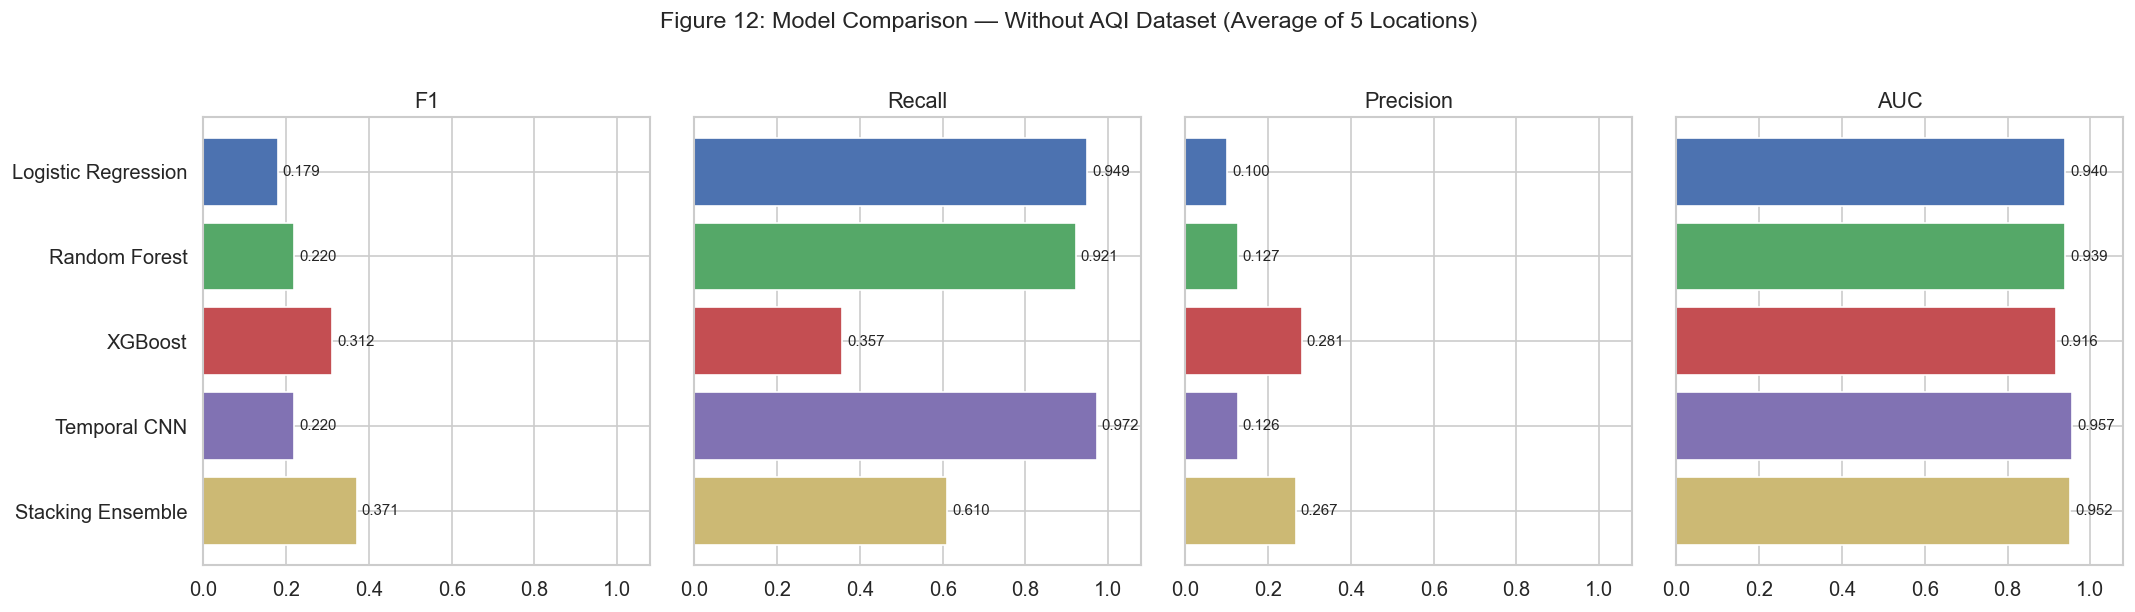

In [20]:
#| echo: false

wo_aqi = results_df[results_df['Variant'] == 'Without AQI']
compare_metrics = ['F1', 'Recall', 'Precision', 'AUC']
wo_aqi = wo_aqi[wo_aqi['Metric'].isin(compare_metrics)]

model_order = ['Logistic Regression', 'Random Forest', 'XGBoost', 'Temporal CNN', 'Stacking Ensemble']
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b3', '#ccb974']

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

for i, metric in enumerate(compare_metrics):
    ax = axes[i]
    subset = wo_aqi[wo_aqi['Metric'] == metric].set_index('Model').loc[model_order]
    bars = ax.barh(subset.index, subset['Value'], color=colors)
    ax.set_xlim(0, 1.08)
    ax.set_title(metric, fontsize=13)
    ax.bar_label(bars, fmt='%.3f', fontsize=9, padding=3)

axes[0].invert_yaxis()
plt.suptitle('Figure 12: Model Comparison — Without AQI Dataset (Average of 5 Locations)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The following figure compares F1-scores for each model across the datasets. Note how the **Without AQI** variant consistently achieves the highest F1-scores for XGBoost and the Stacking Ensemble due to its substantially larger training set, while the AQI-inclusive variants show mixed results with performance degradation across most models.

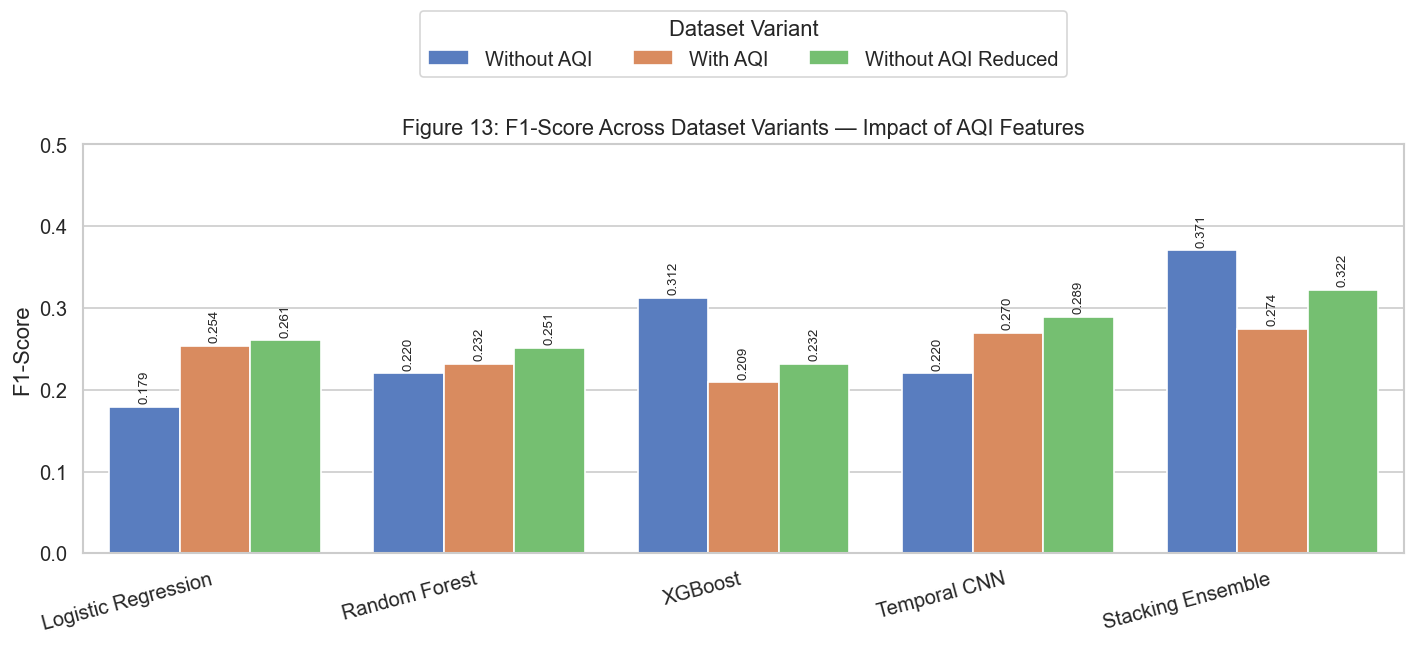

In [21]:
#| echo: false

f1_data = results_df[results_df['Metric'] == 'F1'].copy()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=f1_data, x='Model', y='Value', hue='Variant',
            order=model_order, ax=ax)
ax.set_ylim(0, 0.5)
ax.set_title('Figure 13: F1-Score Across Dataset Variants — Impact of AQI Features', fontsize=13)
ax.set_ylabel('F1-Score')
ax.set_xlabel('')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2, rotation=90)
ax.legend(title='Dataset Variant', loc='upper center', bbox_to_anchor=(0.5, 1.35), ncol=3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

# Discussion & Conclusion

**1. The Stacking Ensemble achieves the highest F1-score (0.371).** By combining predictions from all four base models in a sequential pipeline, the ensemble balances recall (0.610) and precision (0.267) more effectively than any individual model. This confirms that model diversity and hierarchical feature augmentation provide complementary predictive signal.

**2. The Temporal CNN achieves the highest recall (0.972) but the lowest precision (0.126).** The CNN's ability to process 24-hour sequences allows it to detect nearly all fog events, but it over-predicts fog substantially.

**3. XGBoost provides the best precision-recall balance among individual models (F1 = 0.312).** Its regularized gradient boosting and F1-optimized threshold allow it to avoid many false positives while maintaining moderate recall (0.357).

**4. AQI features provide no net benefit and lower performance.** Across all five models, the **Without AQI** variant outperforms or matches the **With AQI** variant. The controlled variant outperforms the **With AQI** as well. This indicates that, at this current time, the available volume of non-AQI based data provides a clearer signal for predictive modeling approaches.

In conclusion, all modeling approaches faced the same significant challenge: an inadequate positive class which resulted in a class imbalance too dense to overcome. This challenge was further exacerbated within the **With AQI** dataset variant, which was limited in size by several order of magnitude compared to its historical, non-AQI counterpart. Despite these limitations, this study demonstrates that machine learning approaches can detect fog events with meaningful recall, and that ensemble methods offer the best path forward for balancing precision and recall. Future work should prioritize expanding the dataset with additional fog observations, exploring advanced resampling techniques such as SMOTE or focal loss to better address class imbalance, and investigating real-time prediction systems that incorporate satellite imagery and localized weather station data. With California's Central Valley continuing to experience hazardous fog conditions, the development of accurate predictive models remains critical for improving public safety and reducing traffic-related incidents.

# References

[1] E. Navarro, M. A. Lopez, and G. Ferris, "Highway 99 in Tulare County reopens after 59-vehicle pileup, CHP says," ABC30 Fresno (KFSN-TV), Feb. 1, 2026. [Online]. Available: https://abc30.com/post/150-vehicle-pileup-forces-total-closure-highway-99-tulare-county-officials-say/18516483/

[2] California Office of Traffic Safety, California FY2023 Annual Report. Washington, DC, USA: National Highway Traffic Safety Administration, May 2024. [Online]. Available: https://www.nhtsa.gov/sites/nhtsa.gov/files/2024-05/CA%20FY23%20Annual%20Report-tag.pdf

[3] L. Doermann, "An unrelenting tule fog," NASA Earth Observatory, National Aeronautics and Space Administration, Dec. 11, 2025. [Online]. Available: https://science.nasa.gov/earth/earth-observatory/an-unrelenting-tule-fog/

[4] E. Gray, S. Gilardoni, D. Baldocchi, B. C. McDonald, M. C. Facchini, and A. H. Goldstein, "Impact of air pollution controls on radiation fog frequency in the Central Valley of California," J. Geophys. Res. Atmos., vol. 124, no. 10, pp. 5872–5895, Jun. 2019, doi: 10.1029/2018JD029419.

[5] K. Lakra and K. Avishek, "A review on factors influencing fog formation, classification, forecasting, detection and impacts," Rend. Lincei Sci. Fis. Nat., vol. 33, no. 2, pp. 319–353, Mar. 2022, doi: 10.1007/s12210-022-01060-1.

[6] Open-Meteo, "Free weather API," Open-Meteo.com. [Online]. Available: https://open-meteo.com/. [Accessed: Mar. 16, 2026].

[7] National Centers for Environmental Information, "Data Access," NOAA NCEI. [Online]. Available: https://www.ncei.noaa.gov/access/search/index. [Accessed: Mar. 16, 2026].

[8] I. Gultepe et al., "Fog research: A review of past achievements and future perspectives," Pure Appl. Geophys., vol. 164, pp. 1121–1159, Jun. 2007, doi: 10.1007/s00024-007-0211-x.

# Appendix A — Pearson Coefficients for Predictors

In [22]:
#| echo: false

from IPython.display import display, Markdown
import pandas as pd

WEATHER_VARS = ['temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'precipitation',
                'rain', 'surface_pressure', 'et0_fao_evapotranspiration', 'vapour_pressure_deficit',
                'wind_speed_10m', 'wind_speed_100m', 'wind_gusts_10m',
                'soil_temperature_0_to_7cm', 'soil_temperature_7_to_28cm',
                'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm']

AQI_VARS = ['pm10', 'pm2_5', 'aerosol_optical_depth', 'dust', 'nitrogen_dioxide']

INFERRED_VARS = ['dewpoint_depression', 'cooling_rate_6h', 'cooling_rate_12h', 'previous_night_low']


def corr_table(df, features, target='visibility_meters'):
    cols = [c for c in features if c in df.columns]
    if not cols:
        return pd.DataFrame(columns=['Variable', 'Pearson r', '|r|'])

    corr = df[cols + [target]].corr()[target].drop(target)

    result = pd.DataFrame({
        'Variable': corr.index,
        'Pearson r': corr.values
    })

    result['|r|'] = result['Pearson r'].abs()

    return result.sort_values('|r|', ascending=False).reset_index(drop=True)


for loc_num, loc_info in data.items():
    df = loc_info['without_aqi']
    tbl = corr_table(df, WEATHER_VARS)
    
    tbl = tbl.rename(columns={
        'Variable': f"Weather Variable Correlations for {loc_info['name']}",
        'Pearson r': 'Pearson r',
        '|r|': '|r|'
    })
    
    display(tbl)

weather_tables = [
    corr_table(loc_info['without_aqi'], WEATHER_VARS).set_index('Variable')[['Pearson r']]
    .rename(columns={'Pearson r': loc_info['name']})
    for loc_num, loc_info in data.items()
]

agg_w = pd.concat(weather_tables, axis=1)
agg_w['Mean r'] = agg_w.mean(axis=1)
agg_w['|Mean r|'] = agg_w['Mean r'].abs()
agg_w = agg_w.sort_values('|Mean r|', ascending=False)

agg_w = agg_w.reset_index()

agg_w = agg_w.rename(columns={
    'Variable': 'Weather Variable',
    'Mean r': 'Mean Pearson r',
    '|Mean r|': 'Mean |r|'
})

display(agg_w[['Weather Variable', 'Mean Pearson r', 'Mean |r|']])

for loc_num, loc_info in data.items():
    df = loc_info['with_aqi']
    tbl = corr_table(df, AQI_VARS)
    
    tbl = tbl.rename(columns={
        'Variable': f"AQI Variable Correlations for {loc_info['name']}",
        'Pearson r': 'Pearson r',
        '|r|': '|r|'
    })
    
    display(tbl)

aqi_tables = [
    corr_table(loc_info['with_aqi'], AQI_VARS).set_index('Variable')[['Pearson r']]
    .rename(columns={'Pearson r': loc_info['name']})
    for loc_num, loc_info in data.items()
]

agg_a = pd.concat(aqi_tables, axis=1)
agg_a['Mean r'] = agg_a.mean(axis=1)
agg_a['|Mean r|'] = agg_a['Mean r'].abs()
agg_a = agg_a.sort_values('|Mean r|', ascending=False)
agg_a = agg_a.reset_index()

agg_a = agg_a.rename(columns={
    'Variable': 'AQI Variable',
    'Mean r': 'Mean Pearson r',
    '|Mean r|': 'Mean |r|'
})

display(agg_a[['AQI Variable', 'Mean Pearson r', 'Mean |r|']])

for loc_num, loc_info in data.items():
    df = loc_info['without_aqi']
    tbl = corr_table(df, INFERRED_VARS)
    
    tbl = tbl.rename(columns={
        'Variable': f"Inferred Variable Correlations for {loc_info['name']}",
        'Pearson r': 'Pearson r',
        '|r|': '|r|'
    })
    
    display(tbl)

inf_tables = [
    corr_table(loc_info['without_aqi'], INFERRED_VARS).set_index('Variable')[['Pearson r']]
    .rename(columns={'Pearson r': loc_info['name']})
    for loc_num, loc_info in data.items()
]

agg_i = pd.concat(inf_tables, axis=1)
agg_i['Mean r'] = agg_i.mean(axis=1)
agg_i['|Mean r|'] = agg_i['Mean r'].abs()
agg_i = agg_i.sort_values('|Mean r|', ascending=False)

agg_i = agg_i.reset_index()

agg_i = agg_i.rename(columns={
    'Variable': 'Inferred Variable',
    'Mean r': 'Mean Pearson r',
    '|Mean r|': 'Mean |r|'
})

display(agg_i[['Inferred Variable', 'Mean Pearson r', 'Mean |r|']])

,Weather Variable Correlations for Madera Airport,Pearson r,|r|
0,soil_temperature_7_to_28cm,0.377078,0.377078
1,surface_pressure,-0.300592,0.300592
2,soil_temperature_0_to_7cm,0.299374,0.299374
3,temperature_2m,0.256116,0.256116
4,relative_humidity_2m,-0.253132,0.253132
5,soil_moisture_0_to_7cm,-0.248368,0.248368
6,wind_speed_100m,0.245728,0.245728
7,wind_speed_10m,0.234854,0.234854
8,vapour_pressure_deficit,0.220354,0.220354
9,wind_gusts_10m,0.219550,0.219550


,Weather Variable Correlations for Fresno Airport,Pearson r,|r|
0,soil_temperature_7_to_28cm,0.341873,0.341873
1,surface_pressure,-0.288860,0.288860
2,soil_temperature_0_to_7cm,0.281448,0.281448
3,temperature_2m,0.248664,0.248664
4,soil_moisture_0_to_7cm,-0.221295,0.221295
5,relative_humidity_2m,-0.215724,0.215724
6,wind_gusts_10m,0.197985,0.197985
7,wind_speed_100m,0.187792,0.187792
8,soil_moisture_7_to_28cm,-0.183458,0.183458
9,vapour_pressure_deficit,0.182892,0.182892


,Weather Variable Correlations for Visalia Airport,Pearson r,|r|
0,soil_temperature_7_to_28cm,0.372283,0.372283
1,surface_pressure,-0.332688,0.332688
2,soil_temperature_0_to_7cm,0.295677,0.295677
3,temperature_2m,0.243090,0.243090
4,relative_humidity_2m,-0.242687,0.242687
5,soil_moisture_0_to_7cm,-0.237460,0.237460
6,vapour_pressure_deficit,0.222804,0.222804
7,soil_moisture_7_to_28cm,-0.220782,0.220782
8,wind_speed_10m,0.200542,0.200542
9,wind_speed_100m,0.198285,0.198285


,Weather Variable Correlations for Hanford Airport,Pearson r,|r|
0,soil_temperature_7_to_28cm,0.439807,0.439807
1,surface_pressure,-0.356521,0.356521
2,soil_temperature_0_to_7cm,0.324951,0.324951
3,wind_speed_100m,0.279575,0.279575
4,wind_speed_10m,0.261422,0.261422
5,temperature_2m,0.258619,0.258619
6,soil_moisture_0_to_7cm,-0.249494,0.249494
7,relative_humidity_2m,-0.231988,0.231988
8,vapour_pressure_deficit,0.228645,0.228645
9,wind_gusts_10m,0.226981,0.226981


,Weather Variable Correlations for Bakersfield Airport,Pearson r,|r|
0,soil_temperature_7_to_28cm,0.183249,0.183249
1,surface_pressure,-0.179847,0.179847
2,soil_temperature_0_to_7cm,0.132013,0.132013
3,dew_point_2m,0.120460,0.120460
4,temperature_2m,0.111254,0.111254
5,et0_fao_evapotranspiration,0.083865,0.083865
6,relative_humidity_2m,-0.077174,0.077174
7,vapour_pressure_deficit,0.060658,0.060658
8,soil_moisture_0_to_7cm,-0.056180,0.056180
9,soil_moisture_7_to_28cm,0.037038,0.037038


...

,Inferred Variable Correlations for Fresno Airport,Pearson r,|r|
0,previous_night_low,0.328798,0.328798
1,dewpoint_depression,0.188694,0.188694
2,cooling_rate_12h,-0.085631,0.085631
3,cooling_rate_6h,-0.051198,0.051198


,Inferred Variable Correlations for Visalia Airport,Pearson r,|r|
0,previous_night_low,0.352691,0.352691
1,dewpoint_depression,0.235897,0.235897
2,cooling_rate_12h,-0.140694,0.140694
3,cooling_rate_6h,-0.135416,0.135416


,Inferred Variable Correlations for Hanford Airport,Pearson r,|r|
0,previous_night_low,0.417615,0.417615
1,dewpoint_depression,0.227464,0.227464
2,cooling_rate_12h,-0.193214,0.193214
3,cooling_rate_6h,-0.187136,0.187136


,Inferred Variable Correlations for Bakersfield Airport,Pearson r,|r|
0,previous_night_low,0.184777,0.184777
1,cooling_rate_12h,-0.079690,0.079690
2,dewpoint_depression,0.050397,0.050397
3,cooling_rate_6h,-0.001806,0.001806


,Inferred Variable,Mean Pearson r,Mean |r|
0,previous_night_low,0.328846,0.328846
1,dewpoint_depression,0.187950,0.187950
2,cooling_rate_12h,-0.121242,0.121242
3,cooling_rate_6h,-0.096979,0.096979


# Appendix B — K-Means Clustering Raw Results

In [23]:
#| output: false
#| echo: true
#| eval: false

LOCATION 10
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 365120
  Inertia: 2617205.83
  Silhouette Score: 0.2016
  Davies-Bouldin Index: 1.4035

  Feature Variance Across Clusters (sorted, 19 features):
    rain: 26.34%
    precipitation: 26.16%
    vapour_pressure_deficit: 4.23%
    dewpoint_depression: 3.95%
    wind_speed_100m: 3.88%
    relative_humidity_2m: 3.51%
    soil_temperature_0_to_7cm: 3.38%
    wind_speed_10m: 3.38%
    temperature_2m: 3.29%
    wind_gusts_10m: 3.23%
    soil_moisture_0_to_7cm: 3.09%
    et0_fao_evapotranspiration: 2.79%
    soil_temperature_7_to_28cm: 2.75%
    previous_night_low: 2.28%
    soil_moisture_7_to_28cm: 1.91%
    cooling_rate_6h: 1.83%
    cooling_rate_12h: 1.79%
    surface_pressure: 1.39%
    dew_point_2m: 0.82%

WITH AQI (filtered rows, with AQI features):
  Records: 25691
  Inertia: 268380.45
  Silhouette Score: 0.1826
  Davies-Bouldin Index: 1.5409

  Feature Variance Across Clusters (sorted, 24 features):
    rain: 27.58%
    precipitation: 26.96%
    pm10: 4.32%
    dust: 3.85%
    soil_moisture_0_to_7cm: 2.84%
    relative_humidity_2m: 2.50%
    wind_speed_10m: 2.29%
    soil_temperature_7_to_28cm: 2.29%
    wind_speed_100m: 2.29%
    wind_gusts_10m: 2.29%
    pm2_5: 2.27%
    soil_temperature_0_to_7cm: 2.23%
    dewpoint_depression: 2.21%
    temperature_2m: 2.20%
    previous_night_low: 2.11%
    vapour_pressure_deficit: 2.05%
    et0_fao_evapotranspiration: 1.80%
    cooling_rate_6h: 1.59%
    soil_moisture_7_to_28cm: 1.46%
    surface_pressure: 1.38%
    cooling_rate_12h: 1.29%
    nitrogen_dioxide: 0.94%
    aerosol_optical_depth: 0.77%
    dew_point_2m: 0.48%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 25691
  Inertia: 166323.66
  Silhouette Score: 0.2233
  Davies-Bouldin Index: 1.3952

  Feature Variance Across Clusters (sorted, 19 features):
    rain: 30.67%
    precipitation: 30.07%
    soil_moisture_0_to_7cm: 2.93%
    relative_humidity_2m: 2.87%
    wind_speed_100m: 2.86%
    dewpoint_depression: 2.84%
    soil_temperature_0_to_7cm: 2.81%
    vapour_pressure_deficit: 2.75%
    wind_speed_10m: 2.75%
    temperature_2m: 2.71%
    wind_gusts_10m: 2.54%
    soil_temperature_7_to_28cm: 2.43%
    et0_fao_evapotranspiration: 2.41%
    previous_night_low: 2.17%
    cooling_rate_6h: 1.89%
    soil_moisture_7_to_28cm: 1.62%
    cooling_rate_12h: 1.61%
    surface_pressure: 1.50%
    dew_point_2m: 0.57%

================================================================================

LOCATION 6
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 164421
  Inertia: 1063459.57
  Silhouette Score: 0.2088
  Davies-Bouldin Index: 1.3889

  Feature Variance Across Clusters (sorted, 19 features):
    rain: 25.95%
    precipitation: 25.94%
    soil_moisture_0_to_7cm: 4.35%
    relative_humidity_2m: 3.49%
    soil_temperature_0_to_7cm: 3.31%
    soil_temperature_7_to_28cm: 3.30%
    dewpoint_depression: 3.26%
    soil_moisture_7_to_28cm: 3.24%
    temperature_2m: 3.15%
    vapour_pressure_deficit: 3.11%
    wind_speed_100m: 3.02%
    et0_fao_evapotranspiration: 2.80%
    wind_speed_10m: 2.75%
    wind_gusts_10m: 2.73%
    previous_night_low: 2.65%
    cooling_rate_6h: 2.32%
    cooling_rate_12h: 2.07%
    surface_pressure: 1.84%
    dew_point_2m: 0.73%

WITH AQI (filtered rows, with AQI features):
  Records: 25558
  Inertia: 262365.04
  Silhouette Score: 0.2087
  Davies-Bouldin Index: 1.4584

  Feature Variance Across Clusters (sorted, 24 features):
    rain: 23.10%
    precipitation: 23.01%
    dust: 7.94%
    pm10: 4.48%
    soil_moisture_0_to_7cm: 3.41%
    relative_humidity_2m: 2.63%
    wind_gusts_10m: 2.62%
    wind_speed_100m: 2.61%
    wind_speed_10m: 2.57%
    soil_temperature_0_to_7cm: 2.54%
    temperature_2m: 2.47%
    dewpoint_depression: 2.43%
    soil_temperature_7_to_28cm: 2.42%
    vapour_pressure_deficit: 2.31%
    et0_fao_evapotranspiration: 2.21%
    soil_moisture_7_to_28cm: 2.05%
    previous_night_low: 2.04%
    nitrogen_dioxide: 2.00%
    cooling_rate_6h: 1.76%
    cooling_rate_12h: 1.56%
    surface_pressure: 1.56%
    pm2_5: 1.14%
    dew_point_2m: 0.68%
    aerosol_optical_depth: 0.46%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 25558
  Inertia: 164047.65
  Silhouette Score: 0.2087
  Davies-Bouldin Index: 1.3686

  Feature Variance Across Clusters (sorted, 19 features):
    rain: 26.36%
    precipitation: 26.27%
    soil_moisture_0_to_7cm: 4.18%
    relative_humidity_2m: 3.38%
    soil_temperature_7_to_28cm: 3.31%
    soil_temperature_0_to_7cm: 3.30%
    soil_moisture_7_to_28cm: 3.28%
    dewpoint_depression: 3.20%
    temperature_2m: 3.13%
    vapour_pressure_deficit: 2.99%
    et0_fao_evapotranspiration: 2.83%
    wind_speed_100m: 2.78%
    previous_night_low: 2.70%
    wind_gusts_10m: 2.67%
    wind_speed_10m: 2.63%
    cooling_rate_6h: 2.36%
    cooling_rate_12h: 1.93%
    surface_pressure: 1.83%
    dew_point_2m: 0.87%

================================================================================

LOCATION 7
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 392427
  Inertia: 2526989.85
  Silhouette Score: 0.2119
  Davies-Bouldin Index: 1.3617

  Feature Variance Across Clusters (sorted, 19 features):
    precipitation: 23.50%
    rain: 23.49%
    soil_moisture_0_to_7cm: 4.72%
    relative_humidity_2m: 3.88%
    soil_temperature_7_to_28cm: 3.64%
    soil_temperature_0_to_7cm: 3.56%
    soil_moisture_7_to_28cm: 3.56%
    dewpoint_depression: 3.51%
    wind_speed_100m: 3.44%
    temperature_2m: 3.40%
    vapour_pressure_deficit: 3.32%
    wind_gusts_10m: 3.12%
    wind_speed_10m: 3.08%
    et0_fao_evapotranspiration: 3.02%
    previous_night_low: 2.93%
    cooling_rate_6h: 2.62%
    cooling_rate_12h: 2.28%
    surface_pressure: 1.89%
    dew_point_2m: 1.04%

WITH AQI (filtered rows, with AQI features):
  Records: 25748
  Inertia: 259556.46
  Silhouette Score: 0.1905
  Davies-Bouldin Index: 1.4757

  Feature Variance Across Clusters (sorted, 24 features):
    precipitation: 25.13%
    rain: 25.09%
    dust: 5.79%
    soil_moisture_0_to_7cm: 3.67%
    soil_temperature_7_to_28cm: 2.84%
    pm10: 2.83%
    relative_humidity_2m: 2.70%
    soil_temperature_0_to_7cm: 2.63%
    dewpoint_depression: 2.44%
    temperature_2m: 2.43%
    soil_moisture_7_to_28cm: 2.39%
    wind_speed_100m: 2.32%
    previous_night_low: 2.30%
    vapour_pressure_deficit: 2.28%
    et0_fao_evapotranspiration: 2.24%
    cooling_rate_6h: 2.10%
    wind_gusts_10m: 1.94%
    wind_speed_10m: 1.93%
    cooling_rate_12h: 1.67%
    surface_pressure: 1.52%
    nitrogen_dioxide: 1.36%
    pm2_5: 0.88%
    dew_point_2m: 0.77%
    aerosol_optical_depth: 0.75%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 25748
  Inertia: 159702.68
  Silhouette Score: 0.2038
  Davies-Bouldin Index: 1.3619

  Feature Variance Across Clusters (sorted, 19 features):
    precipitation: 27.12%
    rain: 27.09%
    soil_moisture_0_to_7cm: 3.98%
    relative_humidity_2m: 3.21%
    soil_temperature_7_to_28cm: 3.14%
    soil_temperature_0_to_7cm: 3.11%
    wind_speed_100m: 3.04%
    temperature_2m: 2.97%
    dewpoint_depression: 2.97%
    soil_moisture_7_to_28cm: 2.88%
    vapour_pressure_deficit: 2.78%
    wind_speed_10m: 2.72%
    et0_fao_evapotranspiration: 2.71%
    wind_gusts_10m: 2.69%
    previous_night_low: 2.62%
    cooling_rate_6h: 2.35%
    cooling_rate_12h: 1.91%
    surface_pressure: 1.75%
    dew_point_2m: 0.95%

================================================================================

LOCATION 8
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 166085
  Inertia: 1107510.98
  Silhouette Score: 0.2018
  Davies-Bouldin Index: 1.3904

  Feature Variance Across Clusters (sorted, 19 features):
    rain: 27.32%
    precipitation: 27.24%
    soil_moisture_0_to_7cm: 4.13%
    relative_humidity_2m: 3.54%
    dewpoint_depression: 3.17%
    soil_temperature_7_to_28cm: 3.08%
    soil_temperature_0_to_7cm: 3.04%
    vapour_pressure_deficit: 3.00%
    temperature_2m: 2.98%
    soil_moisture_7_to_28cm: 2.89%
    wind_speed_100m: 2.79%
    previous_night_low: 2.61%
    wind_speed_10m: 2.56%
    wind_gusts_10m: 2.55%
    et0_fao_evapotranspiration: 2.54%
    cooling_rate_6h: 2.31%
    cooling_rate_12h: 1.81%
    surface_pressure: 1.70%
    dew_point_2m: 0.73%

WITH AQI (filtered rows, with AQI features):
  Records: 25587
  Inertia: 263735.98
  Silhouette Score: 0.1897
  Davies-Bouldin Index: 1.4858

  Feature Variance Across Clusters (sorted, 24 features):
    rain: 25.15%
    precipitation: 25.10%
    pm10: 6.09%
    dust: 5.35%
    soil_moisture_0_to_7cm: 3.10%
    pm2_5: 2.76%
    soil_temperature_7_to_28cm: 2.59%
    relative_humidity_2m: 2.56%
    soil_temperature_0_to_7cm: 2.29%
    dewpoint_depression: 2.25%
    temperature_2m: 2.12%
    previous_night_low: 2.12%
    vapour_pressure_deficit: 2.02%
    cooling_rate_6h: 1.93%
    et0_fao_evapotranspiration: 1.91%
    wind_speed_100m: 1.86%
    soil_moisture_7_to_28cm: 1.80%
    cooling_rate_12h: 1.53%
    wind_gusts_10m: 1.51%
    aerosol_optical_depth: 1.50%
    wind_speed_10m: 1.46%
    surface_pressure: 1.27%
    nitrogen_dioxide: 1.06%
    dew_point_2m: 0.66%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 25587
  Inertia: 162539.09
  Silhouette Score: 0.2042
  Davies-Bouldin Index: 1.3461

  Feature Variance Across Clusters (sorted, 19 features):
    rain: 28.87%
    precipitation: 28.81%
    soil_moisture_0_to_7cm: 3.74%
    relative_humidity_2m: 3.20%
    dewpoint_depression: 2.98%
    soil_temperature_0_to_7cm: 2.90%
    soil_temperature_7_to_28cm: 2.90%
    temperature_2m: 2.83%
    vapour_pressure_deficit: 2.77%
    soil_moisture_7_to_28cm: 2.59%
    et0_fao_evapotranspiration: 2.58%
    previous_night_low: 2.49%
    wind_speed_100m: 2.49%
    wind_gusts_10m: 2.25%
    cooling_rate_6h: 2.24%
    wind_speed_10m: 2.08%
    cooling_rate_12h: 1.72%
    surface_pressure: 1.59%
    dew_point_2m: 0.96%

================================================================================

LOCATION 9
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 164009
  Inertia: 1087580.17
  Silhouette Score: 0.2049
  Davies-Bouldin Index: 1.3703

  Feature Variance Across Clusters (sorted, 19 features):
    rain: 29.26%
    precipitation: 29.26%
    soil_moisture_0_to_7cm: 3.66%
    relative_humidity_2m: 3.16%
    soil_temperature_7_to_28cm: 2.83%
    dewpoint_depression: 2.81%
    soil_temperature_0_to_7cm: 2.75%
    temperature_2m: 2.68%
    vapour_pressure_deficit: 2.65%
    soil_moisture_7_to_28cm: 2.59%
    wind_gusts_10m: 2.57%
    wind_speed_100m: 2.56%
    wind_speed_10m: 2.50%
    previous_night_low: 2.39%
    et0_fao_evapotranspiration: 2.28%
    cooling_rate_6h: 2.07%
    cooling_rate_12h: 1.67%
    surface_pressure: 1.61%
    dew_point_2m: 0.71%

WITH AQI (filtered rows, with AQI features):
  Records: 25677
  Inertia: 260666.12
  Silhouette Score: 0.1837
  Davies-Bouldin Index: 1.5671

  Feature Variance Across Clusters (sorted, 24 features):
    precipitation: 26.86%
    rain: 26.86%
    dust: 5.30%
    pm10: 4.53%
    soil_moisture_0_to_7cm: 3.48%
    relative_humidity_2m: 2.71%
    soil_temperature_7_to_28cm: 2.61%
    soil_temperature_0_to_7cm: 2.38%
    dewpoint_depression: 2.36%
    temperature_2m: 2.22%
    previous_night_low: 2.20%
    soil_moisture_7_to_28cm: 2.11%
    vapour_pressure_deficit: 2.05%
    cooling_rate_6h: 2.03%
    et0_fao_evapotranspiration: 1.96%
    wind_speed_100m: 1.71%
    cooling_rate_12h: 1.49%
    wind_gusts_10m: 1.46%
    surface_pressure: 1.42%
    wind_speed_10m: 1.32%
    nitrogen_dioxide: 1.15%
    dew_point_2m: 0.79%
    pm2_5: 0.73%
    aerosol_optical_depth: 0.26%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 25677
  Inertia: 163830.21
  Silhouette Score: 0.2150
  Davies-Bouldin Index: 1.3551

  Feature Variance Across Clusters (sorted, 19 features):
    precipitation: 29.96%
    rain: 29.96%
    soil_moisture_0_to_7cm: 3.56%
    relative_humidity_2m: 2.97%
    soil_temperature_7_to_28cm: 2.77%
    dewpoint_depression: 2.71%
    soil_temperature_0_to_7cm: 2.71%
    temperature_2m: 2.59%
    soil_moisture_7_to_28cm: 2.50%
    vapour_pressure_deficit: 2.46%
    wind_speed_100m: 2.46%
    previous_night_low: 2.35%
    wind_gusts_10m: 2.33%
    et0_fao_evapotranspiration: 2.27%
    wind_speed_10m: 2.25%
    cooling_rate_6h: 2.06%
    cooling_rate_12h: 1.63%
    surface_pressure: 1.53%
    dew_point_2m: 0.94%

================================================================================

AVERAGE METRICS
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features) - Average across 5 locations:
  Inertia: 1680549.28
  Silhouette Score: 0.2058
  Davies-Bouldin Index: 1.3830

AVERAGE FEATURE VARIANCE WITHOUT AQI (across 5 locations):
  rain: 26.47%
  precipitation: 26.42%
  soil_moisture_0_to_7cm: 3.99%
  relative_humidity_2m: 3.52%
  dewpoint_depression: 3.34%
  vapour_pressure_deficit: 3.26%
  soil_temperature_0_to_7cm: 3.21%
  wind_speed_100m: 3.14%
  soil_temperature_7_to_28cm: 3.12%
  temperature_2m: 3.10%
  wind_speed_10m: 2.85%
  wind_gusts_10m: 2.84%
  soil_moisture_7_to_28cm: 2.84%
  et0_fao_evapotranspiration: 2.69%
  previous_night_low: 2.57%
  cooling_rate_6h: 2.23%
  cooling_rate_12h: 1.92%
  surface_pressure: 1.69%
  dew_point_2m: 0.81%

WITH AQI (filtered rows, with AQI features) - Average across 5 locations:
  Inertia: 262940.81
  Silhouette Score: 0.1911
  Davies-Bouldin Index: 1.5056

AVERAGE FEATURE VARIANCE WITH AQI (across 5 locations):
  rain: 25.55%
  precipitation: 25.41%
  dust: 5.65%
  pm10: 4.45%
  soil_moisture_0_to_7cm: 3.30%
  relative_humidity_2m: 2.62%
  soil_temperature_7_to_28cm: 2.55%
  soil_temperature_0_to_7cm: 2.41%
  dewpoint_depression: 2.34%
  temperature_2m: 2.29%
  wind_speed_100m: 2.16%
  previous_night_low: 2.16%
  vapour_pressure_deficit: 2.15%
  et0_fao_evapotranspiration: 2.02%
  wind_gusts_10m: 1.96%
  soil_moisture_7_to_28cm: 1.96%
  wind_speed_10m: 1.91%
  cooling_rate_6h: 1.88%
  pm2_5: 1.56%
  cooling_rate_12h: 1.51%
  surface_pressure: 1.43%
  nitrogen_dioxide: 1.30%
  aerosol_optical_depth: 0.75%
  dew_point_2m: 0.68%

WITHOUT AQI REDUCED (filtered rows, no AQI features) - Average across 5 locations:
  Inertia: 163288.66
  Silhouette Score: 0.2110
  Davies-Bouldin Index: 1.3654

AVERAGE FEATURE VARIANCE WITHOUT AQI REDUCED (across 5 locations):
  rain: 28.59%
  precipitation: 28.45%
  soil_moisture_0_to_7cm: 3.68%
  relative_humidity_2m: 3.13%
  soil_temperature_0_to_7cm: 2.97%
  dewpoint_depression: 2.94%
  soil_temperature_7_to_28cm: 2.91%
  temperature_2m: 2.85%
  vapour_pressure_deficit: 2.75%
  wind_speed_100m: 2.72%
  soil_moisture_7_to_28cm: 2.58%
  et0_fao_evapotranspiration: 2.56%
  wind_gusts_10m: 2.50%
  wind_speed_10m: 2.49%
  previous_night_low: 2.47%
  cooling_rate_6h: 2.18%
  cooling_rate_12h: 1.76%
  surface_pressure: 1.64%
  dew_point_2m: 0.86%

SyntaxError: invalid syntax (3247647627.py, line 5)

# Appendix C — Logistic Regression Raw Results

In [ ]:
#| output: false
#| echo: true
#| eval: false

LOCATION 10
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 398764 (Train: 390001, Test: 8763)
  Fog %: Train=1.93%, Test=0.88%
  Accuracy: Train=0.7691, Test=0.7840
  Precision: Train=0.0708, Test=0.0367
  Recall: Train=0.9046, Test=0.9351
  F1: Train=0.1313, Test=0.0707
  AUC: Train=0.9068, Test=0.9309

  Feature Importance (sorted by coefficient magnitude, 19 features):
    soil_temperature_7_to_28cm: 33.12%
    vapour_pressure_deficit: 12.41%
    et0_fao_evapotranspiration: 11.94%
    soil_temperature_0_to_7cm: 9.04%
    dew_point_2m: 7.48%
    wind_speed_100m: 4.22%
    dewpoint_depression: 3.87%
    wind_gusts_10m: 2.75%
    wind_speed_10m: 2.41%
    cooling_rate_6h: 2.34%
    previous_night_low: 1.85%
    relative_humidity_2m: 1.85%
    soil_moisture_0_to_7cm: 1.76%
    cooling_rate_12h: 1.51%
    soil_moisture_7_to_28cm: 0.95%
    temperature_2m: 0.84%
    rain: 0.74%
    surface_pressure: 0.73%
    precipitation: 0.18%

WITH AQI (filtered rows, with AQI features):
  Records: 26829 (Train: 18066, Test: 8763)
  Fog %: Train=0.44%, Test=0.88%
  Accuracy: Train=0.9242, Test=0.9340
  Precision: Train=0.0540, Test=0.0718
  Recall: Train=0.9750, Test=0.5455
  F1: Train=0.1023, Test=0.1269
  AUC: Train=0.9862, Test=0.9091

  Feature Importance (sorted by coefficient magnitude, 24 features):
    soil_temperature_7_to_28cm: 22.48%
    soil_temperature_0_to_7cm: 11.12%
    vapour_pressure_deficit: 9.57%
    dewpoint_depression: 8.50%
    temperature_2m: 7.90%
    cooling_rate_12h: 7.48%
    previous_night_low: 6.89%
    dust: 6.63%
    wind_gusts_10m: 2.47%
    wind_speed_100m: 2.38%
    et0_fao_evapotranspiration: 1.95%
    cooling_rate_6h: 1.92%
    precipitation: 1.83%
    rain: 1.54%
    soil_moisture_7_to_28cm: 1.53%
    dew_point_2m: 1.42%
    nitrogen_dioxide: 1.05%
    wind_speed_10m: 0.87%
    pm10: 0.54%
    pm2_5: 0.47%
    surface_pressure: 0.46%
    soil_moisture_0_to_7cm: 0.45%
    relative_humidity_2m: 0.35%
    aerosol_optical_depth: 0.19%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 26829 (Train: 18066, Test: 8763)
  Fog %: Train=0.44%, Test=0.88%
  Accuracy: Train=0.9189, Test=0.9232
  Precision: Train=0.0506, Test=0.0718
  Recall: Train=0.9750, Test=0.6494
  F1: Train=0.0962, Test=0.1294
  AUC: Train=0.9850, Test=0.9188

  Feature Importance (sorted by coefficient magnitude, 19 features):
    soil_temperature_7_to_28cm: 26.44%
    vapour_pressure_deficit: 12.58%
    soil_temperature_0_to_7cm: 9.28%
    cooling_rate_12h: 8.93%
    dewpoint_depression: 8.13%
    temperature_2m: 7.32%
    previous_night_low: 7.28%
    wind_speed_100m: 2.91%
    wind_gusts_10m: 2.57%
    precipitation: 2.49%
    soil_moisture_7_to_28cm: 2.33%
    rain: 2.32%
    et0_fao_evapotranspiration: 2.21%
    dew_point_2m: 1.92%
    wind_speed_10m: 1.63%
    cooling_rate_6h: 0.83%
    surface_pressure: 0.66%
    soil_moisture_0_to_7cm: 0.11%
    relative_humidity_2m: 0.06%

================================================================================

LOCATION 6
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 171970 (Train: 163189, Test: 8781)
  Fog %: Train=2.15%, Test=2.64%
  Accuracy: Train=0.8118, Test=0.7739
  Precision: Train=0.0929, Test=0.1021
  Recall: Train=0.8866, Test=0.9698
  F1: Train=0.1682, Test=0.1848
  AUC: Train=0.9226, Test=0.9444

  Feature Importance (sorted by coefficient magnitude, 19 features):
    soil_temperature_0_to_7cm: 18.97%
    soil_temperature_7_to_28cm: 15.26%
    dewpoint_depression: 13.17%
    temperature_2m: 11.51%
    vapour_pressure_deficit: 8.84%
    et0_fao_evapotranspiration: 7.76%
    cooling_rate_12h: 6.14%
    cooling_rate_6h: 5.43%
    wind_speed_100m: 2.74%
    dew_point_2m: 2.56%
    soil_moisture_7_to_28cm: 1.63%
    precipitation: 1.45%
    wind_speed_10m: 1.31%
    rain: 0.99%
    wind_gusts_10m: 0.78%
    relative_humidity_2m: 0.70%
    surface_pressure: 0.51%
    previous_night_low: 0.26%
    soil_moisture_0_to_7cm: 0.01%

WITH AQI (filtered rows, with AQI features):
  Records: 26739 (Train: 17958, Test: 8781)
  Fog %: Train=1.34%, Test=2.64%
  Accuracy: Train=0.8788, Test=0.8833
  Precision: Train=0.0960, Test=0.1637
  Recall: Train=0.9544, Test=0.8319
  F1: Train=0.1745, Test=0.2736
  AUC: Train=0.9600, Test=0.9385

  Feature Importance (sorted by coefficient magnitude, 24 features):
    soil_temperature_7_to_28cm: 19.83%
    soil_temperature_0_to_7cm: 19.38%
    rain: 9.75%
    precipitation: 9.75%
    dewpoint_depression: 7.97%
    temperature_2m: 7.18%
    previous_night_low: 3.58%
    relative_humidity_2m: 2.39%
    aerosol_optical_depth: 2.01%
    et0_fao_evapotranspiration: 1.97%
    soil_moisture_7_to_28cm: 1.77%
    pm10: 1.77%
    dust: 1.75%
    cooling_rate_6h: 1.65%
    surface_pressure: 1.43%
    wind_speed_100m: 1.43%
    nitrogen_dioxide: 1.39%
    pm2_5: 1.17%
    dew_point_2m: 0.97%
    wind_gusts_10m: 0.93%
    vapour_pressure_deficit: 0.86%
    wind_speed_10m: 0.60%
    cooling_rate_12h: 0.33%
    soil_moisture_0_to_7cm: 0.15%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 26739 (Train: 17958, Test: 8781)
  Fog %: Train=1.34%, Test=2.64%
  Accuracy: Train=0.8633, Test=0.8635
  Precision: Train=0.0867, Test=0.1499
  Recall: Train=0.9627, Test=0.8922
  F1: Train=0.1590, Test=0.2567
  AUC: Train=0.9582, Test=0.9407

  Feature Importance (sorted by coefficient magnitude, 19 features):
    soil_temperature_7_to_28cm: 20.77%
    soil_temperature_0_to_7cm: 16.07%
    rain: 11.18%
    precipitation: 11.18%
    dewpoint_depression: 8.14%
    temperature_2m: 7.03%
    vapour_pressure_deficit: 5.41%
    previous_night_low: 2.82%
    et0_fao_evapotranspiration: 2.69%
    wind_speed_100m: 2.34%
    relative_humidity_2m: 2.19%
    cooling_rate_6h: 2.18%
    soil_moisture_7_to_28cm: 1.97%
    dew_point_2m: 1.73%
    wind_speed_10m: 1.50%
    surface_pressure: 1.25%
    wind_gusts_10m: 0.67%
    soil_moisture_0_to_7cm: 0.65%
    cooling_rate_12h: 0.23%

================================================================================

LOCATION 7
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 400168 (Train: 391385, Test: 8783)
  Fog %: Train=3.26%, Test=2.32%
  Accuracy: Train=0.8011, Test=0.7752
  Precision: Train=0.1299, Test=0.0907
  Recall: Train=0.8949, Test=0.9608
  F1: Train=0.2269, Test=0.1657
  AUC: Train=0.9195, Test=0.9510

  Feature Importance (sorted by coefficient magnitude, 19 features):
    soil_temperature_7_to_28cm: 17.39%
    soil_temperature_0_to_7cm: 16.22%
    dewpoint_depression: 12.34%
    vapour_pressure_deficit: 9.50%
    et0_fao_evapotranspiration: 9.49%
    temperature_2m: 9.48%
    cooling_rate_12h: 5.91%
    cooling_rate_6h: 4.03%
    dew_point_2m: 3.23%
    wind_speed_100m: 2.78%
    previous_night_low: 1.86%
    soil_moisture_0_to_7cm: 1.78%
    precipitation: 1.46%
    wind_speed_10m: 1.31%
    soil_moisture_7_to_28cm: 0.83%
    surface_pressure: 0.65%
    rain: 0.63%
    relative_humidity_2m: 0.56%
    wind_gusts_10m: 0.54%

WITH AQI (filtered rows, with AQI features):
  Records: 26869 (Train: 18086, Test: 8783)
  Fog %: Train=0.90%, Test=2.32%
  Accuracy: Train=0.8948, Test=0.8912
  Precision: Train=0.0748, Test=0.1328
  Recall: Train=0.9444, Test=0.6667
  F1: Train=0.1386, Test=0.2215
  AUC: Train=0.9725, Test=0.9047

  Feature Importance (sorted by coefficient magnitude, 24 features):
    soil_temperature_0_to_7cm: 27.49%
    soil_temperature_7_to_28cm: 17.10%
    dewpoint_depression: 12.89%
    temperature_2m: 12.37%
    pm10: 3.86%
    cooling_rate_6h: 2.94%
    dust: 2.76%
    relative_humidity_2m: 2.70%
    pm2_5: 2.30%
    et0_fao_evapotranspiration: 2.14%
    previous_night_low: 2.13%
    wind_speed_100m: 1.71%
    wind_gusts_10m: 1.70%
    soil_moisture_7_to_28cm: 1.49%
    soil_moisture_0_to_7cm: 1.04%
    cooling_rate_12h: 1.02%
    precipitation: 0.91%
    surface_pressure: 0.73%
    wind_speed_10m: 0.61%
    aerosol_optical_depth: 0.58%
    nitrogen_dioxide: 0.58%
    dew_point_2m: 0.49%
    rain: 0.46%
    vapour_pressure_deficit: 0.01%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 26869 (Train: 18086, Test: 8783)
  Fog %: Train=0.90%, Test=2.32%
  Accuracy: Train=0.8845, Test=0.8867
  Precision: Train=0.0701, Test=0.1453
  Recall: Train=0.9691, Test=0.7941
  F1: Train=0.1307, Test=0.2456
  AUC: Train=0.9695, Test=0.9310

  Feature Importance (sorted by coefficient magnitude, 19 features):
    soil_temperature_0_to_7cm: 28.64%
    soil_temperature_7_to_28cm: 21.69%
    dewpoint_depression: 13.28%
    temperature_2m: 12.51%
    wind_speed_100m: 2.91%
    vapour_pressure_deficit: 2.88%
    et0_fao_evapotranspiration: 2.73%
    cooling_rate_6h: 2.57%
    cooling_rate_12h: 1.80%
    wind_speed_10m: 1.55%
    wind_gusts_10m: 1.53%
    soil_moisture_7_to_28cm: 1.51%
    precipitation: 1.43%
    previous_night_low: 1.21%
    relative_humidity_2m: 1.02%
    surface_pressure: 0.92%
    rain: 0.90%
    soil_moisture_0_to_7cm: 0.88%
    dew_point_2m: 0.06%

================================================================================

LOCATION 8
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 168456 (Train: 159863, Test: 8593)
  Fog %: Train=3.11%, Test=3.51%
  Accuracy: Train=0.8146, Test=0.7607
  Precision: Train=0.1326, Test=0.1239
  Recall: Train=0.8958, Test=0.9570
  F1: Train=0.2310, Test=0.2194
  AUC: Train=0.9251, Test=0.9305

  Feature Importance (sorted by coefficient magnitude, 19 features):
    dewpoint_depression: 13.33%
    soil_temperature_0_to_7cm: 13.32%
    et0_fao_evapotranspiration: 11.17%
    cooling_rate_6h: 10.86%
    temperature_2m: 10.84%
    cooling_rate_12h: 8.63%
    soil_temperature_7_to_28cm: 7.28%
    vapour_pressure_deficit: 6.30%
    previous_night_low: 5.11%
    dew_point_2m: 4.67%
    surface_pressure: 1.93%
    soil_moisture_0_to_7cm: 1.65%
    relative_humidity_2m: 1.28%
    precipitation: 1.17%
    rain: 0.81%
    wind_gusts_10m: 0.75%
    soil_moisture_7_to_28cm: 0.39%
    wind_speed_100m: 0.34%
    wind_speed_10m: 0.19%

WITH AQI (filtered rows, with AQI features):
  Records: 26404 (Train: 17811, Test: 8593)
  Fog %: Train=1.68%, Test=3.51%
  Accuracy: Train=0.8639, Test=0.8602
  Precision: Train=0.1037, Test=0.1507
  Recall: Train=0.9267, Test=0.6424
  F1: Train=0.1866, Test=0.2442
  AUC: Train=0.9528, Test=0.8734

  Feature Importance (sorted by coefficient magnitude, 24 features):
    soil_temperature_0_to_7cm: 12.03%
    soil_temperature_7_to_28cm: 11.60%
    vapour_pressure_deficit: 9.49%
    dust: 5.98%
    pm10: 5.78%
    wind_speed_100m: 5.62%
    previous_night_low: 5.60%
    relative_humidity_2m: 5.56%
    et0_fao_evapotranspiration: 5.12%
    dewpoint_depression: 4.84%
    cooling_rate_6h: 4.40%
    temperature_2m: 4.09%
    wind_speed_10m: 3.03%
    pm2_5: 2.80%
    cooling_rate_12h: 2.68%
    wind_gusts_10m: 2.27%
    precipitation: 1.91%
    soil_moisture_7_to_28cm: 1.79%
    rain: 1.56%
    dew_point_2m: 1.53%
    soil_moisture_0_to_7cm: 1.19%
    aerosol_optical_depth: 0.61%
    surface_pressure: 0.51%
    nitrogen_dioxide: 0.02%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 26404 (Train: 17811, Test: 8593)
  Fog %: Train=1.68%, Test=3.51%
  Accuracy: Train=0.8507, Test=0.8638
  Precision: Train=0.0951, Test=0.1697
  Recall: Train=0.9233, Test=0.7384
  F1: Train=0.1724, Test=0.2760
  AUC: Train=0.9490, Test=0.9076

  Feature Importance (sorted by coefficient magnitude, 19 features):
    vapour_pressure_deficit: 13.01%
    soil_temperature_7_to_28cm: 10.58%
    soil_temperature_0_to_7cm: 9.40%
    previous_night_low: 8.95%
    wind_speed_100m: 8.28%
    relative_humidity_2m: 7.95%
    et0_fao_evapotranspiration: 6.32%
    wind_speed_10m: 4.68%
    cooling_rate_6h: 4.60%
    cooling_rate_12h: 4.50%
    dewpoint_depression: 4.44%
    temperature_2m: 3.41%
    precipitation: 3.00%
    wind_gusts_10m: 2.87%
    rain: 2.40%
    dew_point_2m: 2.27%
    soil_moisture_7_to_28cm: 1.81%
    soil_moisture_0_to_7cm: 1.01%
    surface_pressure: 0.52%

================================================================================

LOCATION 9
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 172165 (Train: 163387, Test: 8778)
  Fog %: Train=4.20%, Test=4.00%
  Accuracy: Train=0.8368, Test=0.7856
  Precision: Train=0.1919, Test=0.1487
  Recall: Train=0.8985, Test=0.9231
  F1: Train=0.3163, Test=0.2561
  AUC: Train=0.9357, Test=0.9406

  Feature Importance (sorted by coefficient magnitude, 19 features):
    soil_temperature_7_to_28cm: 18.94%
    soil_temperature_0_to_7cm: 15.65%
    et0_fao_evapotranspiration: 10.23%
    dewpoint_depression: 10.03%
    cooling_rate_6h: 8.98%
    temperature_2m: 8.03%
    cooling_rate_12h: 7.05%
    vapour_pressure_deficit: 6.88%
    dew_point_2m: 4.12%
    relative_humidity_2m: 2.07%
    wind_gusts_10m: 1.50%
    wind_speed_100m: 1.44%
    soil_moisture_0_to_7cm: 1.27%
    surface_pressure: 1.20%
    wind_speed_10m: 0.90%
    precipitation: 0.78%
    rain: 0.70%
    soil_moisture_7_to_28cm: 0.18%
    previous_night_low: 0.06%

WITH AQI (filtered rows, with AQI features):
  Records: 26863 (Train: 18085, Test: 8778)
  Fog %: Train=2.06%, Test=4.00%
  Accuracy: Train=0.8895, Test=0.8995
  Precision: Train=0.1517, Test=0.2644
  Recall: Train=0.9491, Test=0.8490
  F1: Train=0.2616, Test=0.4032
  AUC: Train=0.9680, Test=0.9535

  Feature Importance (sorted by coefficient magnitude, 24 features):
    soil_temperature_0_to_7cm: 21.55%
    soil_temperature_7_to_28cm: 16.28%
    dewpoint_depression: 10.31%
    temperature_2m: 9.87%
    vapour_pressure_deficit: 7.24%
    et0_fao_evapotranspiration: 6.32%
    cooling_rate_12h: 6.01%
    cooling_rate_6h: 5.09%
    wind_speed_100m: 3.07%
    pm2_5: 2.20%
    previous_night_low: 2.18%
    relative_humidity_2m: 1.90%
    pm10: 1.39%
    wind_speed_10m: 1.22%
    nitrogen_dioxide: 1.13%
    surface_pressure: 0.74%
    soil_moisture_7_to_28cm: 0.71%
    precipitation: 0.68%
    wind_gusts_10m: 0.64%
    dust: 0.52%
    aerosol_optical_depth: 0.39%
    soil_moisture_0_to_7cm: 0.24%
    dew_point_2m: 0.20%
    rain: 0.12%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 26863 (Train: 18085, Test: 8778)
  Fog %: Train=2.06%, Test=4.00%
  Accuracy: Train=0.8874, Test=0.8984
  Precision: Train=0.1502, Test=0.2591
  Recall: Train=0.9571, Test=0.8291
  F1: Train=0.2596, Test=0.3948
  AUC: Train=0.9667, Test=0.9422

  Feature Importance (sorted by coefficient magnitude, 19 features):
    soil_temperature_0_to_7cm: 20.96%
    soil_temperature_7_to_28cm: 16.73%
    vapour_pressure_deficit: 9.58%
    dewpoint_depression: 9.58%
    temperature_2m: 9.10%
    et0_fao_evapotranspiration: 6.34%
    cooling_rate_12h: 6.22%
    cooling_rate_6h: 5.37%
    previous_night_low: 4.36%
    wind_speed_100m: 3.64%
    relative_humidity_2m: 3.36%
    wind_speed_10m: 1.54%
    precipitation: 0.89%
    surface_pressure: 0.64%
    wind_gusts_10m: 0.63%
    soil_moisture_7_to_28cm: 0.55%
    dew_point_2m: 0.37%
    soil_moisture_0_to_7cm: 0.14%
    rain: 0.01%

================================================================================

AVERAGE METRICS
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features) - Average across 5 locations:
  Test Accuracy: 0.7759
  Test Precision: 0.1004
  Test Recall: 0.9491
  Test F1: 0.1793
  Test AUC: 0.9395

WITH AQI (filtered rows, with AQI features) - Average across 5 locations:
  Test Accuracy: 0.8936
  Test Precision: 0.1567
  Test Recall: 0.7071
  Test F1: 0.2539
  Test AUC: 0.9158

WITHOUT AQI REDUCED (filtered rows, no AQI features) - Average across 5 locations:
  Test Accuracy: 0.8871
  Test Precision: 0.1592
  Test Recall: 0.7806
  Test F1: 0.2605
  Test AUC: 0.9280

AVERAGE FEATURE IMPORTANCE WITHOUT AQI (across 5 locations):
  soil_temperature_7_to_28cm: 18.40%
  soil_temperature_0_to_7cm: 14.64%
  dewpoint_depression: 10.55%
  et0_fao_evapotranspiration: 10.12%
  vapour_pressure_deficit: 8.79%
  temperature_2m: 8.14%
  cooling_rate_6h: 6.33%
  cooling_rate_12h: 5.85%
  dew_point_2m: 4.41%
  wind_speed_100m: 2.30%
  previous_night_low: 1.83%
  soil_moisture_0_to_7cm: 1.29%
  relative_humidity_2m: 1.29%
  wind_gusts_10m: 1.26%
  wind_speed_10m: 1.22%
  precipitation: 1.01%
  surface_pressure: 1.00%
  soil_moisture_7_to_28cm: 0.80%
  rain: 0.77%

AVERAGE FEATURE IMPORTANCE WITH AQI (across 5 locations):
  soil_temperature_0_to_7cm: 18.31%
  soil_temperature_7_to_28cm: 17.46%
  dewpoint_depression: 8.90%
  temperature_2m: 8.28%
  vapour_pressure_deficit: 5.43%
  previous_night_low: 4.07%
  dust: 3.53%
  cooling_rate_12h: 3.51%
  et0_fao_evapotranspiration: 3.50%
  cooling_rate_6h: 3.20%
  precipitation: 3.01%
  wind_speed_100m: 2.84%
  rain: 2.69%
  pm10: 2.67%
  relative_humidity_2m: 2.58%
  pm2_5: 1.79%
  wind_gusts_10m: 1.60%
  soil_moisture_7_to_28cm: 1.46%
  wind_speed_10m: 1.27%
  dew_point_2m: 0.92%
  nitrogen_dioxide: 0.83%
  surface_pressure: 0.77%
  aerosol_optical_depth: 0.76%
  soil_moisture_0_to_7cm: 0.61%

# Appendix D — Random Forest Raw Results

In [ ]:
#| output: false
#| echo: true
#| eval: false

LOCATION 10
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 398764 (Train: 390001, Test: 8763)
  Accuracy: Train=0.8495, Test=0.8595
  Precision: Train=0.1082, Test=0.0513
  Recall: Train=0.9394, Test=0.8571
  F1 Score: Train=0.1940, Test=0.0968
  ROC-AUC: Train=0.9480, Test=0.9361

  Feature Importance (sorted by Gini importance, 19 features):
    soil_temperature_7_to_28cm: 26.90%
    soil_moisture_0_to_7cm: 14.73%
    previous_night_low: 12.03%
    cooling_rate_12h: 7.92%
    soil_temperature_0_to_7cm: 7.91%
    soil_moisture_7_to_28cm: 6.96%
    temperature_2m: 4.62%
    dew_point_2m: 3.26%
    surface_pressure: 3.14%
    et0_fao_evapotranspiration: 2.44%
    vapour_pressure_deficit: 2.09%
    dewpoint_depression: 2.06%
    cooling_rate_6h: 1.79%
    relative_humidity_2m: 1.60%
    wind_gusts_10m: 1.01%
    wind_speed_100m: 0.78%
    wind_speed_10m: 0.50%
    rain: 0.14%
    precipitation: 0.13%

WITH AQI (filtered rows, with AQI features):
  Records: 26829 (Train: 18066, Test: 8763)
  Accuracy: Train=0.9956, Test=0.9912
  Precision: Train=0.5000, Test=0.0000
  Recall: Train=1.0000, Test=0.0000
  F1 Score: Train=0.6667, Test=0.0000
  ROC-AUC: Train=0.9993, Test=0.8980

  Feature Importance (sorted by Gini importance, 24 features):
    soil_temperature_7_to_28cm: 16.14%
    previous_night_low: 15.67%
    soil_moisture_0_to_7cm: 12.90%
    cooling_rate_12h: 6.48%
    soil_temperature_0_to_7cm: 6.47%
    soil_moisture_7_to_28cm: 5.68%
    vapour_pressure_deficit: 5.09%
    relative_humidity_2m: 4.81%
    dewpoint_depression: 4.38%
    temperature_2m: 3.99%
    surface_pressure: 3.27%
    dust: 2.78%
    cooling_rate_6h: 2.24%
    dew_point_2m: 2.07%
    pm10: 1.38%
    nitrogen_dioxide: 1.30%
    et0_fao_evapotranspiration: 1.27%
    pm2_5: 1.16%
    wind_speed_100m: 0.71%
    aerosol_optical_depth: 0.61%
    wind_speed_10m: 0.54%
    wind_gusts_10m: 0.48%
    rain: 0.35%
    precipitation: 0.26%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 26829 (Train: 18066, Test: 8763)
  Accuracy: Train=0.9962, Test=0.9898
  Precision: Train=0.5405, Test=0.0000
  Recall: Train=1.0000, Test=0.0000
  F1 Score: Train=0.7018, Test=0.0000
  ROC-AUC: Train=0.9993, Test=0.8657

  Feature Importance (sorted by Gini importance, 19 features):
    soil_temperature_7_to_28cm: 19.98%
    previous_night_low: 15.33%
    soil_moisture_0_to_7cm: 14.88%
    soil_temperature_0_to_7cm: 7.45%
    soil_moisture_7_to_28cm: 6.76%
    cooling_rate_12h: 6.30%
    vapour_pressure_deficit: 5.69%
    temperature_2m: 5.09%
    dewpoint_depression: 4.29%
    relative_humidity_2m: 3.00%
    surface_pressure: 2.66%
    cooling_rate_6h: 2.55%
    dew_point_2m: 2.36%
    et0_fao_evapotranspiration: 1.18%
    wind_speed_100m: 0.68%
    wind_gusts_10m: 0.56%
    wind_speed_10m: 0.53%
    precipitation: 0.40%
    rain: 0.32%

================================================================================

LOCATION 6
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 171970 (Train: 163189, Test: 8781)
  Accuracy: Train=0.8932, Test=0.8505
  Precision: Train=0.1602, Test=0.1385
  Recall: Train=0.9375, Test=0.8922
  F1 Score: Train=0.2737, Test=0.2397
  ROC-AUC: Train=0.9596, Test=0.9330

  Feature Importance (sorted by Gini importance, 19 features):
    soil_temperature_7_to_28cm: 17.96%
    previous_night_low: 12.53%
    soil_moisture_0_to_7cm: 10.39%
    cooling_rate_12h: 8.94%
    soil_moisture_7_to_28cm: 7.72%
    cooling_rate_6h: 5.88%
    surface_pressure: 5.71%
    soil_temperature_0_to_7cm: 4.86%
    dewpoint_depression: 3.90%
    vapour_pressure_deficit: 3.89%
    dew_point_2m: 3.52%
    relative_humidity_2m: 3.18%
    temperature_2m: 3.06%
    wind_speed_100m: 2.94%
    et0_fao_evapotranspiration: 2.17%
    wind_speed_10m: 1.34%
    wind_gusts_10m: 1.07%
    precipitation: 0.49%
    rain: 0.45%

WITH AQI (filtered rows, with AQI features):
  Records: 26739 (Train: 17958, Test: 8781)
  Accuracy: Train=0.9686, Test=0.9547
  Precision: Train=0.2969, Test=0.2422
  Recall: Train=0.9793, Test=0.3362
  F1 Score: Train=0.4556, Test=0.2816
  ROC-AUC: Train=0.9940, Test=0.9000

  Feature Importance (sorted by Gini importance, 24 features):
    soil_temperature_7_to_28cm: 15.20%
    previous_night_low: 12.45%
    surface_pressure: 9.54%
    soil_moisture_0_to_7cm: 7.88%
    soil_moisture_7_to_28cm: 7.60%
    soil_temperature_0_to_7cm: 6.02%
    wind_speed_100m: 5.34%
    cooling_rate_12h: 4.86%
    cooling_rate_6h: 4.70%
    temperature_2m: 3.22%
    dewpoint_depression: 2.61%
    pm2_5: 2.54%
    vapour_pressure_deficit: 2.52%
    dew_point_2m: 2.19%
    wind_speed_10m: 2.08%
    et0_fao_evapotranspiration: 2.04%
    relative_humidity_2m: 1.98%
    nitrogen_dioxide: 1.73%
    pm10: 1.61%
    wind_gusts_10m: 1.17%
    aerosol_optical_depth: 1.09%
    dust: 0.78%
    precipitation: 0.48%
    rain: 0.39%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 26739 (Train: 17958, Test: 8781)
  Accuracy: Train=0.9692, Test=0.9547
  Precision: Train=0.3005, Test=0.2544
  Recall: Train=0.9751, Test=0.3707
  F1 Score: Train=0.4594, Test=0.3018
  ROC-AUC: Train=0.9940, Test=0.9065

  Feature Importance (sorted by Gini importance, 19 features):
    soil_temperature_7_to_28cm: 19.55%
    previous_night_low: 11.63%
    soil_moisture_7_to_28cm: 9.91%
    surface_pressure: 9.30%
    soil_moisture_0_to_7cm: 8.61%
    wind_speed_100m: 6.46%
    soil_temperature_0_to_7cm: 6.37%
    cooling_rate_12h: 5.06%
    cooling_rate_6h: 4.73%
    temperature_2m: 3.58%
    dew_point_2m: 2.52%
    dewpoint_depression: 2.26%
    et0_fao_evapotranspiration: 2.16%
    vapour_pressure_deficit: 2.12%
    relative_humidity_2m: 1.85%
    wind_gusts_10m: 1.48%
    wind_speed_10m: 1.48%
    precipitation: 0.55%
    rain: 0.37%

================================================================================

LOCATION 7
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 400168 (Train: 391385, Test: 8783)
  Accuracy: Train=0.8464, Test=0.8181
  Precision: Train=0.1664, Test=0.1097
  Recall: Train=0.9256, Test=0.9608
  F1 Score: Train=0.2820, Test=0.1970
  ROC-AUC: Train=0.9431, Test=0.9500

  Feature Importance (sorted by Gini importance, 19 features):
    soil_temperature_7_to_28cm: 22.97%
    previous_night_low: 15.40%
    soil_moisture_0_to_7cm: 11.50%
    cooling_rate_12h: 8.32%
    soil_moisture_7_to_28cm: 6.97%
    soil_temperature_0_to_7cm: 6.51%
    surface_pressure: 3.83%
    vapour_pressure_deficit: 3.56%
    dewpoint_depression: 3.16%
    temperature_2m: 3.13%
    cooling_rate_6h: 2.81%
    relative_humidity_2m: 2.47%
    dew_point_2m: 2.13%
    et0_fao_evapotranspiration: 2.11%
    wind_speed_100m: 1.69%
    wind_speed_10m: 1.20%
    wind_gusts_10m: 1.13%
    precipitation: 0.56%
    rain: 0.54%

WITH AQI (filtered rows, with AQI features):
  Records: 26869 (Train: 18086, Test: 8783)
  Accuracy: Train=0.9877, Test=0.9736
  Precision: Train=0.4198, Test=0.2812
  Recall: Train=0.9691, Test=0.0882
  F1 Score: Train=0.5858, Test=0.1343
  ROC-AUC: Train=0.9965, Test=0.8644

  Feature Importance (sorted by Gini importance, 24 features):
    soil_moisture_0_to_7cm: 14.12%
    soil_moisture_7_to_28cm: 13.76%
    soil_temperature_7_to_28cm: 12.84%
    previous_night_low: 9.40%
    surface_pressure: 6.03%
    soil_temperature_0_to_7cm: 4.96%
    cooling_rate_12h: 4.68%
    vapour_pressure_deficit: 4.10%
    dewpoint_depression: 3.44%
    relative_humidity_2m: 3.39%
    pm2_5: 3.30%
    temperature_2m: 2.90%
    cooling_rate_6h: 2.71%
    pm10: 2.50%
    wind_speed_100m: 1.96%
    dew_point_2m: 1.85%
    aerosol_optical_depth: 1.53%
    nitrogen_dioxide: 1.52%
    et0_fao_evapotranspiration: 1.51%
    wind_gusts_10m: 1.08%
    wind_speed_10m: 1.00%
    dust: 0.86%
    precipitation: 0.29%
    rain: 0.27%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 26869 (Train: 18086, Test: 8783)
  Accuracy: Train=0.9859, Test=0.9721
  Precision: Train=0.3863, Test=0.2929
  Recall: Train=0.9753, Test=0.1422
  F1 Score: Train=0.5534, Test=0.1914
  ROC-AUC: Train=0.9964, Test=0.8997

  Feature Importance (sorted by Gini importance, 19 features):
    soil_moisture_7_to_28cm: 17.68%
    soil_moisture_0_to_7cm: 16.13%
    soil_temperature_7_to_28cm: 14.64%
    previous_night_low: 8.77%
    surface_pressure: 6.43%
    cooling_rate_12h: 5.22%
    soil_temperature_0_to_7cm: 5.18%
    temperature_2m: 3.75%
    dewpoint_depression: 3.73%
    vapour_pressure_deficit: 3.62%
    relative_humidity_2m: 2.82%
    cooling_rate_6h: 2.58%
    dew_point_2m: 2.40%
    wind_speed_100m: 2.26%
    et0_fao_evapotranspiration: 1.68%
    wind_gusts_10m: 1.43%
    wind_speed_10m: 0.98%
    rain: 0.36%
    precipitation: 0.35%

================================================================================

LOCATION 8
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 168456 (Train: 159863, Test: 8593)
  Accuracy: Train=0.8819, Test=0.7970
  Precision: Train=0.2016, Test=0.1424
  Recall: Train=0.9451, Test=0.9503
  F1 Score: Train=0.3323, Test=0.2476
  ROC-AUC: Train=0.9584, Test=0.9305

  Feature Importance (sorted by Gini importance, 19 features):
    soil_temperature_7_to_28cm: 16.87%
    soil_moisture_0_to_7cm: 14.80%
    previous_night_low: 11.45%
    cooling_rate_12h: 8.68%
    soil_moisture_7_to_28cm: 7.88%
    cooling_rate_6h: 6.21%
    surface_pressure: 5.27%
    soil_temperature_0_to_7cm: 4.70%
    dewpoint_depression: 3.59%
    vapour_pressure_deficit: 3.39%
    et0_fao_evapotranspiration: 3.19%
    relative_humidity_2m: 3.03%
    dew_point_2m: 2.93%
    temperature_2m: 2.62%
    wind_speed_100m: 1.74%
    wind_gusts_10m: 1.42%
    wind_speed_10m: 1.01%
    precipitation: 0.64%
    rain: 0.59%

WITH AQI (filtered rows, with AQI features):
  Records: 26404 (Train: 17811, Test: 8593)
  Accuracy: Train=0.9725, Test=0.9459
  Precision: Train=0.3760, Test=0.2978
  Recall: Train=0.9600, Test=0.3974
  F1 Score: Train=0.5403, Test=0.3404
  ROC-AUC: Train=0.9941, Test=0.9220

  Feature Importance (sorted by Gini importance, 24 features):
    previous_night_low: 16.04%
    soil_temperature_7_to_28cm: 15.29%
    soil_moisture_0_to_7cm: 11.50%
    soil_moisture_7_to_28cm: 7.97%
    surface_pressure: 6.74%
    soil_temperature_0_to_7cm: 6.62%
    cooling_rate_12h: 4.36%
    temperature_2m: 4.31%
    cooling_rate_6h: 3.25%
    vapour_pressure_deficit: 3.16%
    dewpoint_depression: 2.71%
    dew_point_2m: 2.45%
    relative_humidity_2m: 2.43%
    wind_speed_100m: 2.26%
    pm2_5: 2.00%
    et0_fao_evapotranspiration: 1.69%
    pm10: 1.47%
    wind_gusts_10m: 1.29%
    aerosol_optical_depth: 1.19%
    nitrogen_dioxide: 1.15%
    wind_speed_10m: 1.04%
    dust: 0.67%
    rain: 0.21%
    precipitation: 0.19%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 26404 (Train: 17811, Test: 8593)
  Accuracy: Train=0.9733, Test=0.9444
  Precision: Train=0.3817, Test=0.2982
  Recall: Train=0.9467, Test=0.4305
  F1 Score: Train=0.5441, Test=0.3523
  ROC-AUC: Train=0.9933, Test=0.9193

  Feature Importance (sorted by Gini importance, 19 features):
    soil_temperature_7_to_28cm: 18.38%
    previous_night_low: 15.78%
    soil_moisture_0_to_7cm: 12.39%
    soil_moisture_7_to_28cm: 9.78%
    soil_temperature_0_to_7cm: 6.60%
    surface_pressure: 6.23%
    cooling_rate_12h: 4.79%
    temperature_2m: 4.61%
    cooling_rate_6h: 3.60%
    vapour_pressure_deficit: 3.40%
    dew_point_2m: 2.85%
    dewpoint_depression: 2.56%
    wind_speed_100m: 2.39%
    relative_humidity_2m: 1.97%
    et0_fao_evapotranspiration: 1.72%
    wind_gusts_10m: 1.43%
    wind_speed_10m: 1.10%
    precipitation: 0.22%
    rain: 0.21%

================================================================================

LOCATION 9
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 172165 (Train: 163387, Test: 8778)
  Accuracy: Train=0.8895, Test=0.8388
  Precision: Train=0.2661, Test=0.1921
  Recall: Train=0.9273, Test=0.9459
  F1 Score: Train=0.4135, Test=0.3194
  ROC-AUC: Train=0.9595, Test=0.9442

  Feature Importance (sorted by Gini importance, 19 features):
    soil_temperature_7_to_28cm: 18.99%
    previous_night_low: 12.60%
    soil_moisture_0_to_7cm: 11.95%
    cooling_rate_12h: 11.71%
    cooling_rate_6h: 7.74%
    soil_moisture_7_to_28cm: 5.86%
    soil_temperature_0_to_7cm: 4.76%
    surface_pressure: 4.21%
    et0_fao_evapotranspiration: 3.39%
    vapour_pressure_deficit: 2.97%
    wind_speed_100m: 2.83%
    temperature_2m: 2.28%
    dewpoint_depression: 2.27%
    dew_point_2m: 2.25%
    relative_humidity_2m: 2.13%
    wind_gusts_10m: 1.93%
    wind_speed_10m: 1.63%
    rain: 0.26%
    precipitation: 0.25%

WITH AQI (filtered rows, with AQI features):
  Records: 26863 (Train: 18085, Test: 8778)
  Accuracy: Train=0.9631, Test=0.9444
  Precision: Train=0.3567, Test=0.3527
  Recall: Train=0.9812, Test=0.4672
  F1 Score: Train=0.5232, Test=0.4020
  ROC-AUC: Train=0.9930, Test=0.9355

  Feature Importance (sorted by Gini importance, 24 features):
    previous_night_low: 17.51%
    soil_temperature_7_to_28cm: 15.51%
    soil_moisture_7_to_28cm: 8.22%
    soil_moisture_0_to_7cm: 7.81%
    surface_pressure: 7.47%
    cooling_rate_12h: 7.20%
    soil_temperature_0_to_7cm: 5.88%
    cooling_rate_6h: 4.31%
    wind_speed_100m: 3.77%
    temperature_2m: 3.55%
    vapour_pressure_deficit: 2.91%
    wind_speed_10m: 2.05%
    et0_fao_evapotranspiration: 1.86%
    pm2_5: 1.80%
    dewpoint_depression: 1.70%
    relative_humidity_2m: 1.50%
    pm10: 1.49%
    nitrogen_dioxide: 1.28%
    wind_gusts_10m: 1.19%
    dew_point_2m: 1.18%
    aerosol_optical_depth: 0.96%
    dust: 0.45%
    precipitation: 0.21%
    rain: 0.17%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 26863 (Train: 18085, Test: 8778)
  Accuracy: Train=0.9636, Test=0.9429
  Precision: Train=0.3599, Test=0.3494
  Recall: Train=0.9812, Test=0.4957
  F1 Score: Train=0.5266, Test=0.4099
  ROC-AUC: Train=0.9928, Test=0.9296

  Feature Importance (sorted by Gini importance, 19 features):
    soil_temperature_7_to_28cm: 18.80%
    previous_night_low: 17.40%
    soil_moisture_7_to_28cm: 10.40%
    soil_moisture_0_to_7cm: 8.05%
    surface_pressure: 7.54%
    cooling_rate_12h: 7.38%
    soil_temperature_0_to_7cm: 5.65%
    cooling_rate_6h: 4.58%
    temperature_2m: 4.14%
    wind_speed_100m: 4.12%
    vapour_pressure_deficit: 2.53%
    et0_fao_evapotranspiration: 1.84%
    wind_speed_10m: 1.68%
    dewpoint_depression: 1.59%
    dew_point_2m: 1.48%
    relative_humidity_2m: 1.20%
    wind_gusts_10m: 1.15%
    precipitation: 0.25%
    rain: 0.23%

================================================================================

AVERAGE METRICS
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features) - Average across 5 locations:
  Test Accuracy: 0.8328
  Test Precision: 0.1268
  Test Recall: 0.9213
  Test F1 Score: 0.2201
  Test ROC-AUC: 0.9388

WITH AQI (filtered rows, with AQI features) - Average across 5 locations:
  Test Accuracy: 0.9620
  Test Precision: 0.2348
  Test Recall: 0.2578
  Test F1 Score: 0.2317
  Test ROC-AUC: 0.9040

WITHOUT AQI REDUCED (filtered rows, no AQI features) - Average across 5 locations:
  Test Accuracy: 0.9608
  Test Precision: 0.2390
  Test Recall: 0.2878
  Test F1 Score: 0.2511
  Test ROC-AUC: 0.9042

AVERAGE FEATURE IMPORTANCE WITHOUT AQI (across 5 locations):
  soil_temperature_7_to_28cm: 20.74%
  previous_night_low: 12.80%
  soil_moisture_0_to_7cm: 12.67%
  cooling_rate_12h: 9.11%
  soil_moisture_7_to_28cm: 7.08%
  soil_temperature_0_to_7cm: 5.75%
  cooling_rate_6h: 4.89%
  surface_pressure: 4.43%
  vapour_pressure_deficit: 3.18%
  temperature_2m: 3.14%
  dewpoint_depression: 3.00%
  dew_point_2m: 2.82%
  et0_fao_evapotranspiration: 2.66%
  relative_humidity_2m: 2.48%
  wind_speed_100m: 2.00%
  wind_gusts_10m: 1.31%
  wind_speed_10m: 1.14%
  precipitation: 0.41%
  rain: 0.39%

AVERAGE FEATURE IMPORTANCE WITH AQI (across 5 locations):
  soil_temperature_7_to_28cm: 15.00%
  previous_night_low: 14.21%
  soil_moisture_0_to_7cm: 10.84%
  soil_moisture_7_to_28cm: 8.65%
  surface_pressure: 6.61%
  soil_temperature_0_to_7cm: 5.99%
  cooling_rate_12h: 5.52%
  temperature_2m: 3.59%
  vapour_pressure_deficit: 3.56%
  cooling_rate_6h: 3.44%
  dewpoint_depression: 2.97%
  relative_humidity_2m: 2.82%
  wind_speed_100m: 2.81%
  pm2_5: 2.16%
  dew_point_2m: 1.95%
  pm10: 1.69%
  et0_fao_evapotranspiration: 1.67%
  nitrogen_dioxide: 1.40%
  wind_speed_10m: 1.34%
  dust: 1.11%
  aerosol_optical_depth: 1.08%
  wind_gusts_10m: 1.04%
  precipitation: 0.29%
  rain: 0.28%

# Appendix E — XGBoost Raw Results

In [ ]:
#| output: false
#| echo: true
#| eval: false

LOCATION 10
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 398764 (Train: 390001, Test: 8763)
  Optimal Threshold: 0.550
  Accuracy: Train=0.9975, Test=0.9861
  Precision: Train=0.8871, Test=0.1053
  Recall: Train=1.0000, Test=0.0779
  F1 Score: Train=0.9402, Test=0.0896
  ROC-AUC: Train=1.0000, Test=0.8554

  Feature Importance (sorted by gain, 19 features):
    soil_temperature_7_to_28cm: 21.55%
    soil_moisture_0_to_7cm: 7.31%
    previous_night_low: 6.67%
    cooling_rate_12h: 6.37%
    soil_temperature_0_to_7cm: 6.23%
    soil_moisture_7_to_28cm: 5.95%
    dew_point_2m: 5.11%
    precipitation: 5.08%
    et0_fao_evapotranspiration: 5.08%
    rain: 4.25%
    relative_humidity_2m: 3.67%
    surface_pressure: 3.46%
    dewpoint_depression: 3.15%
    temperature_2m: 3.11%
    wind_gusts_10m: 2.95%
    cooling_rate_6h: 2.86%
    vapour_pressure_deficit: 2.74%
    wind_speed_100m: 2.46%
    wind_speed_10m: 2.00%

WITH AQI (filtered rows, with AQI features):
  Records: 26829 (Train: 18066, Test: 8763)
  Optimal Threshold: 0.550
  Accuracy: Train=0.9955, Test=0.9904
  Precision: Train=0.4938, Test=0.0000
  Recall: Train=1.0000, Test=0.0000
  F1 Score: Train=0.6612, Test=0.0000
  ROC-AUC: Train=0.9998, Test=0.8987

  Feature Importance (sorted by gain, 24 features):
    soil_temperature_7_to_28cm: 25.04%
    previous_night_low: 12.50%
    soil_moisture_0_to_7cm: 9.08%
    soil_moisture_7_to_28cm: 6.76%
    precipitation: 6.24%
    rain: 5.96%
    vapour_pressure_deficit: 4.22%
    cooling_rate_12h: 4.09%
    dust: 3.77%
    temperature_2m: 3.59%
    relative_humidity_2m: 2.55%
    cooling_rate_6h: 2.49%
    dewpoint_depression: 2.06%
    soil_temperature_0_to_7cm: 1.89%
    dew_point_2m: 1.87%
    surface_pressure: 1.31%
    et0_fao_evapotranspiration: 1.26%
    nitrogen_dioxide: 1.25%
    pm10: 1.23%
    pm2_5: 0.71%
    aerosol_optical_depth: 0.66%
    wind_speed_100m: 0.59%
    wind_speed_10m: 0.46%
    wind_gusts_10m: 0.40%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 26829 (Train: 18066, Test: 8763)
  Optimal Threshold: 0.550
  Accuracy: Train=0.9964, Test=0.9886
  Precision: Train=0.5517, Test=0.1034
  Recall: Train=1.0000, Test=0.0390
  F1 Score: Train=0.7111, Test=0.0566
  ROC-AUC: Train=0.9999, Test=0.8754

  Feature Importance (sorted by gain, 19 features):
    soil_temperature_7_to_28cm: 27.15%
    previous_night_low: 11.41%
    soil_moisture_0_to_7cm: 9.29%
    rain: 8.93%
    precipitation: 8.00%
    soil_moisture_7_to_28cm: 6.80%
    soil_temperature_0_to_7cm: 6.08%
    cooling_rate_12h: 3.83%
    vapour_pressure_deficit: 2.93%
    dewpoint_depression: 2.67%
    temperature_2m: 2.30%
    cooling_rate_6h: 2.12%
    relative_humidity_2m: 1.82%
    dew_point_2m: 1.69%
    surface_pressure: 1.66%
    et0_fao_evapotranspiration: 1.54%
    wind_speed_100m: 0.64%
    wind_gusts_10m: 0.61%
    wind_speed_10m: 0.52%

================================================================================

LOCATION 6
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 171970 (Train: 163189, Test: 8781)
  Optimal Threshold: 0.550
  Accuracy: Train=0.9972, Test=0.9618
  Precision: Train=0.8859, Test=0.2932
  Recall: Train=1.0000, Test=0.3147
  F1 Score: Train=0.9395, Test=0.3035
  ROC-AUC: Train=1.0000, Test=0.9166

  Feature Importance (sorted by gain, 19 features):
    soil_temperature_7_to_28cm: 15.92%
    precipitation: 11.47%
    rain: 8.66%
    previous_night_low: 6.65%
    cooling_rate_12h: 6.60%
    relative_humidity_2m: 5.33%
    soil_moisture_0_to_7cm: 4.64%
    cooling_rate_6h: 4.58%
    soil_moisture_7_to_28cm: 4.56%
    dewpoint_depression: 4.08%
    dew_point_2m: 3.99%
    surface_pressure: 3.91%
    soil_temperature_0_to_7cm: 3.69%
    et0_fao_evapotranspiration: 3.49%
    vapour_pressure_deficit: 2.65%
    temperature_2m: 2.62%
    wind_speed_100m: 2.58%
    wind_speed_10m: 2.32%
    wind_gusts_10m: 2.25%

WITH AQI (filtered rows, with AQI features):
  Records: 26739 (Train: 17958, Test: 8781)
  Optimal Threshold: 0.550
  Accuracy: Train=0.9890, Test=0.9654
  Precision: Train=0.5490, Test=0.2662
  Recall: Train=1.0000, Test=0.1767
  F1 Score: Train=0.7088, Test=0.2124
  ROC-AUC: Train=0.9996, Test=0.9033

  Feature Importance (sorted by gain, 24 features):
    soil_temperature_7_to_28cm: 20.73%
    precipitation: 15.23%
    rain: 9.83%
    previous_night_low: 9.71%
    soil_moisture_7_to_28cm: 5.02%
    cooling_rate_12h: 3.35%
    soil_moisture_0_to_7cm: 3.15%
    surface_pressure: 3.12%
    wind_speed_100m: 2.85%
    cooling_rate_6h: 2.70%
    temperature_2m: 2.37%
    dew_point_2m: 2.26%
    dust: 2.22%
    et0_fao_evapotranspiration: 2.18%
    aerosol_optical_depth: 1.99%
    relative_humidity_2m: 1.94%
    dewpoint_depression: 1.85%
    vapour_pressure_deficit: 1.65%
    soil_temperature_0_to_7cm: 1.56%
    pm10: 1.54%
    wind_gusts_10m: 1.47%
    pm2_5: 1.32%
    nitrogen_dioxide: 1.06%
    wind_speed_10m: 0.90%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 26739 (Train: 17958, Test: 8781)
  Optimal Threshold: 0.550
  Accuracy: Train=0.9888, Test=0.9666
  Precision: Train=0.5452, Test=0.3032
  Recall: Train=1.0000, Test=0.2026
  F1 Score: Train=0.7057, Test=0.2429
  ROC-AUC: Train=0.9997, Test=0.9067

  Feature Importance (sorted by gain, 19 features):
    precipitation: 24.98%
    soil_temperature_7_to_28cm: 15.02%
    previous_night_low: 10.05%
    rain: 7.46%
    soil_moisture_7_to_28cm: 5.46%
    soil_temperature_0_to_7cm: 4.65%
    surface_pressure: 3.94%
    soil_moisture_0_to_7cm: 3.70%
    cooling_rate_12h: 3.24%
    cooling_rate_6h: 3.19%
    wind_speed_100m: 2.93%
    dew_point_2m: 2.55%
    relative_humidity_2m: 2.30%
    temperature_2m: 2.16%
    et0_fao_evapotranspiration: 1.95%
    dewpoint_depression: 1.89%
    vapour_pressure_deficit: 1.80%
    wind_gusts_10m: 1.69%
    wind_speed_10m: 1.03%

================================================================================

LOCATION 7
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 400168 (Train: 391385, Test: 8783)
  Optimal Threshold: 0.550
  Accuracy: Train=0.9917, Test=0.9657
  Precision: Train=0.7961, Test=0.3223
  Recall: Train=1.0000, Test=0.4314
  F1 Score: Train=0.8865, Test=0.3690
  ROC-AUC: Train=0.9999, Test=0.9512

  Feature Importance (sorted by gain, 19 features):
    soil_temperature_7_to_28cm: 18.41%
    precipitation: 9.09%
    rain: 7.88%
    previous_night_low: 6.67%
    cooling_rate_12h: 6.61%
    soil_temperature_0_to_7cm: 5.39%
    relative_humidity_2m: 5.22%
    soil_moisture_0_to_7cm: 5.08%
    et0_fao_evapotranspiration: 4.92%
    soil_moisture_7_to_28cm: 4.15%
    dewpoint_depression: 3.90%
    vapour_pressure_deficit: 3.52%
    cooling_rate_6h: 3.41%
    dew_point_2m: 3.33%
    surface_pressure: 2.81%
    wind_gusts_10m: 2.59%
    wind_speed_100m: 2.48%
    wind_speed_10m: 2.33%
    temperature_2m: 2.22%

WITH AQI (filtered rows, with AQI features):
  Records: 26869 (Train: 18086, Test: 8783)
  Optimal Threshold: 0.550
  Accuracy: Train=0.9894, Test=0.9724
  Precision: Train=0.4589, Test=0.2841
  Recall: Train=1.0000, Test=0.1225
  F1 Score: Train=0.6291, Test=0.1712
  ROC-AUC: Train=0.9994, Test=0.8321

  Feature Importance (sorted by gain, 24 features):
    soil_moisture_7_to_28cm: 19.53%
    soil_temperature_7_to_28cm: 9.30%
    precipitation: 8.55%
    soil_moisture_0_to_7cm: 8.42%
    rain: 7.14%
    previous_night_low: 6.53%
    dewpoint_depression: 4.38%
    dust: 3.92%
    cooling_rate_12h: 3.30%
    relative_humidity_2m: 3.04%
    soil_temperature_0_to_7cm: 2.64%
    pm10: 2.42%
    wind_speed_100m: 2.12%
    surface_pressure: 2.10%
    aerosol_optical_depth: 1.94%
    vapour_pressure_deficit: 1.93%
    wind_gusts_10m: 1.84%
    et0_fao_evapotranspiration: 1.81%
    dew_point_2m: 1.78%
    temperature_2m: 1.69%
    nitrogen_dioxide: 1.54%
    cooling_rate_6h: 1.42%
    pm2_5: 1.40%
    wind_speed_10m: 1.28%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 26869 (Train: 18086, Test: 8783)
  Optimal Threshold: 0.550
  Accuracy: Train=0.9903, Test=0.9726
  Precision: Train=0.4807, Test=0.3093
  Recall: Train=1.0000, Test=0.1471
  F1 Score: Train=0.6493, Test=0.1993
  ROC-AUC: Train=0.9996, Test=0.8931

  Feature Importance (sorted by gain, 19 features):
    soil_moisture_7_to_28cm: 13.46%
    soil_temperature_7_to_28cm: 13.31%
    soil_moisture_0_to_7cm: 12.33%
    precipitation: 9.83%
    rain: 7.14%
    previous_night_low: 5.72%
    soil_temperature_0_to_7cm: 4.70%
    cooling_rate_12h: 4.59%
    vapour_pressure_deficit: 4.42%
    relative_humidity_2m: 4.12%
    surface_pressure: 3.39%
    et0_fao_evapotranspiration: 2.69%
    dew_point_2m: 2.51%
    dewpoint_depression: 2.49%
    wind_speed_100m: 2.29%
    temperature_2m: 2.06%
    cooling_rate_6h: 1.91%
    wind_gusts_10m: 1.58%
    wind_speed_10m: 1.47%

================================================================================

LOCATION 8
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 168456 (Train: 159863, Test: 8593)
  Optimal Threshold: 0.550
  Accuracy: Train=0.9980, Test=0.9483
  Precision: Train=0.9388, Test=0.3408
  Recall: Train=1.0000, Test=0.5033
  F1 Score: Train=0.9684, Test=0.4064
  ROC-AUC: Train=1.0000, Test=0.9317

  Feature Importance (sorted by gain, 19 features):
    rain: 17.84%
    soil_temperature_7_to_28cm: 12.27%
    precipitation: 9.71%
    previous_night_low: 7.03%
    soil_moisture_0_to_7cm: 6.03%
    cooling_rate_12h: 5.90%
    relative_humidity_2m: 4.75%
    cooling_rate_6h: 4.34%
    et0_fao_evapotranspiration: 4.19%
    soil_moisture_7_to_28cm: 4.10%
    soil_temperature_0_to_7cm: 3.29%
    surface_pressure: 3.28%
    dewpoint_depression: 3.19%
    dew_point_2m: 3.16%
    vapour_pressure_deficit: 2.54%
    wind_gusts_10m: 2.35%
    wind_speed_100m: 2.11%
    temperature_2m: 1.99%
    wind_speed_10m: 1.92%

WITH AQI (filtered rows, with AQI features):
  Records: 26404 (Train: 17811, Test: 8593)
  Optimal Threshold: 0.550
  Accuracy: Train=0.9872, Test=0.9503
  Precision: Train=0.5682, Test=0.3100
  Recall: Train=1.0000, Test=0.3377
  F1 Score: Train=0.7246, Test=0.3233
  ROC-AUC: Train=0.9994, Test=0.9159

  Feature Importance (sorted by gain, 24 features):
    previous_night_low: 17.72%
    soil_temperature_7_to_28cm: 15.62%
    rain: 5.78%
    soil_moisture_0_to_7cm: 5.60%
    soil_moisture_7_to_28cm: 5.50%
    cooling_rate_12h: 4.12%
    vapour_pressure_deficit: 3.73%
    cooling_rate_6h: 3.54%
    temperature_2m: 3.53%
    surface_pressure: 2.94%
    precipitation: 2.90%
    dust: 2.88%
    dew_point_2m: 2.76%
    aerosol_optical_depth: 2.68%
    dewpoint_depression: 2.61%
    et0_fao_evapotranspiration: 2.60%
    soil_temperature_0_to_7cm: 2.43%
    pm2_5: 2.31%
    relative_humidity_2m: 2.25%
    wind_speed_100m: 2.06%
    pm10: 2.00%
    wind_gusts_10m: 1.75%
    nitrogen_dioxide: 1.43%
    wind_speed_10m: 1.24%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 26404 (Train: 17811, Test: 8593)
  Optimal Threshold: 0.550
  Accuracy: Train=0.9881, Test=0.9503
  Precision: Train=0.5859, Test=0.3077
  Recall: Train=1.0000, Test=0.3311
  F1 Score: Train=0.7389, Test=0.3190
  ROC-AUC: Train=0.9994, Test=0.9099

  Feature Importance (sorted by gain, 19 features):
    soil_temperature_7_to_28cm: 17.41%
    previous_night_low: 14.90%
    rain: 8.13%
    soil_moisture_0_to_7cm: 6.76%
    soil_temperature_0_to_7cm: 6.07%
    precipitation: 5.91%
    cooling_rate_12h: 5.02%
    soil_moisture_7_to_28cm: 4.38%
    cooling_rate_6h: 3.87%
    vapour_pressure_deficit: 3.83%
    relative_humidity_2m: 3.79%
    surface_pressure: 3.35%
    dewpoint_depression: 2.91%
    temperature_2m: 2.85%
    dew_point_2m: 2.80%
    wind_gusts_10m: 2.42%
    wind_speed_100m: 2.09%
    et0_fao_evapotranspiration: 1.96%
    wind_speed_10m: 1.55%

================================================================================

LOCATION 9
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 172165 (Train: 163387, Test: 8778)
  Optimal Threshold: 0.550
  Accuracy: Train=0.9952, Test=0.9430
  Precision: Train=0.8982, Test=0.3418
  Recall: Train=1.0000, Test=0.4587
  F1 Score: Train=0.9464, Test=0.3917
  ROC-AUC: Train=1.0000, Test=0.9265

  Feature Importance (sorted by gain, 19 features):
    soil_temperature_7_to_28cm: 16.97%
    precipitation: 8.73%
    cooling_rate_12h: 8.59%
    soil_moisture_0_to_7cm: 6.34%
    rain: 6.33%
    previous_night_low: 6.29%
    cooling_rate_6h: 5.74%
    et0_fao_evapotranspiration: 4.67%
    soil_moisture_7_to_28cm: 4.13%
    relative_humidity_2m: 4.00%
    soil_temperature_0_to_7cm: 3.78%
    dew_point_2m: 3.59%
    surface_pressure: 3.37%
    wind_gusts_10m: 3.32%
    dewpoint_depression: 3.19%
    vapour_pressure_deficit: 3.11%
    temperature_2m: 2.62%
    wind_speed_10m: 2.61%
    wind_speed_100m: 2.60%

WITH AQI (filtered rows, with AQI features):
  Records: 26863 (Train: 18085, Test: 8778)
  Optimal Threshold: 0.550
  Accuracy: Train=0.9887, Test=0.9515
  Precision: Train=0.6453, Test=0.3720
  Recall: Train=1.0000, Test=0.3105
  F1 Score: Train=0.7844, Test=0.3385
  ROC-AUC: Train=0.9998, Test=0.9250

  Feature Importance (sorted by gain, 24 features):
    soil_temperature_7_to_28cm: 17.25%
    previous_night_low: 15.67%
    precipitation: 10.86%
    rain: 8.98%
    cooling_rate_12h: 5.01%
    soil_temperature_0_to_7cm: 4.29%
    soil_moisture_7_to_28cm: 3.82%
    cooling_rate_6h: 3.09%
    surface_pressure: 3.00%
    soil_moisture_0_to_7cm: 2.93%
    temperature_2m: 2.37%
    et0_fao_evapotranspiration: 2.22%
    dust: 2.17%
    dewpoint_depression: 1.91%
    wind_speed_100m: 1.88%
    vapour_pressure_deficit: 1.86%
    relative_humidity_2m: 1.81%
    aerosol_optical_depth: 1.78%
    pm2_5: 1.76%
    dew_point_2m: 1.68%
    pm10: 1.62%
    wind_gusts_10m: 1.42%
    nitrogen_dioxide: 1.33%
    wind_speed_10m: 1.28%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 26863 (Train: 18085, Test: 8778)
  Optimal Threshold: 0.550
  Accuracy: Train=0.9828, Test=0.9453
  Precision: Train=0.5453, Test=0.3298
  Recall: Train=1.0000, Test=0.3561
  F1 Score: Train=0.7058, Test=0.3425
  ROC-AUC: Train=0.9993, Test=0.9265

  Feature Importance (sorted by gain, 19 features):
    soil_temperature_7_to_28cm: 16.76%
    previous_night_low: 15.67%
    rain: 14.05%
    precipitation: 8.39%
    cooling_rate_12h: 6.83%
    soil_temperature_0_to_7cm: 5.33%
    soil_moisture_7_to_28cm: 4.45%
    cooling_rate_6h: 3.78%
    soil_moisture_0_to_7cm: 3.69%
    surface_pressure: 3.43%
    temperature_2m: 2.47%
    relative_humidity_2m: 2.24%
    vapour_pressure_deficit: 2.07%
    wind_speed_100m: 2.05%
    et0_fao_evapotranspiration: 1.98%
    dewpoint_depression: 1.91%
    dew_point_2m: 1.78%
    wind_gusts_10m: 1.58%
    wind_speed_10m: 1.55%

================================================================================

AVERAGE METRICS
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features) - Average across 5 locations:
  Test Accuracy: 0.9610
  Test Precision: 0.2807
  Test Recall: 0.3572
  Test F1 Score: 0.3120
  Test ROC-AUC: 0.9163

WITH AQI (filtered rows, with AQI features) - Average across 5 locations:
  Test Accuracy: 0.9660
  Test Precision: 0.2465
  Test Recall: 0.1895
  Test F1 Score: 0.2091
  Test ROC-AUC: 0.8950

WITHOUT AQI REDUCED (filtered rows, no AQI features) - Average across 5 locations:
  Test Accuracy: 0.9647
  Test Precision: 0.2707
  Test Recall: 0.2152
  Test F1 Score: 0.2321
  Test ROC-AUC: 0.9023

AVERAGE FEATURE IMPORTANCE WITHOUT AQI (across 5 locations):
  soil_temperature_7_to_28cm: 17.02%
  rain: 8.99%
  precipitation: 8.81%
  cooling_rate_12h: 6.82%
  previous_night_low: 6.66%
  soil_moisture_0_to_7cm: 5.88%
  relative_humidity_2m: 4.59%
  soil_moisture_7_to_28cm: 4.58%
  soil_temperature_0_to_7cm: 4.48%
  et0_fao_evapotranspiration: 4.47%
  cooling_rate_6h: 4.19%
  dew_point_2m: 3.84%
  dewpoint_depression: 3.50%
  surface_pressure: 3.37%
  vapour_pressure_deficit: 2.91%
  wind_gusts_10m: 2.69%
  temperature_2m: 2.51%
  wind_speed_100m: 2.44%
  wind_speed_10m: 2.24%

AVERAGE FEATURE IMPORTANCE WITH AQI (across 5 locations):
  soil_temperature_7_to_28cm: 17.59%
  previous_night_low: 12.43%
  precipitation: 8.76%
  soil_moisture_7_to_28cm: 8.13%
  rain: 7.54%
  soil_moisture_0_to_7cm: 5.83%
  cooling_rate_12h: 3.98%
  dust: 2.99%
  temperature_2m: 2.71%
  vapour_pressure_deficit: 2.68%
  cooling_rate_6h: 2.65%
  soil_temperature_0_to_7cm: 2.56%
  dewpoint_depression: 2.56%
  surface_pressure: 2.50%
  relative_humidity_2m: 2.32%
  dew_point_2m: 2.07%
  et0_fao_evapotranspiration: 2.01%
  wind_speed_100m: 1.90%
  aerosol_optical_depth: 1.81%
  pm10: 1.76%
  pm2_5: 1.50%
  wind_gusts_10m: 1.38%
  nitrogen_dioxide: 1.32%
  wind_speed_10m: 1.03%

# Appendix F — Temporal CNN Raw Results

In [ ]:
#| output: false
#| echo: true
#| eval: false

LOCATION 10
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 398764 (Train: 390001, Test: 8763)
  Sequences: Train=389977, Test=8739
  Accuracy: Train=0.8003, Test=0.7877
  Precision: Train=0.0855, Test=0.0389
  Recall: Train=0.9645, Test=0.9868
  F1 Score: Train=0.1570, Test=0.0748
  ROC-AUC: Train=0.9460, Test=0.9328

  Feature Importance (sorted by first-layer weight magnitude, 19 features):
    et0_fao_evapotranspiration: 8.57%
    cooling_rate_6h: 7.40%
    wind_gusts_10m: 5.99%
    cooling_rate_12h: 5.58%
    soil_temperature_0_to_7cm: 5.56%
    soil_moisture_0_to_7cm: 5.45%
    relative_humidity_2m: 5.40%
    wind_speed_100m: 5.26%
    dew_point_2m: 5.20%
    soil_temperature_7_to_28cm: 5.10%
    surface_pressure: 4.94%
    vapour_pressure_deficit: 4.72%
    wind_speed_10m: 4.67%
    precipitation: 4.63%
    temperature_2m: 4.54%
    dewpoint_depression: 4.54%
    soil_moisture_7_to_28cm: 4.20%
    previous_night_low: 4.16%
    rain: 4.07%

WITH AQI (filtered rows, with AQI features):
  Records: 26829 (Train: 18066, Test: 8763)
  Sequences: Train=18042, Test=8739
  Accuracy: Train=0.9448, Test=0.9390
  Precision: Train=0.0743, Test=0.0648
  Recall: Train=1.0000, Test=0.4474
  F1 Score: Train=0.1384, Test=0.1131
  ROC-AUC: Train=0.9966, Test=0.8410

  Feature Importance (sorted by first-layer weight magnitude, 24 features):
    wind_gusts_10m: 4.97%
    relative_humidity_2m: 4.94%
    wind_speed_10m: 4.56%
    soil_moisture_7_to_28cm: 4.53%
    dew_point_2m: 4.51%
    et0_fao_evapotranspiration: 4.46%
    surface_pressure: 4.44%
    nitrogen_dioxide: 4.39%
    cooling_rate_12h: 4.36%
    vapour_pressure_deficit: 4.30%
    wind_speed_100m: 4.30%
    cooling_rate_6h: 4.29%
    dewpoint_depression: 4.25%
    pm2_5: 4.24%
    aerosol_optical_depth: 4.13%
    dust: 3.98%
    pm10: 3.93%
    soil_temperature_0_to_7cm: 3.78%
    soil_moisture_0_to_7cm: 3.75%
    soil_temperature_7_to_28cm: 3.72%
    previous_night_low: 3.68%
    temperature_2m: 3.55%
    precipitation: 3.49%
    rain: 3.46%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 26829 (Train: 18066, Test: 8763)
  Sequences: Train=18042, Test=8739
  Accuracy: Train=0.9266, Test=0.9248
  Precision: Train=0.0569, Test=0.0709
  Recall: Train=1.0000, Test=0.6316
  F1 Score: Train=0.1077, Test=0.1275
  ROC-AUC: Train=0.9951, Test=0.9377

  Feature Importance (sorted by first-layer weight magnitude, 19 features):
    relative_humidity_2m: 6.99%
    soil_moisture_7_to_28cm: 6.39%
    wind_gusts_10m: 6.23%
    wind_speed_10m: 6.06%
    cooling_rate_6h: 5.73%
    cooling_rate_12h: 5.32%
    wind_speed_100m: 5.25%
    et0_fao_evapotranspiration: 5.24%
    soil_temperature_0_to_7cm: 5.10%
    soil_temperature_7_to_28cm: 5.07%
    soil_moisture_0_to_7cm: 5.03%
    dew_point_2m: 4.95%
    previous_night_low: 4.87%
    vapour_pressure_deficit: 4.85%
    dewpoint_depression: 4.78%
    temperature_2m: 4.72%
    surface_pressure: 4.65%
    rain: 4.51%
    precipitation: 4.26%

================================================================================

LOCATION 6
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 171970 (Train: 163189, Test: 8781)
  Sequences: Train=163165, Test=8757
  Accuracy: Train=0.8506, Test=0.7986
  Precision: Train=0.1207, Test=0.1129
  Recall: Train=0.9486, Test=0.9825
  F1 Score: Train=0.2141, Test=0.2025
  ROC-AUC: Train=0.9555, Test=0.9613

  Feature Importance (sorted by first-layer weight magnitude, 19 features):
    et0_fao_evapotranspiration: 9.20%
    cooling_rate_6h: 7.48%
    cooling_rate_12h: 6.64%
    relative_humidity_2m: 6.27%
    previous_night_low: 5.39%
    wind_gusts_10m: 5.36%
    wind_speed_100m: 5.33%
    soil_temperature_7_to_28cm: 5.27%
    surface_pressure: 5.16%
    dew_point_2m: 4.93%
    vapour_pressure_deficit: 4.75%
    soil_moisture_0_to_7cm: 4.63%
    precipitation: 4.62%
    wind_speed_10m: 4.55%
    dewpoint_depression: 4.47%
    rain: 4.38%
    soil_moisture_7_to_28cm: 4.15%
    soil_temperature_0_to_7cm: 3.88%
    temperature_2m: 3.55%

WITH AQI (filtered rows, with AQI features):
  Records: 26739 (Train: 17958, Test: 8781)
  Sequences: Train=17934, Test=8757
  Accuracy: Train=0.9018, Test=0.8546
  Precision: Train=0.1200, Test=0.1404
  Recall: Train=0.9959, Test=0.8947
  F1 Score: Train=0.2142, Test=0.2427
  ROC-AUC: Train=0.9839, Test=0.9363

  Feature Importance (sorted by first-layer weight magnitude, 24 features):
    relative_humidity_2m: 5.00%
    soil_moisture_7_to_28cm: 4.80%
    dust: 4.47%
    nitrogen_dioxide: 4.46%
    dewpoint_depression: 4.44%
    wind_speed_10m: 4.38%
    aerosol_optical_depth: 4.35%
    wind_speed_100m: 4.34%
    vapour_pressure_deficit: 4.33%
    soil_moisture_0_to_7cm: 4.24%
    precipitation: 4.21%
    soil_temperature_7_to_28cm: 4.19%
    soil_temperature_0_to_7cm: 4.18%
    cooling_rate_6h: 4.11%
    temperature_2m: 4.04%
    cooling_rate_12h: 4.02%
    wind_gusts_10m: 4.01%
    rain: 3.96%
    pm10: 3.92%
    pm2_5: 3.86%
    dew_point_2m: 3.83%
    et0_fao_evapotranspiration: 3.77%
    surface_pressure: 3.75%
    previous_night_low: 3.36%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 26739 (Train: 17958, Test: 8781)
  Sequences: Train=17934, Test=8757
  Accuracy: Train=0.9473, Test=0.9229
  Precision: Train=0.1964, Test=0.2167
  Recall: Train=0.9461, Test=0.7500
  F1 Score: Train=0.3252, Test=0.3363
  ROC-AUC: Train=0.9854, Test=0.9244

  Feature Importance (sorted by first-layer weight magnitude, 19 features):
    relative_humidity_2m: 6.26%
    wind_speed_100m: 6.26%
    precipitation: 5.91%
    soil_moisture_0_to_7cm: 5.83%
    rain: 5.65%
    wind_speed_10m: 5.62%
    soil_moisture_7_to_28cm: 5.36%
    et0_fao_evapotranspiration: 5.35%
    wind_gusts_10m: 5.34%
    temperature_2m: 5.10%
    surface_pressure: 4.99%
    dewpoint_depression: 4.91%
    soil_temperature_0_to_7cm: 4.89%
    previous_night_low: 4.85%
    cooling_rate_6h: 4.85%
    cooling_rate_12h: 4.85%
    soil_temperature_7_to_28cm: 4.82%
    dew_point_2m: 4.61%
    vapour_pressure_deficit: 4.56%

================================================================================

LOCATION 7
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 400168 (Train: 391385, Test: 8783)
  Sequences: Train=391361, Test=8759
  Accuracy: Train=0.8600, Test=0.8189
  Precision: Train=0.1839, Test=0.1078
  Recall: Train=0.9584, Test=0.9745
  F1 Score: Train=0.3086, Test=0.1941
  ROC-AUC: Train=0.9581, Test=0.9713

  Feature Importance (sorted by first-layer weight magnitude, 19 features):
    et0_fao_evapotranspiration: 10.41%
    cooling_rate_6h: 9.59%
    relative_humidity_2m: 6.45%
    precipitation: 6.39%
    vapour_pressure_deficit: 6.38%
    wind_gusts_10m: 6.35%
    rain: 6.19%
    cooling_rate_12h: 5.97%
    wind_speed_100m: 5.51%
    wind_speed_10m: 4.33%
    soil_temperature_7_to_28cm: 4.02%
    dewpoint_depression: 3.95%
    soil_moisture_0_to_7cm: 3.84%
    soil_temperature_0_to_7cm: 3.74%
    dew_point_2m: 3.73%
    surface_pressure: 3.71%
    previous_night_low: 3.59%
    soil_moisture_7_to_28cm: 3.21%
    temperature_2m: 2.65%

WITH AQI (filtered rows, with AQI features):
  Records: 26869 (Train: 18086, Test: 8783)
  Sequences: Train=18062, Test=8759
  Accuracy: Train=0.9549, Test=0.9309
  Precision: Train=0.1611, Test=0.2132
  Recall: Train=0.9568, Test=0.7755
  F1 Score: Train=0.2758, Test=0.3344
  ROC-AUC: Train=0.9805, Test=0.9376

  Feature Importance (sorted by first-layer weight magnitude, 24 features):
    relative_humidity_2m: 5.42%
    dew_point_2m: 4.93%
    cooling_rate_12h: 4.52%
    vapour_pressure_deficit: 4.33%
    soil_moisture_7_to_28cm: 4.32%
    dust: 4.32%
    temperature_2m: 4.22%
    dewpoint_depression: 4.20%
    wind_speed_10m: 4.19%
    nitrogen_dioxide: 4.14%
    soil_temperature_0_to_7cm: 4.14%
    cooling_rate_6h: 4.11%
    aerosol_optical_depth: 4.06%
    soil_temperature_7_to_28cm: 4.06%
    soil_moisture_0_to_7cm: 4.05%
    pm2_5: 4.05%
    rain: 4.04%
    wind_gusts_10m: 4.02%
    et0_fao_evapotranspiration: 3.90%
    precipitation: 3.87%
    previous_night_low: 3.87%
    wind_speed_100m: 3.86%
    pm10: 3.77%
    surface_pressure: 3.63%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 26869 (Train: 18086, Test: 8783)
  Sequences: Train=18062, Test=8759
  Accuracy: Train=0.9332, Test=0.9018
  Precision: Train=0.1161, Test=0.1591
  Recall: Train=0.9753, Test=0.7908
  F1 Score: Train=0.2075, Test=0.2650
  ROC-AUC: Train=0.9786, Test=0.9407

  Feature Importance (sorted by first-layer weight magnitude, 19 features):
    relative_humidity_2m: 6.80%
    dew_point_2m: 5.93%
    et0_fao_evapotranspiration: 5.84%
    wind_speed_10m: 5.72%
    cooling_rate_12h: 5.52%
    soil_temperature_7_to_28cm: 5.49%
    soil_moisture_0_to_7cm: 5.49%
    soil_moisture_7_to_28cm: 5.48%
    wind_gusts_10m: 5.41%
    dewpoint_depression: 5.32%
    soil_temperature_0_to_7cm: 5.17%
    cooling_rate_6h: 5.10%
    previous_night_low: 5.03%
    vapour_pressure_deficit: 4.89%
    surface_pressure: 4.76%
    rain: 4.74%
    wind_speed_100m: 4.66%
    precipitation: 4.48%
    temperature_2m: 4.18%

================================================================================

LOCATION 8
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 168456 (Train: 159863, Test: 8593)
  Sequences: Train=159839, Test=8569
  Accuracy: Train=0.8837, Test=0.8372
  Precision: Train=0.2040, Test=0.1724
  Recall: Train=0.9447, Test=0.9731
  F1 Score: Train=0.3355, Test=0.2930
  ROC-AUC: Train=0.9633, Test=0.9569

  Feature Importance (sorted by first-layer weight magnitude, 19 features):
    et0_fao_evapotranspiration: 8.88%
    cooling_rate_6h: 7.71%
    cooling_rate_12h: 7.43%
    wind_gusts_10m: 7.18%
    relative_humidity_2m: 6.35%
    wind_speed_10m: 5.78%
    wind_speed_100m: 5.58%
    precipitation: 4.91%
    rain: 4.84%
    dewpoint_depression: 4.65%
    dew_point_2m: 4.58%
    vapour_pressure_deficit: 4.51%
    soil_moisture_0_to_7cm: 4.48%
    surface_pressure: 4.46%
    soil_moisture_7_to_28cm: 4.22%
    soil_temperature_7_to_28cm: 3.76%
    previous_night_low: 3.74%
    temperature_2m: 3.62%
    soil_temperature_0_to_7cm: 3.32%

WITH AQI (filtered rows, with AQI features):
  Records: 26404 (Train: 17811, Test: 8593)
  Sequences: Train=17787, Test=8569
  Accuracy: Train=0.8892, Test=0.8622
  Precision: Train=0.1305, Test=0.1956
  Recall: Train=0.9833, Test=0.9562
  F1 Score: Train=0.2304, Test=0.3248
  ROC-AUC: Train=0.9860, Test=0.9495

  Feature Importance (sorted by first-layer weight magnitude, 24 features):
    relative_humidity_2m: 5.39%
    dust: 5.00%
    precipitation: 4.93%
    aerosol_optical_depth: 4.87%
    pm2_5: 4.69%
    cooling_rate_12h: 4.63%
    cooling_rate_6h: 4.61%
    rain: 4.47%
    nitrogen_dioxide: 4.32%
    wind_gusts_10m: 4.17%
    wind_speed_10m: 4.17%
    soil_moisture_7_to_28cm: 4.14%
    soil_moisture_0_to_7cm: 4.13%
    surface_pressure: 3.99%
    et0_fao_evapotranspiration: 3.95%
    dew_point_2m: 3.93%
    pm10: 3.90%
    previous_night_low: 3.82%
    dewpoint_depression: 3.58%
    vapour_pressure_deficit: 3.54%
    soil_temperature_7_to_28cm: 3.52%
    temperature_2m: 3.46%
    wind_speed_100m: 3.43%
    soil_temperature_0_to_7cm: 3.37%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 26404 (Train: 17811, Test: 8593)
  Sequences: Train=17787, Test=8569
  Accuracy: Train=0.8435, Test=0.8188
  Precision: Train=0.0944, Test=0.1523
  Recall: Train=0.9633, Test=0.9259
  F1 Score: Train=0.1720, Test=0.2615
  ROC-AUC: Train=0.9786, Test=0.9210

  Feature Importance (sorted by first-layer weight magnitude, 19 features):
    relative_humidity_2m: 6.89%
    precipitation: 5.81%
    cooling_rate_12h: 5.79%
    soil_moisture_0_to_7cm: 5.77%
    et0_fao_evapotranspiration: 5.65%
    rain: 5.52%
    wind_gusts_10m: 5.38%
    soil_moisture_7_to_28cm: 5.36%
    vapour_pressure_deficit: 5.27%
    cooling_rate_6h: 5.18%
    wind_speed_10m: 5.13%
    dew_point_2m: 5.12%
    previous_night_low: 5.10%
    surface_pressure: 4.80%
    soil_temperature_0_to_7cm: 4.74%
    soil_temperature_7_to_28cm: 4.71%
    temperature_2m: 4.65%
    wind_speed_100m: 4.60%
    dewpoint_depression: 4.54%

================================================================================

LOCATION 9
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 172165 (Train: 163387, Test: 8778)
  Sequences: Train=163363, Test=8754
  Accuracy: Train=0.8963, Test=0.8795
  Precision: Train=0.2759, Test=0.2406
  Recall: Train=0.9034, Test=0.9425
  F1 Score: Train=0.4227, Test=0.3834
  ROC-AUC: Train=0.9608, Test=0.9638

  Feature Importance (sorted by first-layer weight magnitude, 19 features):
    et0_fao_evapotranspiration: 8.61%
    cooling_rate_6h: 7.61%
    cooling_rate_12h: 6.40%
    wind_speed_10m: 6.02%
    relative_humidity_2m: 5.74%
    precipitation: 5.36%
    wind_gusts_10m: 5.35%
    rain: 5.16%
    soil_temperature_0_to_7cm: 5.12%
    vapour_pressure_deficit: 5.05%
    dew_point_2m: 4.75%
    wind_speed_100m: 4.60%
    soil_moisture_0_to_7cm: 4.50%
    soil_temperature_7_to_28cm: 4.50%
    previous_night_low: 4.39%
    surface_pressure: 4.38%
    soil_moisture_7_to_28cm: 4.37%
    dewpoint_depression: 4.32%
    temperature_2m: 3.79%

WITH AQI (filtered rows, with AQI features):
  Records: 26863 (Train: 18085, Test: 8778)
  Sequences: Train=18061, Test=8754
  Accuracy: Train=0.9106, Test=0.8970
  Precision: Train=0.1864, Test=0.2699
  Recall: Train=0.9893, Test=0.9339
  F1 Score: Train=0.3136, Test=0.4188
  ROC-AUC: Train=0.9857, Test=0.9633

  Feature Importance (sorted by first-layer weight magnitude, 24 features):
    cooling_rate_12h: 5.76%
    relative_humidity_2m: 5.03%
    cooling_rate_6h: 4.72%
    dust: 4.57%
    wind_speed_10m: 4.52%
    surface_pressure: 4.43%
    nitrogen_dioxide: 4.36%
    precipitation: 4.30%
    rain: 4.28%
    vapour_pressure_deficit: 4.23%
    et0_fao_evapotranspiration: 4.18%
    pm10: 4.14%
    wind_speed_100m: 4.13%
    aerosol_optical_depth: 4.13%
    pm2_5: 3.92%
    dew_point_2m: 3.90%
    soil_temperature_7_to_28cm: 3.88%
    previous_night_low: 3.82%
    dewpoint_depression: 3.79%
    soil_moisture_7_to_28cm: 3.68%
    soil_moisture_0_to_7cm: 3.68%
    soil_temperature_0_to_7cm: 3.64%
    temperature_2m: 3.57%
    wind_gusts_10m: 3.37%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 26863 (Train: 18085, Test: 8778)
  Sequences: Train=18061, Test=8754
  Accuracy: Train=0.9088, Test=0.8990
  Precision: Train=0.1827, Test=0.2713
  Recall: Train=0.9839, Test=0.9138
  F1 Score: Train=0.3081, Test=0.4184
  ROC-AUC: Train=0.9815, Test=0.9601

  Feature Importance (sorted by first-layer weight magnitude, 19 features):
    cooling_rate_12h: 6.36%
    relative_humidity_2m: 6.27%
    cooling_rate_6h: 5.59%
    dew_point_2m: 5.54%
    soil_temperature_0_to_7cm: 5.51%
    surface_pressure: 5.40%
    vapour_pressure_deficit: 5.35%
    wind_speed_10m: 5.21%
    precipitation: 5.19%
    previous_night_low: 5.15%
    rain: 5.11%
    soil_temperature_7_to_28cm: 5.05%
    dewpoint_depression: 5.02%
    temperature_2m: 5.01%
    et0_fao_evapotranspiration: 4.93%
    soil_moisture_0_to_7cm: 4.92%
    wind_speed_100m: 4.91%
    soil_moisture_7_to_28cm: 4.77%
    wind_gusts_10m: 4.71%

================================================================================

AVERAGE METRICS
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features) - Average across 5 locations:
  Test Accuracy: 0.8244
  Test Precision: 0.1345
  Test Recall: 0.9719
  Test F1 Score: 0.2296
  Test ROC-AUC: 0.9572

WITH AQI (filtered rows, with AQI features) - Average across 5 locations:
  Test Accuracy: 0.8967
  Test Precision: 0.1768
  Test Recall: 0.8016
  Test F1 Score: 0.2868
  Test ROC-AUC: 0.9255

WITHOUT AQI REDUCED (filtered rows, no AQI features) - Average across 5 locations:
  Test Accuracy: 0.8935
  Test Precision: 0.1741
  Test Recall: 0.8024
  Test F1 Score: 0.2817
  Test ROC-AUC: 0.9368

AVERAGE FEATURE IMPORTANCE WITHOUT AQI (across 5 locations):
  et0_fao_evapotranspiration: 9.13%
  cooling_rate_6h: 7.96%
  cooling_rate_12h: 6.40%
  wind_gusts_10m: 6.05%
  relative_humidity_2m: 6.04%
  wind_speed_100m: 5.25%
  precipitation: 5.18%
  vapour_pressure_deficit: 5.08%
  wind_speed_10m: 5.07%
  rain: 4.93%
  dew_point_2m: 4.64%
  soil_moisture_0_to_7cm: 4.58%
  soil_temperature_7_to_28cm: 4.53%
  surface_pressure: 4.53%
  dewpoint_depression: 4.38%
  soil_temperature_0_to_7cm: 4.32%
  previous_night_low: 4.25%
  soil_moisture_7_to_28cm: 4.03%
  temperature_2m: 3.63%

AVERAGE FEATURE IMPORTANCE WITH AQI (across 5 locations):
  relative_humidity_2m: 5.15%
  cooling_rate_12h: 4.66%
  dust: 4.47%
  cooling_rate_6h: 4.37%
  wind_speed_10m: 4.36%
  nitrogen_dioxide: 4.33%
  aerosol_optical_depth: 4.31%
  soil_moisture_7_to_28cm: 4.29%
  dew_point_2m: 4.22%
  precipitation: 4.16%
  pm2_5: 4.15%
  vapour_pressure_deficit: 4.14%
  wind_gusts_10m: 4.11%
  dewpoint_depression: 4.05%
  et0_fao_evapotranspiration: 4.05%
  surface_pressure: 4.05%
  rain: 4.04%
  wind_speed_100m: 4.01%
  soil_moisture_0_to_7cm: 3.97%
  pm10: 3.93%
  soil_temperature_7_to_28cm: 3.87%
  soil_temperature_0_to_7cm: 3.82%
  temperature_2m: 3.77%
  previous_night_low: 3.71%

# Appendix G — Stacked Ensemble Raw Results

In [ ]:
#| output: false
#| echo: true
#| eval: false

LOCATION 10
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 398764 (Train: 390001, Test: 8763)
  Sequences: Train=389977, Test=8739
  Optimal Threshold: 0.55
  Accuracy: Train=0.9862, Test=0.9793
  Precision: Train=0.5887, Test=0.1111
  Recall: Train=0.9500, Test=0.1974
  F1 Score: Train=0.7270, Test=0.1422
  ROC-AUC: Train=0.9980, Test=0.9378

  Feature Importance (sorted by weighted importance, 19 features):
    soil_temperature_7_to_28cm: 21.11%
    soil_moisture_0_to_7cm: 8.87%
    previous_night_low: 7.69%
    soil_temperature_0_to_7cm: 7.28%
    temperature_2m: 5.90%
    soil_moisture_7_to_28cm: 5.38%
    cooling_rate_12h: 5.33%
    et0_fao_evapotranspiration: 4.71%
    vapour_pressure_deficit: 4.66%
    dew_point_2m: 4.62%
    surface_pressure: 3.43%
    dewpoint_depression: 3.13%
    wind_gusts_10m: 2.77%
    rain: 2.70%
    cooling_rate_6h: 2.67%
    wind_speed_100m: 2.60%
    precipitation: 2.56%
    relative_humidity_2m: 2.52%
    wind_speed_10m: 2.05%

WITH AQI (filtered rows, with AQI features):
  Records: 26829 (Train: 18066, Test: 8763)
  Sequences: Train=18042, Test=8739
  Optimal Threshold: 0.55
  Accuracy: Train=0.9934, Test=0.9913
  Precision: Train=0.4020, Test=0.0000
  Recall: Train=1.0000, Test=0.0000
  F1 Score: Train=0.5735, Test=0.0000
  ROC-AUC: Train=0.9995, Test=0.9097

  Feature Importance (sorted by weighted importance, 24 features):
    soil_moisture_0_to_7cm: 20.84%
    previous_night_low: 14.53%
    soil_temperature_7_to_28cm: 14.40%
    dust: 6.94%
    soil_temperature_0_to_7cm: 6.25%
    vapour_pressure_deficit: 5.07%
    cooling_rate_12h: 4.91%
    soil_moisture_7_to_28cm: 4.45%
    temperature_2m: 3.15%
    dewpoint_depression: 2.98%
    rain: 2.72%
    cooling_rate_6h: 1.79%
    surface_pressure: 1.62%
    relative_humidity_2m: 1.48%
    precipitation: 1.28%
    dew_point_2m: 1.18%
    et0_fao_evapotranspiration: 1.13%
    pm10: 1.13%
    nitrogen_dioxide: 0.89%
    pm2_5: 0.85%
    wind_gusts_10m: 0.84%
    wind_speed_100m: 0.72%
    wind_speed_10m: 0.57%
    aerosol_optical_depth: 0.29%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 26829 (Train: 18066, Test: 8763)
  Sequences: Train=18042, Test=8739
  Optimal Threshold: 0.55
  Accuracy: Train=0.9941, Test=0.9914
  Precision: Train=0.4301, Test=0.6667
  Recall: Train=1.0000, Test=0.0263
  F1 Score: Train=0.6015, Test=0.0506
  ROC-AUC: Train=0.9996, Test=0.8823

  Feature Importance (sorted by weighted importance, 19 features):
    previous_night_low: 25.99%
    soil_temperature_7_to_28cm: 14.84%
    soil_moisture_0_to_7cm: 12.00%
    vapour_pressure_deficit: 8.42%
    temperature_2m: 8.29%
    soil_temperature_0_to_7cm: 4.91%
    precipitation: 4.80%
    soil_moisture_7_to_28cm: 4.24%
    cooling_rate_12h: 3.42%
    dewpoint_depression: 2.89%
    surface_pressure: 1.91%
    dew_point_2m: 1.50%
    relative_humidity_2m: 1.43%
    cooling_rate_6h: 1.12%
    et0_fao_evapotranspiration: 1.10%
    wind_gusts_10m: 1.05%
    wind_speed_100m: 0.91%
    wind_speed_10m: 0.64%
    rain: 0.55%

================================================================================

LOCATION 6
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 171970 (Train: 163189, Test: 8781)
  Sequences: Train=163165, Test=8757
  Optimal Threshold: 0.55
  Accuracy: Train=0.9782, Test=0.9503
  Precision: Train=0.4961, Test=0.2857
  Recall: Train=0.9600, Test=0.6053
  F1 Score: Train=0.6541, Test=0.3882
  ROC-AUC: Train=0.9968, Test=0.9455

  Feature Importance (sorted by weighted importance, 19 features):
    soil_temperature_7_to_28cm: 15.21%
    previous_night_low: 7.74%
    vapour_pressure_deficit: 7.40%
    soil_temperature_0_to_7cm: 7.12%
    soil_moisture_0_to_7cm: 6.88%
    cooling_rate_12h: 6.12%
    soil_moisture_7_to_28cm: 5.65%
    dewpoint_depression: 5.60%
    temperature_2m: 4.48%
    cooling_rate_6h: 4.36%
    surface_pressure: 4.20%
    et0_fao_evapotranspiration: 4.00%
    precipitation: 3.69%
    dew_point_2m: 3.55%
    rain: 3.48%
    relative_humidity_2m: 3.43%
    wind_speed_100m: 3.10%
    wind_speed_10m: 2.08%
    wind_gusts_10m: 1.91%

WITH AQI (filtered rows, with AQI features):
  Records: 26739 (Train: 17958, Test: 8781)
  Sequences: Train=17934, Test=8757
  Optimal Threshold: 0.55
  Accuracy: Train=0.9677, Test=0.9556
  Precision: Train=0.2934, Test=0.2720
  Recall: Train=0.9959, Test=0.4211
  F1 Score: Train=0.4533, Test=0.3305
  ROC-AUC: Train=0.9975, Test=0.9389

  Feature Importance (sorted by weighted importance, 24 features):
    soil_temperature_7_to_28cm: 15.39%
    previous_night_low: 14.57%
    soil_moisture_0_to_7cm: 8.41%
    surface_pressure: 8.36%
    soil_temperature_0_to_7cm: 7.25%
    soil_moisture_7_to_28cm: 6.06%
    cooling_rate_6h: 4.54%
    wind_speed_100m: 3.31%
    temperature_2m: 3.27%
    dewpoint_depression: 3.23%
    cooling_rate_12h: 2.85%
    vapour_pressure_deficit: 2.51%
    relative_humidity_2m: 1.99%
    pm2_5: 1.95%
    et0_fao_evapotranspiration: 1.92%
    wind_speed_10m: 1.81%
    pm10: 1.72%
    precipitation: 1.70%
    dust: 1.70%
    rain: 1.69%
    nitrogen_dioxide: 1.68%
    aerosol_optical_depth: 1.58%
    dew_point_2m: 1.33%
    wind_gusts_10m: 1.19%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 26739 (Train: 17958, Test: 8781)
  Sequences: Train=17934, Test=8757
  Optimal Threshold: 0.55
  Accuracy: Train=0.9756, Test=0.9612
  Precision: Train=0.3545, Test=0.3121
  Recall: Train=0.9959, Test=0.4079
  F1 Score: Train=0.5229, Test=0.3536
  ROC-AUC: Train=0.9968, Test=0.9392

  Feature Importance (sorted by weighted importance, 19 features):
    soil_temperature_7_to_28cm: 19.07%
    precipitation: 14.56%
    previous_night_low: 9.94%
    soil_temperature_0_to_7cm: 7.54%
    temperature_2m: 6.17%
    soil_moisture_7_to_28cm: 5.89%
    surface_pressure: 5.83%
    soil_moisture_0_to_7cm: 4.64%
    rain: 4.06%
    wind_speed_100m: 3.91%
    dewpoint_depression: 2.84%
    vapour_pressure_deficit: 2.73%
    cooling_rate_6h: 2.63%
    cooling_rate_12h: 2.21%
    dew_point_2m: 1.84%
    relative_humidity_2m: 1.80%
    et0_fao_evapotranspiration: 1.57%
    wind_gusts_10m: 1.46%
    wind_speed_10m: 1.33%

================================================================================

LOCATION 7
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 400168 (Train: 391385, Test: 8783)
  Sequences: Train=391361, Test=8759
  Optimal Threshold: 0.55
  Accuracy: Train=0.9789, Test=0.9590
  Precision: Train=0.6099, Test=0.3135
  Recall: Train=0.9784, Test=0.6990
  F1 Score: Train=0.7514, Test=0.4329
  ROC-AUC: Train=0.9981, Test=0.9648

  Feature Importance (sorted by weighted importance, 19 features):
    soil_temperature_7_to_28cm: 15.94%
    previous_night_low: 8.51%
    soil_temperature_0_to_7cm: 7.85%
    soil_moisture_0_to_7cm: 7.74%
    vapour_pressure_deficit: 7.26%
    cooling_rate_12h: 5.74%
    soil_moisture_7_to_28cm: 5.19%
    dewpoint_depression: 5.10%
    precipitation: 4.56%
    temperature_2m: 4.39%
    rain: 4.24%
    et0_fao_evapotranspiration: 4.03%
    surface_pressure: 3.51%
    cooling_rate_6h: 3.17%
    dew_point_2m: 3.12%
    relative_humidity_2m: 2.79%
    wind_speed_100m: 2.68%
    wind_gusts_10m: 2.10%
    wind_speed_10m: 2.06%

WITH AQI (filtered rows, with AQI features):
  Records: 26869 (Train: 18086, Test: 8783)
  Sequences: Train=18062, Test=8759
  Optimal Threshold: 0.55
  Accuracy: Train=0.9868, Test=0.9733
  Precision: Train=0.4036, Test=0.3137
  Recall: Train=0.9815, Test=0.1633
  F1 Score: Train=0.5719, Test=0.2148
  ROC-AUC: Train=0.9979, Test=0.8865

  Feature Importance (sorted by weighted importance, 24 features):
    soil_moisture_7_to_28cm: 16.79%
    soil_moisture_0_to_7cm: 12.20%
    dust: 9.63%
    soil_temperature_7_to_28cm: 9.06%
    precipitation: 8.99%
    soil_temperature_0_to_7cm: 6.74%
    rain: 4.42%
    previous_night_low: 4.36%
    dewpoint_depression: 3.69%
    temperature_2m: 3.35%
    cooling_rate_12h: 2.36%
    surface_pressure: 2.34%
    relative_humidity_2m: 2.15%
    pm10: 1.94%
    vapour_pressure_deficit: 1.59%
    pm2_5: 1.57%
    cooling_rate_6h: 1.53%
    et0_fao_evapotranspiration: 1.41%
    aerosol_optical_depth: 1.28%
    wind_speed_100m: 1.21%
    dew_point_2m: 0.97%
    wind_speed_10m: 0.84%
    nitrogen_dioxide: 0.83%
    wind_gusts_10m: 0.73%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 26869 (Train: 18086, Test: 8783)
  Sequences: Train=18062, Test=8759
  Optimal Threshold: 0.55
  Accuracy: Train=0.9823, Test=0.9693
  Precision: Train=0.3354, Test=0.3027
  Recall: Train=0.9877, Test=0.2857
  F1 Score: Train=0.5008, Test=0.2940
  ROC-AUC: Train=0.9976, Test=0.8989

  Feature Importance (sorted by weighted importance, 19 features):
    rain: 14.91%
    precipitation: 13.46%
    soil_temperature_7_to_28cm: 12.59%
    soil_moisture_0_to_7cm: 9.84%
    soil_moisture_7_to_28cm: 8.93%
    soil_temperature_0_to_7cm: 7.65%
    previous_night_low: 5.01%
    temperature_2m: 3.90%
    dewpoint_depression: 3.84%
    vapour_pressure_deficit: 3.67%
    surface_pressure: 3.40%
    cooling_rate_12h: 2.24%
    cooling_rate_6h: 1.95%
    wind_speed_100m: 1.73%
    dew_point_2m: 1.57%
    relative_humidity_2m: 1.54%
    et0_fao_evapotranspiration: 1.43%
    wind_gusts_10m: 1.26%
    wind_speed_10m: 1.08%

================================================================================

LOCATION 8
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 168456 (Train: 159863, Test: 8593)
  Sequences: Train=159839, Test=8569
  Optimal Threshold: 0.55
  Accuracy: Train=0.9824, Test=0.9296
  Precision: Train=0.6437, Test=0.2916
  Recall: Train=0.9700, Test=0.7205
  F1 Score: Train=0.7739, Test=0.4151
  ROC-AUC: Train=0.9980, Test=0.9455

  Feature Importance (sorted by weighted importance, 19 features):
    soil_temperature_7_to_28cm: 12.37%
    soil_moisture_0_to_7cm: 9.23%
    previous_night_low: 7.64%
    vapour_pressure_deficit: 6.36%
    soil_temperature_0_to_7cm: 6.30%
    cooling_rate_12h: 5.77%
    precipitation: 5.57%
    soil_moisture_7_to_28cm: 5.56%
    rain: 5.53%
    dewpoint_depression: 5.41%
    cooling_rate_6h: 5.23%
    et0_fao_evapotranspiration: 4.78%
    temperature_2m: 4.13%
    surface_pressure: 4.01%
    dew_point_2m: 3.39%
    relative_humidity_2m: 2.90%
    wind_speed_100m: 2.16%
    wind_gusts_10m: 1.96%
    wind_speed_10m: 1.68%

WITH AQI (filtered rows, with AQI features):
  Records: 26404 (Train: 17811, Test: 8593)
  Sequences: Train=17787, Test=8569
  Optimal Threshold: 0.55
  Accuracy: Train=0.9707, Test=0.9407
  Precision: Train=0.3636, Test=0.2911
  Recall: Train=0.9867, Test=0.4949
  F1 Score: Train=0.5314, Test=0.3666
  ROC-AUC: Train=0.9959, Test=0.9379

  Feature Importance (sorted by weighted importance, 24 features):
    previous_night_low: 16.81%
    soil_moisture_0_to_7cm: 14.44%
    soil_temperature_7_to_28cm: 9.67%
    soil_moisture_7_to_28cm: 7.00%
    soil_temperature_0_to_7cm: 5.48%
    dust: 4.85%
    surface_pressure: 4.07%
    vapour_pressure_deficit: 3.94%
    cooling_rate_12h: 3.46%
    relative_humidity_2m: 3.35%
    temperature_2m: 3.35%
    cooling_rate_6h: 3.18%
    pm10: 2.84%
    dewpoint_depression: 2.54%
    wind_speed_100m: 2.47%
    pm2_5: 2.30%
    dew_point_2m: 1.89%
    et0_fao_evapotranspiration: 1.84%
    aerosol_optical_depth: 1.43%
    nitrogen_dioxide: 1.40%
    wind_gusts_10m: 1.37%
    wind_speed_10m: 1.37%
    rain: 0.57%
    precipitation: 0.37%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 26404 (Train: 17811, Test: 8593)
  Sequences: Train=17787, Test=8569
  Optimal Threshold: 0.55
  Accuracy: Train=0.9750, Test=0.9484
  Precision: Train=0.4000, Test=0.3414
  Recall: Train=0.9667, Test=0.5253
  F1 Score: Train=0.5659, Test=0.4138
  ROC-AUC: Train=0.9952, Test=0.9348

  Feature Importance (sorted by weighted importance, 19 features):
    soil_temperature_7_to_28cm: 14.98%
    rain: 13.62%
    previous_night_low: 12.14%
    temperature_2m: 7.54%
    soil_moisture_0_to_7cm: 6.88%
    soil_temperature_0_to_7cm: 6.32%
    soil_moisture_7_to_28cm: 5.34%
    vapour_pressure_deficit: 4.43%
    surface_pressure: 4.03%
    relative_humidity_2m: 3.44%
    wind_speed_100m: 3.07%
    cooling_rate_12h: 2.97%
    cooling_rate_6h: 2.91%
    dewpoint_depression: 2.64%
    et0_fao_evapotranspiration: 2.11%
    precipitation: 2.05%
    dew_point_2m: 1.97%
    wind_speed_10m: 1.92%
    wind_gusts_10m: 1.64%

================================================================================

LOCATION 9
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features):
  Records: 172165 (Train: 163387, Test: 8778)
  Sequences: Train=163363, Test=8754
  Optimal Threshold: 0.55
  Accuracy: Train=0.9737, Test=0.9408
  Precision: Train=0.6212, Test=0.3692
  Recall: Train=0.9598, Test=0.6897
  F1 Score: Train=0.7543, Test=0.4810
  ROC-AUC: Train=0.9957, Test=0.9527

  Feature Importance (sorted by weighted importance, 19 features):
    soil_temperature_7_to_28cm: 16.17%
    cooling_rate_12h: 8.07%
    soil_moisture_0_to_7cm: 7.80%
    previous_night_low: 7.62%
    soil_temperature_0_to_7cm: 6.77%
    cooling_rate_6h: 5.92%
    et0_fao_evapotranspiration: 4.90%
    soil_moisture_7_to_28cm: 4.74%
    dewpoint_depression: 4.36%
    vapour_pressure_deficit: 4.27%
    precipitation: 4.03%
    rain: 3.99%
    temperature_2m: 3.87%
    surface_pressure: 3.60%
    dew_point_2m: 3.07%
    relative_humidity_2m: 3.05%
    wind_speed_100m: 3.03%
    wind_gusts_10m: 2.54%
    wind_speed_10m: 2.20%

WITH AQI (filtered rows, with AQI features):
  Records: 26863 (Train: 18085, Test: 8778)
  Sequences: Train=18061, Test=8754
  Optimal Threshold: 0.55
  Accuracy: Train=0.9726, Test=0.9512
  Precision: Train=0.4299, Test=0.4124
  Recall: Train=0.9946, Test=0.5345
  F1 Score: Train=0.6003, Test=0.4656
  ROC-AUC: Train=0.9958, Test=0.9540

  Feature Importance (sorted by weighted importance, 24 features):
    previous_night_low: 14.12%
    soil_temperature_7_to_28cm: 13.52%
    soil_moisture_0_to_7cm: 7.80%
    soil_temperature_0_to_7cm: 7.52%
    precipitation: 7.50%
    surface_pressure: 6.69%
    soil_moisture_7_to_28cm: 5.69%
    cooling_rate_12h: 4.93%
    temperature_2m: 3.99%
    cooling_rate_6h: 3.44%
    vapour_pressure_deficit: 3.35%
    dewpoint_depression: 3.13%
    wind_speed_100m: 2.43%
    aerosol_optical_depth: 2.12%
    et0_fao_evapotranspiration: 2.12%
    pm2_5: 2.04%
    pm10: 1.86%
    relative_humidity_2m: 1.72%
    dust: 1.40%
    wind_speed_10m: 1.37%
    dew_point_2m: 1.26%
    nitrogen_dioxide: 0.97%
    wind_gusts_10m: 0.94%
    rain: 0.09%

WITHOUT AQI REDUCED (filtered rows, no AQI features):
  Records: 26863 (Train: 18085, Test: 8778)
  Sequences: Train=18061, Test=8754
  Optimal Threshold: 0.55
  Accuracy: Train=0.9659, Test=0.9469
  Precision: Train=0.3773, Test=0.3950
  Recall: Train=0.9973, Test=0.6322
  F1 Score: Train=0.5475, Test=0.4862
  ROC-AUC: Train=0.9950, Test=0.9520

  Feature Importance (sorted by weighted importance, 19 features):
    soil_temperature_7_to_28cm: 20.96%
    previous_night_low: 13.52%
    soil_temperature_0_to_7cm: 9.06%
    temperature_2m: 8.05%
    soil_moisture_7_to_28cm: 5.97%
    soil_moisture_0_to_7cm: 5.66%
    surface_pressure: 5.62%
    cooling_rate_12h: 4.89%
    vapour_pressure_deficit: 4.04%
    cooling_rate_6h: 3.66%
    dewpoint_depression: 3.31%
    wind_speed_100m: 3.17%
    relative_humidity_2m: 2.79%
    et0_fao_evapotranspiration: 2.73%
    wind_speed_10m: 2.05%
    dew_point_2m: 1.64%
    wind_gusts_10m: 1.46%
    precipitation: 1.32%
    rain: 0.07%

================================================================================

AVERAGE METRICS
--------------------------------------------------------------------------------
WITHOUT AQI (all rows, no AQI features) - Average across 5 locations:
  Test Accuracy: 0.9518
  Test Precision: 0.2742
  Test Recall: 0.5824
  Test F1 Score: 0.3719
  Test ROC-AUC: 0.9492

WITH AQI (filtered rows, with AQI features) - Average across 5 locations:
  Test Accuracy: 0.9624
  Test Precision: 0.2578
  Test Recall: 0.3228
  Test F1 Score: 0.2755
  Test ROC-AUC: 0.9254

WITHOUT AQI REDUCED (filtered rows, no AQI features) - Average across 5 locations:
  Test Accuracy: 0.9634
  Test Precision: 0.4036
  Test Recall: 0.3755
  Test F1 Score: 0.3196
  Test ROC-AUC: 0.9214

AVERAGE FEATURE IMPORTANCE WITHOUT AQI (across 5 locations):
  soil_temperature_7_to_28cm: 16.16%
  soil_moisture_0_to_7cm: 8.10%
  previous_night_low: 7.84%
  soil_temperature_0_to_7cm: 7.06%
  cooling_rate_12h: 6.21%
  vapour_pressure_deficit: 5.99%
  soil_moisture_7_to_28cm: 5.30%
  dewpoint_depression: 4.72%
  temperature_2m: 4.56%
  et0_fao_evapotranspiration: 4.48%
  cooling_rate_6h: 4.27%
  precipitation: 4.08%
  rain: 3.99%
  surface_pressure: 3.75%
  dew_point_2m: 3.55%
  relative_humidity_2m: 2.94%
  wind_speed_100m: 2.72%
  wind_gusts_10m: 2.26%
  wind_speed_10m: 2.01%

AVERAGE FEATURE IMPORTANCE WITH AQI (across 5 locations):
  previous_night_low: 12.88%
  soil_moisture_0_to_7cm: 12.74%
  soil_temperature_7_to_28cm: 12.41%
  soil_moisture_7_to_28cm: 8.00%
  soil_temperature_0_to_7cm: 6.65%
  dust: 4.90%
  surface_pressure: 4.62%
  precipitation: 3.97%
  cooling_rate_12h: 3.70%
  temperature_2m: 3.42%
  vapour_pressure_deficit: 3.29%
  dewpoint_depression: 3.12%
  cooling_rate_6h: 2.90%
  relative_humidity_2m: 2.14%
  wind_speed_100m: 2.03%
  rain: 1.90%
  pm10: 1.90%
  pm2_5: 1.74%
  et0_fao_evapotranspiration: 1.68%
  aerosol_optical_depth: 1.34%
  dew_point_2m: 1.33%
  wind_speed_10m: 1.19%
  nitrogen_dioxide: 1.15%
  wind_gusts_10m: 1.01%